In [61]:
# Test Whether the decomposition of L1 is correct
import torch
import numpy as np



torch.manual_seed(42)


d = 3000 
h = 1500  
n = 2000   
rho =0.2
lr1=500
lr2=500
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi





def compute_traces(W1, W2, X, a,lr1,lr2,y):
    T = {}
    
  
    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))
    
    
    T[1] = T1
    T[2] = T2
    T[3] = T3
    T[4] = T4
    T[5] = T5
    T[6] = T6
    T[7] = T7
    T[8] = T8
    T[9] = T9
    T[10] = T10
    T[11] = T11
    T[12] = T12
    T[13] = T13
    T[14] = T14
    T[15] = T15
    T[16] = T16

    loss=0
    
    for i in T:
        loss= loss+T[i]
    return T,loss


traces,loss = compute_traces(W1, W2, X, a,lr1,lr2,y)


for t, value in traces.items():
    print(f"T{t}: {value.item()}")

    print('#############################')

print(f'loss_L1={loss}')

W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
loss_L2_true=torch.trace(1/h*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)
print(f'loss_L1_true={loss_L2_true}')


T1: 0.0006734526832588017
#############################
T2: -0.0001771123061189428
#############################
T3: -0.0003256102208979428
#############################
T4: 4.8872989282244816e-05
#############################
T5: -0.0001771123061189428
#############################
T6: 0.28103259205818176
#############################
T7: 0.13567014038562775
#############################
T8: -0.07754910737276077
#############################
T9: -0.0003256100753787905
#############################
T10: 0.13567014038562775
#############################
T11: 0.2095324695110321
#############################
T12: -0.03743728622794151
#############################
T13: 4.887296017841436e-05
#############################
T14: -0.07754910737276077
#############################
T15: -0.03743728995323181
#############################
T16: 0.02139917202293873
#############################
loss_L1=0.5530975461006165
loss_L1_true=0.5530973076820374


In [11]:
# Test Whether the decomposition of L1 is correct
# With more seeds
import torch
import numpy as np
import pandas as pd

seeds=range(2020,2025)
T={}
for i in range(16):
    T[i+1]=0
loss_L2_true=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 10000 
    h = 10000  
    n = 10000   
    rho =0.2
    lr1=10000*1.414
    lr2=10000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y=X@beta+xi




    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16]  

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/h*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true


Dict_={'loss_name':[],'loss':[]}

for i in range(len(T)):
    Dict_['loss_name'].append(f'T{i+1}')
    Dict_['loss'].append(T[i+1].item()/len(seeds))

Dict_['loss_name'].append(f'loss_L1_true')
Dict_['loss'].append(loss_L2_true.item()/len(seeds))
df=pd.DataFrame(Dict_)
display(df)



#for t, value in T.items():
#    print(f"T{t}: {value.item()/len(seeds)}")

#   print('#############################')
#print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')


,loss_name,loss
0,T1,0.000101
1,T2,0.000012
2,T3,0.000044
3,T4,0.000190
4,T5,0.000012
5,T6,4.502697
6,T7,3.191829
7,T8,0.523692
8,T9,0.000044
9,T10,3.191829


In [18]:
# Test Whether the decomposition of L1 is correct
# With more seeds
import torch
import numpy as np
import pandas as pd

seeds=range(1725,2025)
T={}
for i in range(16):
    T[i+1]=0
loss_L2_true=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 2000
    h = 2000  
    n = 2000   
    rho =0.2
    lr1=1000*1.414
    lr2=1000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y=X@beta+xi




    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16]  

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/h*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true


Dict_={'loss_name':[],'loss':[]}

for i in range(len(T)):
    Dict_['loss_name'].append(f'T{i+1}')
    Dict_['loss'].append(T[i+1].item()/len(seeds))

Dict_['loss_name'].append(f'loss_L1_true')
Dict_['loss'].append(loss_L2_true.item()/len(seeds))
df=pd.DataFrame(Dict_)
display(df)



#for t, value in T.items():
#    print(f"T{t}: {value.item()/len(seeds)}")

#   print('#############################')
#print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')


,loss_name,loss
0,T1,0.000502
1,T2,-0.000042
2,T3,-0.000034
3,T4,0.000371
4,T5,-0.000042
5,T6,1.107882
6,T7,0.782741
7,T8,-0.068856
8,T9,-0.000034
9,T10,0.782741


In [2]:
# Test Whether the decomposition of L1 is correct
# With more seeds
# set a=identity
import torch
import numpy as np

seeds=range(2005,2025)
T={}
for i in range(16):
    T[i+1]=0
loss_L2_true=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 1500 
    h = 1500  
    n = 2000   
    rho =0.2
    lr1=50
    lr2=50
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi




    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16]  

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/h*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true

for t, value in T.items():
    
        print(f"T{t}: {value.item()/len(seeds)}")

        print('#############################')
print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')


T1: 1.0000784873962403
#############################
T2: 0.0006752489134669304
#############################
T3: 0.0007681456860154867
#############################
T4: 0.0015127957798540593
#############################
T5: 0.000675249146297574
#############################
T6: 6.337138366699219
#############################
T7: 3.1678997039794923
#############################
T8: 0.0033251773566007614
#############################
T9: 0.0007681458722800016
#############################
T10: 3.1678997039794923
#############################
T11: 6.337263870239258
#############################
T12: 0.00448252335190773
#############################
T13: 0.0015127955935895442
#############################
T14: 0.0033251803368330004
#############################
T15: 0.004482521116733551
#############################
T16: 10.03574447631836
#############################
loss_L1_true=30.067550659179688


In [10]:
# Test Whether the decomposition of L1 is correct
# With more seeds
# set a=identity
import torch
import numpy as np

seeds=range(2005,2025)
T={}
for i in range(16):
    T[i+1]=0
loss_L2_true=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 1000 
    h = 1000  
    n = 1000   
    rho =0
    lr1=33
    lr2=33
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi




    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16]  

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/h*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true

for t, value in T.items():
    
        print(f"T{t}: {value.item()/len(seeds)}")

        print('#############################')
print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')


T1: 0.9995431900024414
#############################
T2: 0.0007302891463041306
#############################
T3: 0.00047710053622722625
#############################
T4: 0.002640066295862198
#############################
T5: 0.000730289239436388
#############################
T6: 4.361748886108399
#############################
T7: 2.1789581298828127
#############################
T8: 0.004511811211705208
#############################
T9: 0.00047710109502077105
#############################
T10: 2.1789581298828127
#############################
T11: 4.35681266784668
#############################
T12: 0.003989395871758461
#############################
T13: 0.0026400666683912277
#############################
T14: 0.004511814191937446
#############################
T15: 0.0039893962442874905
#############################
T16: 4.736620712280273
#############################
loss_L1_true=18.837338256835938


In [3]:
# Test Whether the decomposition of L1 is correct
# With more seeds
# set a=identity
#let M be N(0,1/d^2)
import torch
import numpy as np

seeds=range(2005,2025)
T={}
for i in range(25):
    T[i+1]=0
loss_L2_true=0
loss_L2_true_final=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 1000 
    h = 1000  
    n = 1000   
    rho =0
    lr1=100000
    lr2=100000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/d, size=(d, h))
    y=X@beta+xi




    T1 = torch.trace((1/(h**2)) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h**3)) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h**3)) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**4)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h**3)) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**4)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**4)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**5)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h**3)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**4)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**4)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**5)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**4)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**5)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**5)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**6)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))
    T17= -torch.trace(1/h*beta@W2.T@W1.T)
    T18= -torch.trace(lr1/(n*h**2)*beta @ W2.T @ W2 @ y.T @ X)
    T19= -torch.trace(lr2/(n*h**2)*beta @y.T@X@W1@W1.T)
    T20= -torch.trace(lr1*lr2/(n**2*h**3)*beta@y.T@X@W1@W2@y.T@X)
    T21= -torch.trace(1/h*W1@W2@beta.T)
    T22= -torch.trace(lr1/(n*h**2)* X.T@ y@W2.T @ W2@beta.T )
    T23= -torch.trace(lr2/(n*h**2)* W1@W1.T@X.T@y@beta.T)
    T24= -torch.trace(lr1*lr2/(n**2*h**3)*X.T@y@W2.T@W1.T@X.T@ybeta.T)
    T25= torch.trace(beta@beta.T)
  


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16] 
    T[17] = T17+T[17]
    T[18] = T18+T[18]
    T[19] = T19+T[19]
    T[20] = T20+T[20]
    T[21] = T21+T[21]
    T[22] = T22+T[22]
    T[23] = T23+T[23]
    T[24] = T24+T[24]
    T[25] = T25+T[25]



    W1_update=W1+(lr1/(n*h))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*h))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/(h**2)*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true
    loss_L2_true_final=torch.trace(1/(h**2)*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)-torch.trace(1/h*beta@W2_update.T@W1_update.T)-torch.trace(1/h*W1_update*W2_update@beta.T)+torch.trace(beta@beta.T)+ loss_L2_true_final


count=0
for t, value in T.items():
        count=count+value.item()/len(seeds)
    
        print(f"T{t}: {value.item()/len(seeds)}")

        print('#############################')
print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')
print(f'loss_L1_count={count}')
thoery_number=4*lr1**2/(h**4)+4*lr2**2/(h**4)+4*lr1*lr2/(h**4)+4*lr1**2*lr2**2/(h**7)+1/h
print(thoery_number)
print(f'loss_L1_true_final={loss_L2_true_final.item()/len(seeds)}')
thoery_number_final=4*lr1**2/(h**4)+4*lr2**2/(h**4)+4*lr1*lr2/(h**4)+4*lr1**2*lr2**2/(h**7)+1/h-2*lr1/(h**2)-2*lr2/(h**2)+1
print(thoery_number_final)

T1: 0.0009995432570576667
#############################
T2: 2.212997424066998e-06
#############################
T3: 1.4457597899308893e-06
#############################
T4: 2.4243035295512527e-05
#############################
T5: 2.2129981516627597e-06
#############################
T6: 0.04005279541015625
#############################
T7: 0.02000880390405655
#############################
T8: 0.00012554791755974292
#############################
T9: 1.4457598808803596e-06
#############################
T10: 0.02000880390405655
#############################
T11: 0.04000747203826904
#############################
T12: 0.00011101076379418373
#############################
T13: 2.4243035295512527e-05
#############################
T14: 0.00012554791755974292
#############################
T15: 0.00011101082200184464
#############################
T16: 0.39940457344055175
#############################
loss_L1_true=0.5210108757019043
loss_L1_count=0.5210109129609009
0.521
loss_L1_true_final=1.320396

In [7]:
# Test Whether the decomposition of L1 is correct
# With more seeds
# set a=identity
import torch
import numpy as np

seeds=range(2005,2025)
T={}
for i in range(16):
    T[i+1]=0
loss_L2_true=0
for seed in seeds:
    torch.manual_seed(seed)


    d = 1000 
    h = 1000  
    n = 1000   
    rho =0
    lr1=h**(8/4)
    lr2=h**(8/4)
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi




    T1 = torch.trace((1/(h*h)) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h)*h*h)) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h)*h**2)) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2*h**3)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h)*h**2)) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2*h**3)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2*h**4)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h)*h**4)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h)*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2*h**3)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2*h**3)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h)*h**4)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2*h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h)*h**4)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h)*h**4)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3*h**5)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))


    T[1] = T1+T[1]
    T[2] = T2+T[2]
    T[3] = T3+T[3]
    T[4] = T4+T[4]
    T[5] = T5+T[5]
    T[6] = T6+T[6]
    T[7] = T7+T[7]
    T[8] = T8+T[8]
    T[9] = T9+T[9]
    T[10] = T10+T[10]
    T[11] = T11+T[11]
    T[12] = T12+T[12]
    T[13] = T13+T[13]
    T[14] = T14+T[14]
    T[15] = T15+T[15]
    T[16] = T16+T[16]  

    W1_update=W1+(lr1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
    loss_L2_true=torch.trace(1/(h*h)*W1_update@W2_update@a@a.T@W2_update.T@W1_update.T)+ loss_L2_true

for t, value in T.items():
    
        print(f"T{t}: {value.item()/len(seeds)}")

        print('#############################')
print(f'loss_L1_true={loss_L2_true.item()/len(seeds)}')


T1: 0.0009995432570576667
#############################
T2: 2.212997351307422e-05
#############################
T3: 1.4457589713856578e-05
#############################
T4: 0.0024243034422397614
#############################
T5: 2.2129974968265743e-05
#############################
T6: 4.005278778076172
#############################
T7: 0.0020008796826004984
#############################
T8: 0.1255478024482727
#############################
T9: 1.4457612996920943e-05
#############################
T10: 2.0008798599243165
#############################
T11: 4.00074577331543
#############################
T12: 0.11101082563400269
#############################
T13: 0.0024243032559752463
#############################
T14: 0.12554789781570436
#############################
T15: 0.11101081371307372
#############################
T16: 3994.04375
#############################
loss_L1_true=4006.5296875


In [35]:
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np

d = 1000 
h = 1500  
n = 2000 
rho =0.2
lr1=1000
lr2=1000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')

#print(W2_F)
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')

#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')

trace_1=X.T@X@beta@xi.T@X@X.T@xi@beta.T@X.T@X

trace_2=X.T@X@beta@xi.T@X@X.T@X@beta@xi.T@X


A_1_Frobenuis:0.03162246569991112
A_2_Frobenuis:0.03988375887274742
B_1_Frobenuis:0.000714888155926019
B_2_Frobenuis:0.001084265997633338


In [1]:
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np

d = 1000
h = 1500 
n = 2000
rho =0.2
lr1=1000
lr2=1000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')
A_1B_2=A_1@B_2
A_1B_2_F = torch.norm(A_1B_2, 'fro')
A_1B_2_op = torch.linalg.norm(A_1B_2, ord=2)

#print(W2_F)

B_1A_2=B_1@A_2
B_1A_2_F = torch.norm(B_1A_2, 'fro')
B_1A_2_op =torch.linalg.norm(B_1A_2, ord=2)
#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')


A_1A_2=A_1@A_2
A_1A_2_F = torch.norm(A_1A_2, 'fro')
A_1A_2_op = torch.linalg.norm(A_1A_2, ord=2)


B_1B_2=B_1@B_2
B_1B_2_F = torch.norm(B_1B_2, 'fro')
B_1B_2_op = torch.linalg.norm(B_1B_2, ord=2)





print('####################')

print(f'A_1B_2_Frobenuis:{A_1B_2_F}')
print(f'B_1A_2_Frobenuis:{B_1A_2_F}')

print(f'A_1A_2_Frobenuis:{A_1A_2_F}')
print(f'B_1B_2_Frobenuis:{B_1B_2_F}')

print('####################')


print(f'A_1B_2_op:{A_1B_2_op}')
print(f'B_1A_2_op:{B_1A_2_op}')

print(f'A_1A_2_op:{A_1A_2_op}')
print(f'B_1B_2_op:{B_1B_2_op}')


A_1_Frobenuis:0.03418340906500816
A_2_Frobenuis:0.041849881410598755
B_1_Frobenuis:0.0007967386045493186
B_2_Frobenuis:0.0012163394130766392
####################
A_1B_2_Frobenuis:2.3410317226080224e-05
B_1A_2_Frobenuis:9.248931860383891e-07
A_1A_2_Frobenuis:3.9681821363046765e-05
B_1B_2_Frobenuis:5.456410576698545e-07
####################
A_1B_2_op:2.3411805159412324e-05
B_1A_2_op:9.249447430192959e-07
A_1A_2_op:3.9684186049271375e-05
B_1B_2_op:5.45673913165956e-07


In [6]:
##let a be identity
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np

d = 4000
h = 6000 
n = 8000
rho =0.2
lr1=1000
lr2=1000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
a= torch.eye(h)
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
#beta = torch.randn(size=[d])
#beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')
A_1B_2=A_1@B_2
A_1B_2_F = torch.norm(A_1B_2, 'fro')
A_1B_2_op = torch.linalg.norm(A_1B_2, ord=2)

#print(W2_F)

B_1A_2=B_1@A_2
B_1A_2_F = torch.norm(B_1A_2, 'fro')
B_1A_2_op =torch.linalg.norm(B_1A_2, ord=2)
#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')


A_1A_2=A_1@A_2
A_1A_2_F = torch.norm(A_1A_2, 'fro')
A_1A_2_op = torch.linalg.norm(A_1A_2, ord=2)


B_1B_2=B_1@B_2
B_1B_2_F = torch.norm(B_1B_2, 'fro')
B_1B_2_op = torch.linalg.norm(B_1B_2, ord=2)





print('####################')

print(f'A_1B_2_Frobenuis:{A_1B_2_F}')
print(f'B_1A_2_Frobenuis:{B_1A_2_F}')

print(f'A_1A_2_Frobenuis:{A_1A_2_F}')
print(f'B_1B_2_Frobenuis:{B_1B_2_F}')

print('####################')


print(f'A_1B_2_op:{A_1B_2_op}')
print(f'B_1A_2_op:{B_1A_2_op}')

print(f'A_1A_2_op:{A_1A_2_op}')
print(f'B_1B_2_op:{B_1B_2_op}')


A_1_Frobenuis:1.2630466222763062
A_2_Frobenuis:1.5455210208892822


B_1_Frobenuis:0.02233237959444523
B_2_Frobenuis:0.02322522923350334
####################
A_1B_2_Frobenuis:0.00043410324724391103
B_1A_2_Frobenuis:0.0007528774440288544
A_1A_2_Frobenuis:0.025267619639635086
B_1B_2_Frobenuis:1.4145582099445164e-05
####################
A_1B_2_op:3.1802985176909715e-05
B_1A_2_op:5.8412475482327864e-05
A_1A_2_op:0.0016493955627083778
B_1B_2_op:1.237242940987926e-06


In [1]:
##let a be identity
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np

d = 1000
h = 1000 
n = 1000
rho =0
lr1=50
lr2=50
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
a= torch.eye(h)
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
#beta = torch.randn(size=[d])
#beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')
A_1B_2=A_1@B_2
A_1B_2_F = torch.norm(A_1B_2, 'fro')
A_1B_2_op = torch.linalg.norm(A_1B_2, ord=2)

#print(W2_F)

B_1A_2=B_1@A_2
B_1A_2_F = torch.norm(B_1A_2, 'fro')
B_1A_2_op =torch.linalg.norm(B_1A_2, ord=2)
#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')


A_1A_2=A_1@A_2
A_1A_2_F = torch.norm(A_1A_2, 'fro')
A_1A_2_op = torch.linalg.norm(A_1A_2, ord=2)


B_1B_2=B_1@B_2
B_1B_2_F = torch.norm(B_1B_2, 'fro')
B_1B_2_op = torch.linalg.norm(B_1B_2, ord=2)





print('####################')

print(f'A_1B_2_Frobenuis:{A_1B_2_F}')
print(f'B_1A_2_Frobenuis:{B_1A_2_F}')

print(f'A_1A_2_Frobenuis:{A_1A_2_F}')
print(f'B_1B_2_Frobenuis:{B_1B_2_F}')

print('####################')


print(f'A_1B_2_op:{A_1B_2_op}')
print(f'B_1A_2_op:{B_1A_2_op}')

print(f'A_1A_2_op:{A_1A_2_op}')
print(f'B_1B_2_op:{B_1B_2_op}')


A_1_Frobenuis:1.4150216579437256
A_2_Frobenuis:1.4224427938461304
B_1_Frobenuis:0.06322590261697769
B_2_Frobenuis:0.054938867688179016
####################
A_1B_2_Frobenuis:0.0028227248694747686
B_1A_2_Frobenuis:0.004706012085080147
A_1A_2_Frobenuis:0.06324884295463562
B_1B_2_Frobenuis:0.00022791877563577145
####################
A_1B_2_op:0.0004721489967778325
B_1A_2_op:0.000872166536282748
A_1A_2_op:0.009817907586693764
B_1B_2_op:4.5271397539181635e-05


In [3]:
##let a be identity
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np

d = 1000
h = 1000 
n = 1000
rho =0
lr1=1000
lr2=1000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
a= torch.eye(h)
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
#beta = torch.randn(size=[d])
#beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)*h))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')
B_1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')
A_1B_2=A_1@B_2
A_1B_2_F = torch.norm(A_1B_2, 'fro')
A_1B_2_op = torch.linalg.norm(A_1B_2, ord=2)

#print(W2_F)

B_1A_2=B_1@A_2
B_1A_2_F = torch.norm(B_1A_2, 'fro')
B_1A_2_op =torch.linalg.norm(B_1A_2, ord=2)
#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')


A_1A_2=A_1@A_2
A_1A_2_F = torch.norm(A_1A_2, 'fro')
A_1A_2_op = torch.linalg.norm(A_1A_2, ord=2)


B_1B_2=B_1@B_2
B_1B_2_F = torch.norm(B_1B_2, 'fro')
B_1B_2_op = torch.linalg.norm(B_1B_2, ord=2)





print('####################')

print(f'A_1B_2_Frobenuis:{A_1B_2_F}')
print(f'B_1A_2_Frobenuis:{B_1A_2_F}')

print(f'A_1A_2_Frobenuis:{A_1A_2_F}')
print(f'B_1B_2_Frobenuis:{B_1B_2_F}')

print('####################')


print(f'A_1B_2_op:{A_1B_2_op}')
print(f'B_1A_2_op:{B_1A_2_op}')

print(f'A_1A_2_op:{A_1A_2_op}')
print(f'B_1B_2_op:{B_1B_2_op}')


A_1_Frobenuis:0.0014049162855371833
A_2_Frobenuis:0.0014023080002516508
B_1_Frobenuis:6.281222158577293e-05
B_2_Frobenuis:5.4329244449036196e-05
####################
A_1B_2_Frobenuis:2.7879734076918794e-09
B_1A_2_Frobenuis:4.616137694313238e-09
A_1A_2_Frobenuis:6.223106652214483e-08
B_1B_2_Frobenuis:2.2506510544140212e-10
####################
A_1B_2_op:4.82167583637505e-10
B_1A_2_op:8.447665900135348e-10
A_1A_2_op:9.633083664084552e-09
B_1B_2_op:4.451405563599131e-11


In [38]:
## verify the ratio of the norm of A_1, A_2, B_1, B_2
import numpy as np
import torch

# Function to compute A_F, A_1_F and their ratio
def compute_ratios(h, n, d, X, y, a, W2,W1):
    # Compute A_1 and A
    A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    A_1_F = torch.norm(A_1, 'fro')
    A_2_F = torch.norm(A_2, 'fro')

    B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
    B_1_F = torch.norm(B_1, 'fro')
    B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
    B_2_F = torch.norm(B_2, 'fro')


    #A_2=a.T@W2.T
    #A_3=a

 


    # Compute Frobenius norms
    #A_1_F = torch.norm(A_1, 'fro')
    #A_F = torch.norm(A, 'fro')

    # Compute the ratio A_F / A_1_F
    ratio_1 = A_1_F / (B_1_F*np.sqrt(h))
    ratio_2 = A_2_F / (B_2_F*np.sqrt(h))
    return A_1_F, A_2_F, B_1_F, B_2_F, ratio_1,ratio_2

# Experiment with different values of h, n, d
h_values = [1000, 5000, 10000]
n_values = [10000, 15000, 20000]
d_values = [5000, 10000]



# Loop through different combinations of h, n, and d
for d in d_values:
    for n in n_values:
        for h in h_values:
            X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
            xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
            a = torch.normal(mean=0, std=np.sqrt(1/h), size=(h, 1))   # h x 1
            #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
            beta = torch.randn(size=[d])
            beta = beta / torch.norm(beta, p=2)
            beta = beta.unsqueeze(1)
            y=X@beta+xi
            W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
            W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))
            A_1_F, A_2_F,B_1_F, B_2_F, ratio_1, ratio_2 = compute_ratios(h, n, d, X, y, a, W2,W1)
            print(f"h: {h}, n: {n}, d: {d}, Ratio_1: {ratio_1.item()},Ratio_2: {ratio_2.item()}")



h: 1000, n: 10000, d: 5000, Ratio_1: 1.0768392086029053,Ratio_2: 0.5296494364738464
h: 5000, n: 10000, d: 5000, Ratio_1: 1.076877236366272,Ratio_2: 0.8297987580299377
h: 10000, n: 10000, d: 5000, Ratio_1: 0.9950617551803589,Ratio_2: 0.8528806567192078
h: 1000, n: 15000, d: 5000, Ratio_1: 1.0166761875152588,Ratio_2: 0.45015186071395874
h: 5000, n: 15000, d: 5000, Ratio_1: 1.01814866065979,Ratio_2: 0.779302179813385
h: 10000, n: 15000, d: 5000, Ratio_1: 1.0058754682540894,Ratio_2: 0.854193389415741
h: 1000, n: 20000, d: 5000, Ratio_1: 1.0755658149719238,Ratio_2: 0.480228453874588
h: 5000, n: 20000, d: 5000, Ratio_1: 0.9903678894042969,Ratio_2: 0.7511980533599854
h: 10000, n: 20000, d: 5000, Ratio_1: 1.0337121486663818,Ratio_2: 0.8824379444122314
h: 1000, n: 10000, d: 10000, Ratio_1: 1.0572209358215332,Ratio_2: 0.4410462975502014
h: 5000, n: 10000, d: 10000, Ratio_1: 1.0662806034088135,Ratio_2: 0.7556518912315369
h: 10000, n: 10000, d: 10000, Ratio_1: 1.1045392751693726,Ratio_2: 0.9176077

In [ ]:
d = 10000  
h = 15000  
n = 20000 
A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
W2_F= torch.norm(W2, 'fro')
print((np.sqrt(h)*A_F))
print(np.sqrt(h)*A_1_F)
print(A_F)
print(A_1_F)
print(W2_F)
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
print(np.sqrt(h)*B_1_F)
print(B_1_F)

In [8]:
import numpy as np
import torch

# Function to compute A_F, A_1_F and their ratio
def compute_ratios(h, n, d, X, y, a, W2):
    # Compute A_1 and A
    A_1 = (1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    A = (1 / (n * np.sqrt(h))) * X.T @ y @ a.T


    #A_2=a.T@W2.T
    #A_3=a

 


    # Compute Frobenius norms
    A_1_F = torch.norm(A_1, 'fro')
    A_F = torch.norm(A, 'fro')

    # Compute the ratio A_F / A_1_F
    ratio = A_F / A_1_F
    return A_F, A_1_F, ratio

# Experiment with different values of h, n, d
h_values = [1000, 5000, 10000]
n_values = [10000, 15000, 20000]
d_values = [5000, 10000]



# Loop through different combinations of h, n, and d
for d in d_values:
    for n in n_values:
        for h in h_values:
            X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
            xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
            a = torch.normal(mean=0, std=np.sqrt(1/h), size=(h, 1))   # h x 1
            #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
            beta = torch.randn(size=[d])
            beta = beta / torch.norm(beta, p=2)
            beta = beta.unsqueeze(1)
            y=X@beta+xi
            W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
            W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))
            A_F, A_1_F, ratio = compute_ratios(h, n, d, X, y, a, W2)
            print(f"h: {h}, n: {n}, d: {d} => A_F: {A_F.item()}, A_1_F: {A_1_F.item()}, Ratio: {ratio.item()}")



h: 1000, n: 10000, d: 5000 => A_F: 0.039646681398153305, A_1_F: 0.03975547105073929, Ratio: 0.9972635507583618
h: 5000, n: 10000, d: 5000 => A_F: 0.017790503799915314, A_1_F: 0.017768792808055878, Ratio: 1.0012218952178955
h: 10000, n: 10000, d: 5000 => A_F: 0.012476018629968166, A_1_F: 0.012639259919524193, Ratio: 0.9870845675468445
h: 1000, n: 15000, d: 5000 => A_F: 0.03797302767634392, A_1_F: 0.038130294531583786, Ratio: 0.9958755373954773
h: 5000, n: 15000, d: 5000 => A_F: 0.016960926353931427, A_1_F: 0.016673976555466652, Ratio: 1.0172094106674194
h: 10000, n: 15000, d: 5000 => A_F: 0.012079404667019844, A_1_F: 0.012013083323836327, Ratio: 1.0055207014083862
h: 1000, n: 20000, d: 5000 => A_F: 0.03595277667045593, A_1_F: 0.03554260730743408, Ratio: 1.011540174484253
h: 5000, n: 20000, d: 5000 => A_F: 0.015819407999515533, A_1_F: 0.015687307342886925, Ratio: 1.0084208250045776
h: 10000, n: 20000, d: 5000 => A_F: 0.011351841501891613, A_1_F: 0.011333274655044079, Ratio: 1.00163829326

In [1]:
import torch
import numpy as np
torch.manual_seed(2025)
d = 1500
h = 1500
n = 2000  
rho =0.2
#lr1=0
#lr2=0
W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(1, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi

for (lr1,lr2) in [(0,0),(0,1000),(100,900),(200,800),(300,700),(400,600),(500,500),(600,400),(700,300),(800,200),(900,100),(1000,0)]:

    W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T


    feature_1 = X@W1_true
    feature_2 = X@W1_true@W2_true


    feature_1_op = torch.linalg.norm(feature_1, ord=2)
    feature_2_op = torch.linalg.norm(feature_2, ord=2)

    print(f'lr1:{lr1}, lr2:{lr2}, feature_1_operator_norm:{feature_1_op}')
    print(f'lr1:{lr1}, lr2:{lr2}, feature_2_operator_norm:{feature_2_op}')

lr1:0, lr2:0, feature_1_operator_norm:110.171875
lr1:0, lr2:0, feature_2_operator_norm:132.93763732910156
lr1:0, lr2:1000, feature_1_operator_norm:110.171875
lr1:0, lr2:1000, feature_2_operator_norm:3059.43603515625
lr1:100, lr2:900, feature_1_operator_norm:260.3248291015625
lr1:100, lr2:900, feature_2_operator_norm:2695.152587890625
lr1:200, lr2:800, feature_1_operator_norm:501.5635070800781
lr1:200, lr2:800, feature_2_operator_norm:2412.1025390625
lr1:300, lr2:700, feature_1_operator_norm:747.5829467773438
lr1:300, lr2:700, feature_2_operator_norm:2218.8701171875
lr1:400, lr2:600, feature_1_operator_norm:994.8048706054688
lr1:400, lr2:600, feature_2_operator_norm:2128.774169921875
lr1:500, lr2:500, feature_1_operator_norm:1242.507568359375
lr1:500, lr2:500, feature_2_operator_norm:2151.534912109375
lr1:600, lr2:400, feature_1_operator_norm:1490.4512939453125
lr1:600, lr2:400, feature_2_operator_norm:2280.5732421875
lr1:700, lr2:300, feature_1_operator_norm:1738.53125
lr1:700, lr2:300

lr1:0, lr2:1000, feature_1_operator_norm:1.9842010736465454
lr1:0, lr2:1000, feature_2_operator_norm:37.39400100708008
lr1:100, lr2:900, feature_1_operator_norm:3.9308664798736572
lr1:100, lr2:900, feature_2_operator_norm:33.65625
lr1:200, lr2:800, feature_1_operator_norm:7.494289398193359
lr1:200, lr2:800, feature_2_operator_norm:29.919252395629883
lr1:300, lr2:700, feature_1_operator_norm:11.149181365966797
lr1:300, lr2:700, feature_2_operator_norm:26.183313369750977
lr1:400, lr2:600, feature_1_operator_norm:14.826643943786621
lr1:400, lr2:600, feature_2_operator_norm:22.44894790649414
lr1:500, lr2:500, feature_1_operator_norm:18.51310920715332
lr1:500, lr2:500, feature_2_operator_norm:18.717092514038086
lr1:600, lr2:400, feature_1_operator_norm:22.204055786132812
lr1:600, lr2:400, feature_2_operator_norm:14.989683151245117
lr1:700, lr2:300, feature_1_operator_norm:25.897567749023438
lr1:700, lr2:300, feature_2_operator_norm:11.27107048034668
lr1:800, lr2:200, feature_1_operator_norm

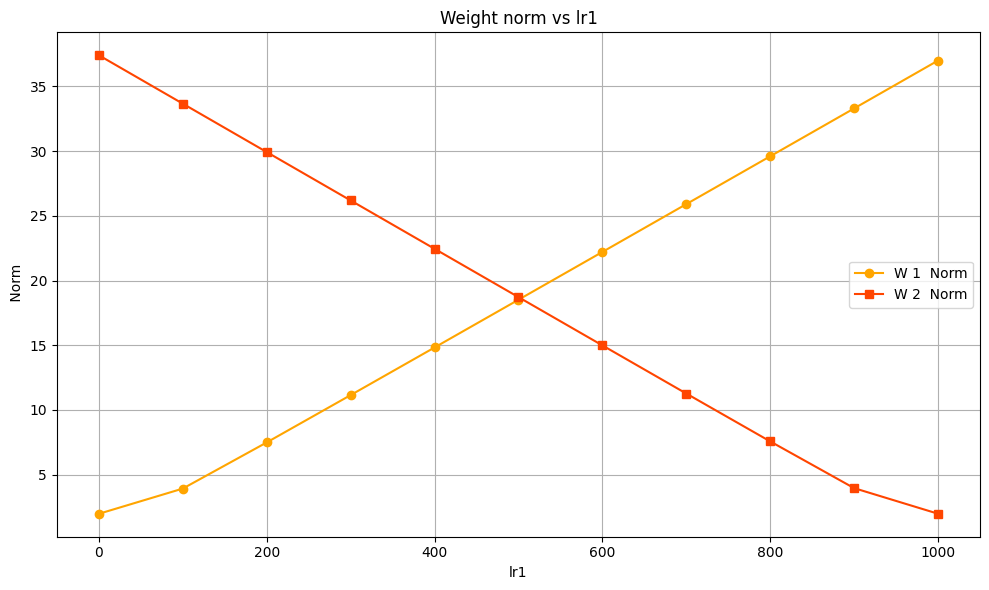

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(2025)
d = 1500
h = 1500
n = 2000  
rho =0.2
#lr1=0
#lr2=0
W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(1, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi


W_1_norm=[]
W_2_norm=[]
for (lr1,lr2) in [(0,1000),(100,900),(200,800),(300,700),(400,600),(500,500),(600,400),(700,300),(800,200),(900,100),(1000,0)]:

    W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T


    #feature_1 = X@W1_true
    #feature_2 = X@W1_true@W2_true


    W_1_op = torch.linalg.norm( W1_true, ord=2)
    W_2_op = torch.linalg.norm( W2_true, ord=2)

    W_1_norm.append(W_1_op)
    W_2_norm.append(W_2_op)



    print(f'lr1:{lr1}, lr2:{lr2}, feature_1_operator_norm:{W_1_op}')
    print(f'lr1:{lr1}, lr2:{lr2}, feature_2_operator_norm:{W_2_op}')



lr1_values = list(range(0, 1100, 100))

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(lr1_values[:len(W_1_norm)], W_1_norm, marker='o', color='orange', label='W 1  Norm')
plt.plot(lr1_values[:len(W_2_norm)], W_2_norm, marker='s', color='orangered', label='W 2  Norm')

plt.xlabel('lr1')
plt.ylabel(' Norm')
plt.title('Weight norm vs lr1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

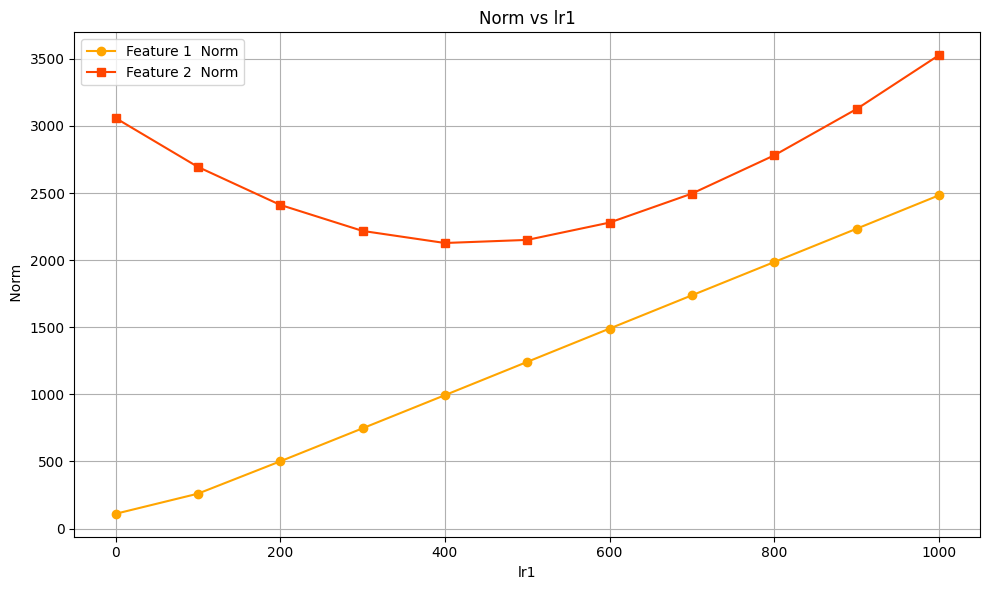

In [4]:
import matplotlib.pyplot as plt

# Provided operator norm values
feature_1_op = [110, 260, 501, 747, 994, 1242, 1490, 1738, 1986, 2234, 2483]
feature_2_op = [3059, 2695, 2412, 2218,2128, 2151, 2280, 2496, 2781, 3126, 3527]

# Corresponding lr1 values (assumed to increase by 100)
lr1_values = list(range(0, 1100, 100))

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(lr1_values[:len(feature_1_op)], feature_1_op, marker='o', color='orange', label='Feature 1  Norm')
plt.plot(lr1_values[:len(feature_2_op)], feature_2_op, marker='s', color='orangered', label='Feature 2  Norm')

plt.xlabel('lr1')
plt.ylabel(' Norm')
plt.title('Norm vs lr1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

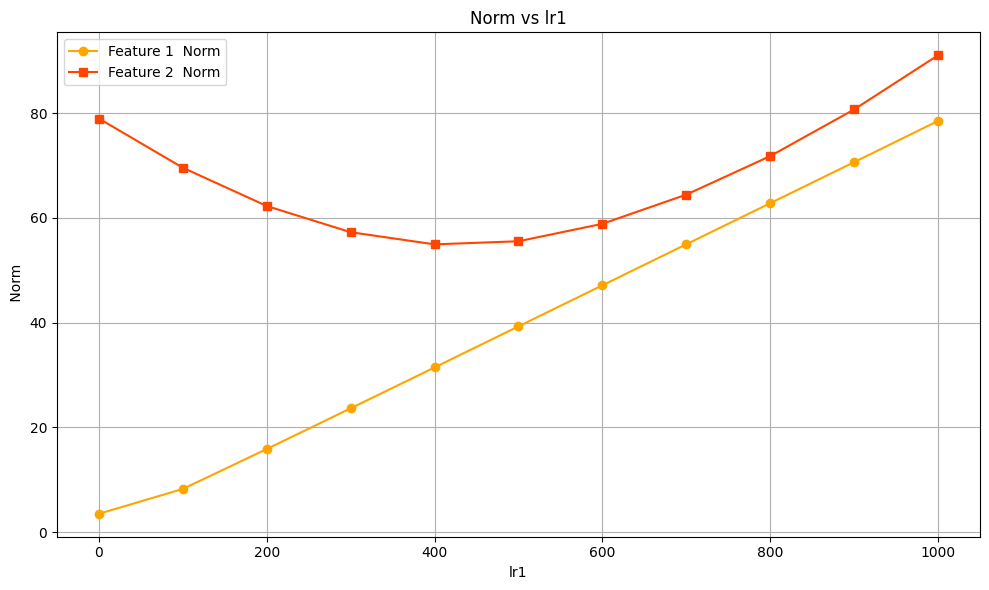

In [1]:
import matplotlib.pyplot as plt
import numpy as np

h=1500
d=1000
n=2000
# Provided operator norm values
feature_1_op = [110, 260, 501, 747, 994, 1242, 1490, 1738, 1986, 2234, 2483]
feature_2_op = [3059, 2695, 2412, 2218,2128, 2151, 2280, 2496, 2781, 3126, 3527]

for i in range(len(feature_1_op)):
    feature_1_op[i]=feature_1_op[i]/np.sqrt(d)

for i in range(len(feature_2_op)):
    feature_2_op[i]=feature_2_op[i]/np.sqrt(h)
# Corresponding lr1 values (assumed to increase by 100)
lr1_values = list(range(0, 1100, 100))

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(lr1_values[:len(feature_1_op)], feature_1_op, marker='o', color='orange', label='Feature 1  Norm')
plt.plot(lr1_values[:len(feature_2_op)], feature_2_op, marker='s', color='orangered', label='Feature 2  Norm')

plt.xlabel('lr1')
plt.ylabel(' Norm')
plt.title('Norm vs lr1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss)
import torch
import numpy as np
torch.manual_seed(2025)
d = 1500
h = 1500
n = 2000  
rho =0.2
lr1=500
lr2=500
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(1, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi



def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
    L={}
    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
    L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
    L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
    L4=torch.trace(x.T@x@beta@beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_=L1-L2-L3+L4

    return L, L_


loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
print(loss_)


for t, value in loss.items():
    print(f"L{t}: {value.item()}")
   

    print('#############################')

W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
Loss_true_exact=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)
print(f'True_loss_1:{Loss_true_1}')
print(f'True_loss_2:{Loss_true_2}')
print(f'True_loss_exact:{Loss_true_exact}')

tensor(1.1604)
L1: 1.6570690870285034
#############################
L2: 3.043740749359131
#############################
L3: 3.043741226196289
#############################
L4: 5.590811252593994
#############################
True_loss_1:tensor([[1.1604]])
True_loss_2:tensor([[5.6781]])
True_loss_exact:tensor([[1.5426]])


In [21]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss)

## To test theoretical theory of eta_1=2eta_2  when n=d=h, rho=0

# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 2000
    h = 2000
    n = 2000  
    rho =0
    lr1=800
    lr2=400
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/test_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/test_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    Loss_true=Loss_true+1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{Loss_appro/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')


Loss_decompose:0.6337358459472656
L1: 0.8125410079956055
L2: 0.5902715206146241
L3: 0.5902715206146241
L4: 1.0017378807067872
Loss_appro:tensor([[0.6337]])
Loss_true:tensor([[0.6148]])


In [66]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
import torch
import numpy as np
torch.manual_seed(2025)
d = 1500
h = 1500
n = 2000  
rho =0.2
lr1=10
lr2=10
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

test_size=500
W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(test_size, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi



def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
    L={}
    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
    L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
    L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
    L4=torch.trace(x.T@x@beta@beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_=L1-L2-L3+L4

    return L, L_


loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
print(loss_/test_size)


for t, value in loss.items():
    print(f"L{t}: {value.item()}")
   

    print('#############################')

W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
Loss_true_1=1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
Loss_true_exact=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)
print(f'True_loss_1:{Loss_true_1}')
print(f'True_loss_2:{Loss_true_2}')
print(f'True_loss_exact:{Loss_true_exact}')

tensor(0.9823)
L1: 0.5176854133605957
#############################
L2: 6.6783881187438965
#############################
L3: 6.678386688232422
#############################
L4: 504.00482177734375
#############################
True_loss_1:tensor([[0.9823]])
True_loss_2:tensor([[1.0088]])
True_loss_exact:tensor([[0.9824]])


In [7]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1500
    h = 1500
    n = 2000  
    rho =0.2
    lr1=1000
    lr2=1000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/test_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/test_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    Loss_true=Loss_true+1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{Loss_appro/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_decompose:3.000148974609375
L1: 4.684309768676758
L2: 1.344648551940918
L3: 1.3446484565734864
L4: 1.0051362991333008
Loss_appro:tensor([[3.0001]])
Loss_true:tensor([[1.9789]])


In [5]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 10000
    h = 10000
    n = 10000  
    rho =0
    lr1=1
    lr2=1
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    a= torch.eye(h)
    #beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    beta =  torch.normal(mean=0, std=1, size=(d, h))
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/test_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/test_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    loss_appro=torch.norm(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta, 'fro')
    Loss_appro=Loss_appro+1/test_size*(loss_appro*loss_appro-torch.trace(x.T@x@beta@beta.T))
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    loss_true=torch.norm(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta, 'fro')
    Loss_true=Loss_true+1/test_size* (loss_true* loss_true-torch.trace(x.T@x@beta@beta.T))


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{Loss_appro/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_decompose:99968559.104
L1: 16.994233703613283
L2: 19994.8109375
L3: 19994.8109375
L4: 100008531.2
Loss_appro:-65673.21875
Loss_true:-65671.578125


In [9]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000  
    rho =0
    lr1=33
    lr2=33
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=1000
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    a= torch.eye(h)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    #beta =  torch.normal(mean=0, std=1, size=(d, h))
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/test_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/test_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    loss_appro=torch.norm(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta, 'fro')
    Loss_appro=Loss_appro+1/test_size*(loss_appro*loss_appro)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    loss_true=torch.norm(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta, 'fro')
    Loss_true=Loss_true+1/test_size* (loss_true* loss_true)


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{Loss_appro/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_decompose:886.8412031250002
L1: 18.856912231445314
L2: 66.12269897460938
L3: 66.12269897460938
L4: 1000.22958984375
Loss_appro:886.8221435546875
Loss_true:891.8837890625


In [7]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
traning_Loss_appro=0
traning_Loss_true=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000  
    rho =0
    lr1=33
    lr2=33
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    training_size=n
    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    a= torch.eye(h)
    #beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*X.T@X@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*X.T@X@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* X.T@X@W1_update@W2_update@a@beta.T)
        L4=torch.trace(X.T@X@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/training_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/training_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    traning_loss_appro=torch.norm(1/np.sqrt(h)*X@W1_update@W2_update@a-X@beta, 'fro')
    traning_Loss_appro=traning_Loss_appro+1/training_size*(traning_loss_appro*traning_loss_appro)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    traning_loss_true=torch.norm(1/np.sqrt(h)*X@W1_true@W2_true@a-X@beta, 'fro')
    traning_Loss_true=traning_Loss_true+1/training_size * (traning_loss_true* traning_loss_true)


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{traning_Loss_appro/len(seeds)}')
print(f'Loss_true:{traning_Loss_true/len(seeds)}')

Loss_decompose:778.2312562499999
L1: 42.368716430664065
L2: 132.2112060546875
L3: 132.2112060546875
L4: 1000.2849609375
Loss_appro:778.2134399414062
Loss_true:789.837890625


In [3]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
traning_Loss_appro=0
traning_Loss_true=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000  
    rho =0
    lr1=500
    lr2=0
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    training_size=n
    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    a= torch.eye(h)
    #beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*X.T@X@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*X.T@X@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* X.T@X@W1_update@W2_update@a@beta.T)
        L4=torch.trace(X.T@X@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/training_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/training_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    traning_loss_appro=torch.norm(1/np.sqrt(h)*X@W1_update@W2_update@a-X@beta, 'fro')
    traning_Loss_appro=traning_Loss_appro+1/training_size*(traning_loss_appro*traning_loss_appro)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    traning_loss_true=torch.norm(1/np.sqrt(h)*X@W1_true@W2_true@a-X@beta, 'fro')
    traning_Loss_true=traning_Loss_true+1/training_size * (traning_loss_true* traning_loss_true)


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{traning_Loss_appro/len(seeds)}')
print(f'Loss_true:{traning_Loss_true/len(seeds)}')

Loss_decompose:1506.9253125
L1: 2508.762890625
L2: 1001.061328125
L3: 1001.061328125
L4: 1000.2849609375
Loss_appro:1506.889892578125
Loss_true:1509.337158203125


In [1]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
import torch
import numpy as np
seeds=range(2005,2025)
L_dict_appro={}
for i in range(4):
    L_dict_appro[i+1]=0

L_dict_appro_1={}
for i in range(4):
    L_dict_appro_1[i+1]=0

L_dict_appro_2={}
for i in range(4):
    L_dict_appro_2[i+1]=0

L_dict_appro_3={}
for i in range(4):
    L_dict_appro_3[i+1]=0

L_dict_appro_4={}
for i in range(4):
    L_dict_appro_4[i+1]=0

L_dict_appro_5={}
for i in range(4):
    L_dict_appro_5[i+1]=0


L_dict_appro_6={}
for i in range(4):
    L_dict_appro_6[i+1]=0

def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}

        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*B1@W2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr2*W1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        #W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*B1@A2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2+lr1*lr2*B1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


Loss_true=0
Loss_appro=0
Loss_appro_1=0
Loss_appro_2=0
Loss_appro_3=0
Loss_appro_4=0
Loss_appro_5=0
Loss_appro_6=0

#Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1500
    h = 1500
    n = 2000  
    rho =0.2
    lr1=1000
    lr2=1000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y=X@beta+xi



    

    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
    loss_1, loss__1 = compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x)
    loss_2, loss__2 = compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x)
    loss_3, loss__3 = compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x)
    loss_4, loss__4 = compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x)
    loss_5, loss__5 = compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x)
    loss_6, loss__6 = compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x)


    for i in range(4):
        L_dict_appro[i+1]=L_dict_appro[i+1]+ loss[i+1]/test_size
        L_dict_appro_1[i+1]=L_dict_appro_1[i+1]+ loss_1[i+1]/test_size
        L_dict_appro_2[i+1]=L_dict_appro_2[i+1]+ loss_2[i+1]/test_size
        L_dict_appro_3[i+1]=L_dict_appro_3[i+1]+ loss_3[i+1]/test_size
        L_dict_appro_4[i+1]=L_dict_appro_4[i+1]+ loss_4[i+1]/test_size
        L_dict_appro_5[i+1]=L_dict_appro_5[i+1]+ loss_5[i+1]/test_size
        L_dict_appro_6[i+1]=L_dict_appro_6[i+1]+ loss_6[i+1]/test_size
        
    #print(loss_/test_size)
    Loss_appro= Loss_appro+loss_.item()/test_size
    Loss_appro_1= Loss_appro_1+loss__1.item()/test_size
    Loss_appro_2= Loss_appro_2+loss__2.item()/test_size
    Loss_appro_3= Loss_appro_3+loss__3.item()/test_size
    Loss_appro_4= Loss_appro_4+loss__4.item()/test_size
    Loss_appro_5= Loss_appro_5+loss__5.item()/test_size
    Loss_appro_6= Loss_appro_5+loss__6.item()/test_size



    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    #Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    Loss_true=Loss_true+1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)


print(f'Loss_appro:{Loss_appro/len(seeds)}')
for t, value in L_dict_appro.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_1:{Loss_appro_1/len(seeds)}')
print(f'Loss_appro_2:{Loss_appro_2/len(seeds)}')
print(f'Loss_appro_3:{Loss_appro_3/len(seeds)}')
for t, value in L_dict_appro_3.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_4:{Loss_appro_4/len(seeds)}')
for t, value in L_dict_appro_4.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_5:{Loss_appro_5/len(seeds)}')
print(f'Loss_appro_6:{Loss_appro_6/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_appro:3.000148974609375
L1: 4.684309768676758
L2: 1.344648551940918
L3: 1.3446484565734864
L4: 1.0051362991333008
Loss_appro_1:2.997575140380859
Loss_appro_2:2.9943719970703127
Loss_appro_3:1.984178393554687
L1: 2.7509576797485353
L2: 0.885957908630371
L3: 0.885957908630371
L4: 1.0051362991333008
Loss_appro_4:2.9988196472167967
L1: 4.681968688964844
L2: 1.3441427230834961
L3: 1.344142532348633
L4: 1.0051362991333008
Loss_appro_5:3.002501776123047
Loss_appro_6:3.1500916442871096
Loss_true:tensor([[1.9789]])


In [1]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
# set a=identity
import torch
import numpy as np
seeds=range(2005,2025)
L_dict_appro={}
for i in range(4):
    L_dict_appro[i+1]=0

L_dict_appro_1={}
for i in range(4):
    L_dict_appro_1[i+1]=0

L_dict_appro_2={}
for i in range(4):
    L_dict_appro_2[i+1]=0

L_dict_appro_3={}
for i in range(4):
    L_dict_appro_3[i+1]=0

L_dict_appro_4={}
for i in range(4):
    L_dict_appro_4[i+1]=0

L_dict_appro_5={}
for i in range(4):
    L_dict_appro_5[i+1]=0


L_dict_appro_6={}
for i in range(4):
    L_dict_appro_6[i+1]=0

def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}

        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*B1@W2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr2*W1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        #W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*B1@A2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2+lr1*lr2*B1@B2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h))*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h))*W1.T@X.T@y@a.T
        B1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2
        
        L1=torch.trace(1/h*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


Loss_true=0
Loss_appro=0
Loss_appro_1=0
Loss_appro_2=0
Loss_appro_3=0
Loss_appro_4=0
Loss_appro_5=0
Loss_appro_6=0

#Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000  
    rho =0
    lr1=40
    lr2=40
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi
    x=torch.normal(mean=0, std=1, size=(test_size, d))



    

    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
    loss_1, loss__1 = compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x)
    loss_2, loss__2 = compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x)
    loss_3, loss__3 = compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x)
    loss_4, loss__4 = compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x)
    loss_5, loss__5 = compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x)
    loss_6, loss__6 = compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x)


    for i in range(4):
        L_dict_appro[i+1]=L_dict_appro[i+1]+ loss[i+1]/test_size
        L_dict_appro_1[i+1]=L_dict_appro_1[i+1]+ loss_1[i+1]/test_size
        L_dict_appro_2[i+1]=L_dict_appro_2[i+1]+ loss_2[i+1]/test_size
        L_dict_appro_3[i+1]=L_dict_appro_3[i+1]+ loss_3[i+1]/test_size
        L_dict_appro_4[i+1]=L_dict_appro_4[i+1]+ loss_4[i+1]/test_size
        L_dict_appro_5[i+1]=L_dict_appro_5[i+1]+ loss_5[i+1]/test_size
        L_dict_appro_6[i+1]=L_dict_appro_6[i+1]+ loss_6[i+1]/test_size
        
    #print(loss_/test_size)
    Loss_appro= Loss_appro+loss_.item()/test_size
    Loss_appro_1= Loss_appro_1+loss__1.item()/test_size
    Loss_appro_2= Loss_appro_2+loss__2.item()/test_size
    Loss_appro_3= Loss_appro_3+loss__3.item()/test_size
    Loss_appro_4= Loss_appro_4+loss__4.item()/test_size
    Loss_appro_5= Loss_appro_5+loss__5.item()/test_size
    Loss_appro_6= Loss_appro_5+loss__6.item()/test_size



    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    #Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    loss=torch.norm(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta, 'fro')
    Loss_true=Loss_true+1/test_size*loss*loss
    


print(f'Loss_appro:{Loss_appro/len(seeds)}')
for t, value in L_dict_appro.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_1:{Loss_appro_1/len(seeds)}')
print(f'Loss_appro_2:{Loss_appro_2/len(seeds)}')
print(f'Loss_appro_3:{Loss_appro_3/len(seeds)}')
for t, value in L_dict_appro_3.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_4:{Loss_appro_4/len(seeds)}')
for t, value in L_dict_appro_4.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_5:{Loss_appro_5/len(seeds)}')
print(f'Loss_appro_6:{Loss_appro_6/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_appro:870.5797968749999
L1: 30.529263305664063
L2: 80.1884033203125
L3: 80.1884033203125
L4: 1000.42734375
Loss_appro_1:870.4360624999999
Loss_appro_2:870.431071875
Loss_appro_3:873.0352156250003
L1: 29.77994384765625
L2: 78.58604125976562
L3: 78.58604125976562
L4: 1000.42734375
Loss_appro_4:875.5084343749999
L1: 29.046923828125
L2: 76.98291015625
L3: 76.98291015625
L4: 1000.42734375
Loss_appro_5:870.5928875000002
Loss_appro_6:913.6639937500001
Loss_true:877.7179565429688


In [8]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
# set a=identity
import torch
import numpy as np
seeds=range(2005,2025)
L_dict_appro={}
for i in range(4):
    L_dict_appro[i+1]=0

L_dict_appro_1={}
for i in range(4):
    L_dict_appro_1[i+1]=0

L_dict_appro_2={}
for i in range(4):
    L_dict_appro_2[i+1]=0

L_dict_appro_3={}
for i in range(4):
    L_dict_appro_3[i+1]=0

L_dict_appro_4={}
for i in range(4):
    L_dict_appro_4[i+1]=0

L_dict_appro_5={}
for i in range(4):
    L_dict_appro_5[i+1]=0


L_dict_appro_6={}
for i in range(4):
    L_dict_appro_6[i+1]=0

def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}

        W1_update=W1+(lr1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
        L1=torch.trace(1/(h*h)*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*B1@W2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr2*W1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        #W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*B1@A2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2+lr1*lr2*B1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


Loss_true=0
Loss_appro=0
Loss_appro_1=0
Loss_appro_2=0
Loss_appro_3=0
Loss_appro_4=0
Loss_appro_5=0
Loss_appro_6=0

#Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000 
    rho =0
    lr1=1000*h
    lr2=1000*h
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi
    x=torch.normal(mean=0, std=1, size=(test_size, d))



    

    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
    loss_1, loss__1 = compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x)
    loss_2, loss__2 = compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x)
    loss_3, loss__3 = compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x)
    loss_4, loss__4 = compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x)
    loss_5, loss__5 = compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x)
    loss_6, loss__6 = compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x)


    for i in range(4):
        L_dict_appro[i+1]=L_dict_appro[i+1]+ loss[i+1]/test_size
        L_dict_appro_1[i+1]=L_dict_appro_1[i+1]+ loss_1[i+1]/test_size
        L_dict_appro_2[i+1]=L_dict_appro_2[i+1]+ loss_2[i+1]/test_size
        L_dict_appro_3[i+1]=L_dict_appro_3[i+1]+ loss_3[i+1]/test_size
        L_dict_appro_4[i+1]=L_dict_appro_4[i+1]+ loss_4[i+1]/test_size
        L_dict_appro_5[i+1]=L_dict_appro_5[i+1]+ loss_5[i+1]/test_size
        L_dict_appro_6[i+1]=L_dict_appro_6[i+1]+ loss_6[i+1]/test_size
        
    #print(loss_/test_size)
    Loss_appro= Loss_appro+loss_.item()/test_size
    Loss_appro_1= Loss_appro_1+loss__1.item()/test_size
    Loss_appro_2= Loss_appro_2+loss__2.item()/test_size
    Loss_appro_3= Loss_appro_3+loss__3.item()/test_size
    Loss_appro_4= Loss_appro_4+loss__4.item()/test_size
    Loss_appro_5= Loss_appro_5+loss__5.item()/test_size
    Loss_appro_6= Loss_appro_5+loss__6.item()/test_size



    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    #Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    loss=torch.norm(1/h*x@W1_true@W2_true@a-1/np.sqrt(h)*x@beta, 'fro')
    Loss_true=Loss_true+1/test_size*loss*loss
    


print(f'Loss_appro:{Loss_appro/len(seeds)}')
for t, value in L_dict_appro.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_1:{Loss_appro_1/len(seeds)}')
print(f'Loss_appro_2:{Loss_appro_2/len(seeds)}')
print(f'Loss_appro_3:{Loss_appro_3/len(seeds)}')
for t, value in L_dict_appro_3.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_4:{Loss_appro_4/len(seeds)}')
for t, value in L_dict_appro_4.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_5:{Loss_appro_5/len(seeds)}')
print(f'Loss_appro_6:{Loss_appro_6/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_appro:4016.868812500001
L1: 4019.990625
L2: 2.061177062988281
L3: 2.061177062988281
L4: 1.0004273414611817
Loss_appro_1:4016.8541625
Loss_appro_2:4016.852925
Loss_appro_3:4014.5619250000004
L1: 4015.68046875
L2: 1.059695339202881
L3: 1.0596952438354492
L4: 1.0004273414611817
Loss_appro_4:4018.5144375000004
L1: 4017.62890625
L2: 0.057745063304901124
L3: 0.05774503946304321
L4: 1.0004273414611817
Loss_appro_5:4016.9913125000007
Loss_appro_6:4017.4431749511728
Loss_true:4026.22216796875


In [12]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
# set a=identity
import torch
import numpy as np
seeds=range(2005,2025)
L_dict_appro={}
for i in range(4):
    L_dict_appro[i+1]=0

L_dict_appro_1={}
for i in range(4):
    L_dict_appro_1[i+1]=0

L_dict_appro_2={}
for i in range(4):
    L_dict_appro_2[i+1]=0

L_dict_appro_3={}
for i in range(4):
    L_dict_appro_3[i+1]=0

L_dict_appro_4={}
for i in range(4):
    L_dict_appro_4[i+1]=0

L_dict_appro_5={}
for i in range(4):
    L_dict_appro_5[i+1]=0


L_dict_appro_6={}
for i in range(4):
    L_dict_appro_6[i+1]=0

def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}

        W1_update=W1+(lr1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
        L1=torch.trace(1/(h*h)*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*B1@W2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr2*W1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        #W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*A1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2-lr1*lr2*B1@A2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2+lr1*lr2*A1@A2+lr1*lr2*B1@B2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_

def compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        A1=1/(n*np.sqrt(h)*h)*X.T@y@a.T@W2.T
        A2=1/(n*np.sqrt(h)*h)*W1.T@X.T@y@a.T
        B1=(1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T
        B2=(1/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T

        W1W2_update=W1@W2+lr1*A1@W2+lr2*W1@A2
        
        L1=torch.trace(1/(h*h)*x.T@x@ W1W2_update@a@a.T@  W1W2_update.T)
        L2=torch.trace(1/(np.sqrt(h)*h)*x.T@x@ beta@a.T@  W1W2_update.T)
        L3=torch.trace(1/(np.sqrt(h)*h)* x.T@x@ W1W2_update@a@beta.T)
        L4=torch.trace(1/h*x.T@x@beta@beta.T)


        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


Loss_true=0
Loss_appro=0
Loss_appro_1=0
Loss_appro_2=0
Loss_appro_3=0
Loss_appro_4=0
Loss_appro_5=0
Loss_appro_6=0

#Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1000
    h = 1000
    n = 1000  
    rho =0
    lr1=1000**(3/2)
    lr2=1000**(3/2)
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    #beta = torch.randn(size=[d])
    #beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    beta =  torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    y=X@beta+xi
    x=torch.normal(mean=0, std=1, size=(test_size, d))



    

    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
    loss_1, loss__1 = compute_loss_1(W1,W2,X,lr1,lr2,y,beta,x)
    loss_2, loss__2 = compute_loss_2(W1,W2,X,lr1,lr2,y,beta,x)
    loss_3, loss__3 = compute_loss_3(W1,W2,X,lr1,lr2,y,beta,x)
    loss_4, loss__4 = compute_loss_4(W1,W2,X,lr1,lr2,y,beta,x)
    loss_5, loss__5 = compute_loss_5(W1,W2,X,lr1,lr2,y,beta,x)
    loss_6, loss__6 = compute_loss_6(W1,W2,X,lr1,lr2,y,beta,x)


    for i in range(4):
        L_dict_appro[i+1]=L_dict_appro[i+1]+ loss[i+1]/test_size
        L_dict_appro_1[i+1]=L_dict_appro_1[i+1]+ loss_1[i+1]/test_size
        L_dict_appro_2[i+1]=L_dict_appro_2[i+1]+ loss_2[i+1]/test_size
        L_dict_appro_3[i+1]=L_dict_appro_3[i+1]+ loss_3[i+1]/test_size
        L_dict_appro_4[i+1]=L_dict_appro_4[i+1]+ loss_4[i+1]/test_size
        L_dict_appro_5[i+1]=L_dict_appro_5[i+1]+ loss_5[i+1]/test_size
        L_dict_appro_6[i+1]=L_dict_appro_6[i+1]+ loss_6[i+1]/test_size
        
    #print(loss_/test_size)
    Loss_appro= Loss_appro+loss_.item()/test_size
    Loss_appro_1= Loss_appro_1+loss__1.item()/test_size
    Loss_appro_2= Loss_appro_2+loss__2.item()/test_size
    Loss_appro_3= Loss_appro_3+loss__3.item()/test_size
    Loss_appro_4= Loss_appro_4+loss__4.item()/test_size
    Loss_appro_5= Loss_appro_5+loss__5.item()/test_size
    Loss_appro_6= Loss_appro_5+loss__6.item()/test_size



    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)*h))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)*h))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
    #Loss_appro=Loss_appro+1/test_size*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    loss=torch.norm(1/h*x@W1_true@W2_true@a-1/np.sqrt(h)*x@beta, 'fro')
    Loss_true=Loss_true+1/test_size*loss*loss
    


print(f'Loss_appro:{Loss_appro/len(seeds)}')
for t, value in L_dict_appro.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_1:{Loss_appro_1/len(seeds)}')
print(f'Loss_appro_2:{Loss_appro_2/len(seeds)}')
print(f'Loss_appro_3:{Loss_appro_3/len(seeds)}')
for t, value in L_dict_appro_3.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_4:{Loss_appro_4/len(seeds)}')
for t, value in L_dict_appro_4.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro_5:{Loss_appro_5/len(seeds)}')
print(f'Loss_appro_6:{Loss_appro_6/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_appro:0.8907123626708984
L1: 0.01704608350992203
L2: 0.06338055729866028
L3: 0.06338055729866028
L4: 1.0004273414611817
Loss_appro_1:0.8905966094970704
Loss_appro_2:0.8905932922363281
Loss_appro_3:0.8923430419921876
L1: 0.016673801839351653
L2: 0.062379086017608644
L3: 0.062379086017608644
L4: 1.0004273414611817
Loss_appro_4:0.8939810943603514
L1: 0.01630794405937195
L2: 0.06137712597846985
L3: 0.06137712597846985
L4: 1.0004273414611817
Loss_appro_5:0.890720477294922
Loss_appro_6:0.9351157135009766
Loss_true:0.8953978419303894


In [2]:
## verify the norm of A_1, A_2, B_1, B_2
import torch
import numpy as np
torch.manual_seed(2025)
d = 1500 
h = 1500  
n = 2000 
rho =0.2
lr1=1000
lr2=1000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
#xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, d))
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
a= torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
beta =torch.normal(mean=0, std=1/np.sqrt(d), size=(d, d))
beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
y=X@beta+xi

A_1=(1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
A_2=(1/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
A=(1/(n*np.sqrt(h)))*X.T@y@a.T
A_F=torch.norm(A, 'fro')
A_1_F = torch.norm(A_1, 'fro')
A_2_F = torch.norm(A_2, 'fro')
W2_F= torch.norm(W2, 'fro')
#print((np.sqrt(h)*A_F))
#print(np.sqrt(h)*A_1_F)
#print(A_F)
print(f'A_1_Frobenuis:{A_1_F}')
print(f'A_2_Frobenuis:{A_2_F}')

#print(W2_F)
B_1=(1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T
B_1_F = torch.norm(B_1, 'fro')
B_2=(1/(n*h))*W1.T@X.T@X@W1@W2@a@a.T
B_2_F = torch.norm(B_2, 'fro')

#print(np.sqrt(h)*B_1_F)
print(f'B_1_Frobenuis:{B_1_F}')
print(f'B_2_Frobenuis:{B_2_F}')


A1B2=A_1@B_2
A1B2_F = torch.norm(A1B2, 'fro')
#A1B2_F = torch.norm(A1B2)
B1A2=B_1@A_2
B1A2_F = torch.norm(B1A2, 'fro')
#B1A2_F = torch.norm(B1A2)
print(f'A1B2_Frobenuis:{A1B2_F}')
print(f'B1A2_Frobenuis:{B1A2_F}')

#A1W2=A_1@W2
#A1W2_F = torch.norm(A1W2, 'fro')
#W1A2=W1@A_2
#W1A2_F = torch.norm(W1A2, 'fro')
#print(f'A1W2_Frobenuis:{A1W2_F}')
#print(f'W1A2_Frobenuis:{W1A2_F}')
print("#################################################")

lr1A1W2=lr1*A_1@W2
lr1A1W2_F = torch.norm(lr1A1W2, 'fro')
lr2W1A2=lr2*W1@A_2
lr2W1A2_F = torch.norm(lr2W1A2, 'fro')
lr1lr2A1A2=lr1*lr2*A_1@A_2
lr1lr2A1A2_F = torch.norm(lr1lr2A1A2, 'fro')
lr1lr2A1B2=lr1*lr2*A_1@B_2
lr1lr2A1B2_F = torch.norm(lr1lr2A1B2, 'fro')
lr1lr2B1A2=lr1*lr2*B_1@A_2
lr1lr2B1A2_F = torch.norm(lr1lr2B1A2, 'fro')
lr1B1W2=lr1*B_1@W2
lr1B1W2_F = torch.norm(lr1B1W2, 'fro')
lr2W1B2=lr2*W1@B_2
lr2W1B2_F = torch.norm(lr2W1B2, 'fro')
lr1lr2B1B2=lr1*lr2*B_1@B_2
lr1lr2B1B2_F = torch.norm(lr1lr2B1B2, 'fro')
print(f'lr1A1W2_Frobenuis:{lr1A1W2_F}')
print(f'lr2W1A2_Frobenuis:{lr2W1A2_F}')

print(f'lr1lr2A1A2_Frobenuis:{lr1lr2A1A2_F}')
print(f'lr1lr2A1B2_Frobenuis:{lr1lr2A1B2_F}')

print(f'lr1lr2B1A2_Frobenuis:{lr1lr2B1A2_F}')
print(f'lr1B1W2_Frobenuis:{lr1B1W2_F}')
print(f'lr2W1B2_Frobenuis:{lr2W1B2_F}')
print(f'lr1lr2B1B2_Frobenuis:{lr1lr2B1B2_F}')






A_1_Frobenuis:0.3884906470775604
A_2_Frobenuis:0.3885095417499542
B_1_Frobenuis:0.05921565741300583
B_2_Frobenuis:0.060489632189273834
A1B2_Frobenuis:0.000843268062453717
B1A2_Frobenuis:0.0007817497826181352
#################################################
lr1A1W2_Frobenuis:549.38525390625
lr2W1A2_Frobenuis:549.294921875
lr1lr2A1A2_Frobenuis:3911.203369140625
lr1lr2A1B2_Frobenuis:843.2664794921875
lr1lr2B1A2_Frobenuis:781.7527465820312
lr1B1W2_Frobenuis:90.42745971679688
lr2W1B2_Frobenuis:92.89076232910156
lr1lr2B1B2_Frobenuis:205.51541137695312


In [5]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss)   in TWO-LAYER setting

import torch
import numpy as np
torch.manual_seed(2025)
d = 10000
h = 10000
n = 10000 
rho =0
lr1=100000
lr2=100000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]


W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(1, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi



def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
    L={}
    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
    L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
    L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
    L4=torch.trace(x.T@x@beta@beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_=L1-L2-L3+L4

    return L, L_


#loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
#print(loss_)


#for t, value in loss.items():
#    print(f"L{t}: {value.item()}")
   

#    print('#############################')

W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T
#W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_true=W1-lr1/(n*h)*X.T@X@W1@a@a.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T
#W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
#W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
#W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
Loss_true_1=(1/np.sqrt(h)*x@W1_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@a-x@beta)
#Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
Loss_true_exact=(1/np.sqrt(h)*x@W1_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@a-x@beta)
print(f'True_loss_1:{Loss_true_1}')
#print(f'True_loss_2:{Loss_true_2}')
print(f'True_loss_exact:{Loss_true_exact}')

True_loss_1:tensor([[49.8148]])
True_loss_exact:tensor([[51.8254]])


In [28]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss)   in TWO-LAYER setting
# with a larger number of test data 
import torch
import numpy as np
torch.manual_seed(2025)
d = 1000
h = 1500
n = 2000 
rho =0.2
lr1=2000000000
lr2=2000000000
lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

test_size=500

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
#beta = torch.normal(mean=0, std=1/d, size=(d, 1))
x=torch.normal(mean=0, std=1, size=(test_size, d))

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y=X@beta+xi



def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
    L={}
    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
    L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
    L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
    L4=torch.trace(x.T@x@beta@beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_=L1-L2-L3+L4

    return L, L_


#loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)
#print(loss_)


#for t, value in loss.items():
#    print(f"L{t}: {value.item()}")
   

#    print('#############################')

W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T
#W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
W1_true=W1-lr1/(n*h)*X.T@X@W1@a@a.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T
#W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
#W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
#W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
Loss_true_1=1/test_size*(1/np.sqrt(h)*x@W1_update@a-x@beta).T@(1/np.sqrt(h)*x@W1_update@a-x@beta)
#Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
Loss_true_exact=1/test_size*(1/np.sqrt(h)*x@W1_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@a-x@beta)
print(f'True_loss_1:{Loss_true_1}')
#print(f'True_loss_2:{Loss_true_2}')
print(f'True_loss_exact:{Loss_true_exact}')

True_loss_1:tensor([[2.5979e+12]])
True_loss_exact:tensor([[2.5832e+12]])


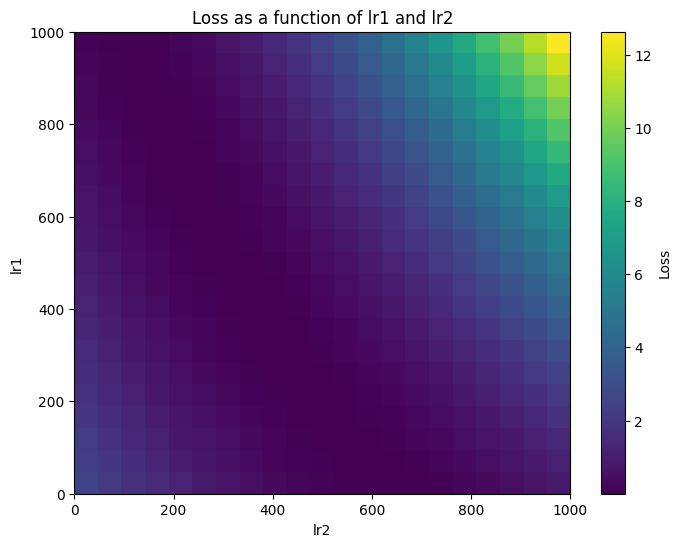

In [82]:
# seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


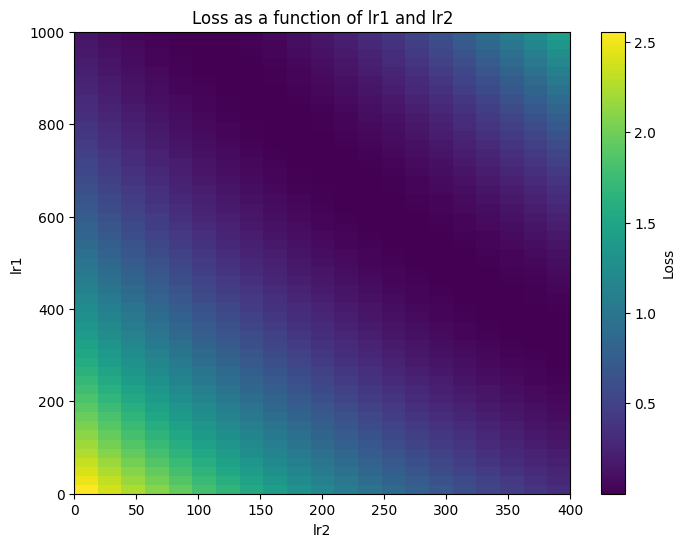

In [86]:
# seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 20)  # 从0到2000，间隔50
lr2_range = np.arange(0, 401, 20)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


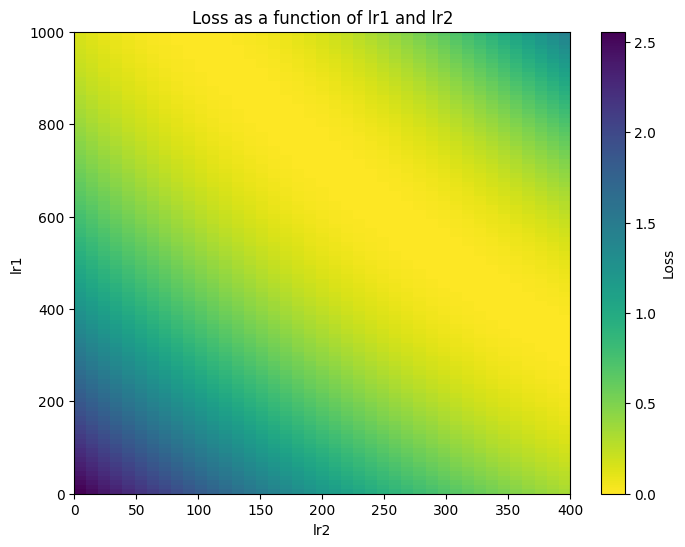

In [87]:
# seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 401, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis_r', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


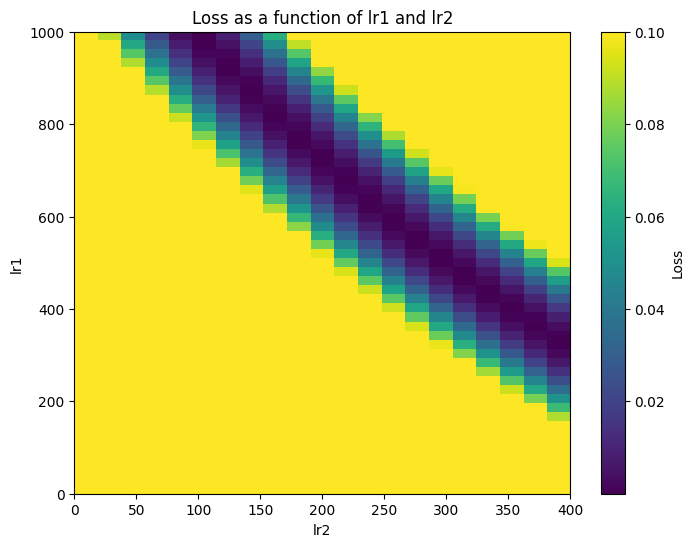

In [88]:
# seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 20)  # 从0到2000，间隔50
lr2_range = np.arange(0, 401, 20)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.1:
            loss_grid[i, j] =0.1


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


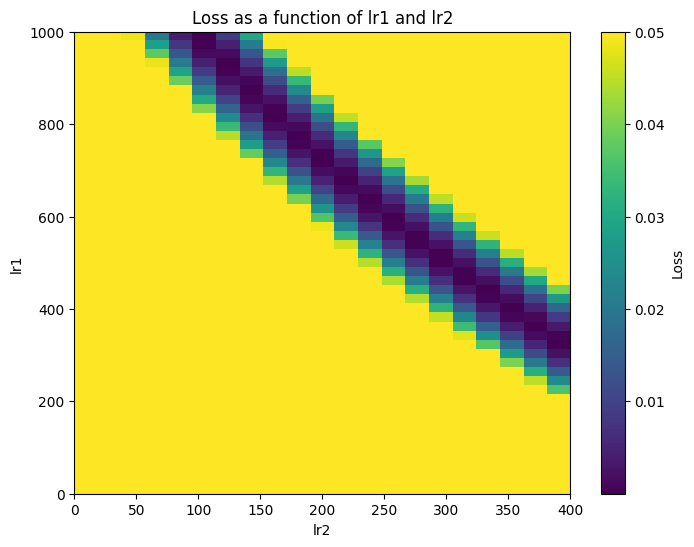

In [89]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 20)  # 从0到2000，间隔50
lr2_range = np.arange(0, 401, 20)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.05:
            loss_grid[i, j] =0.05


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


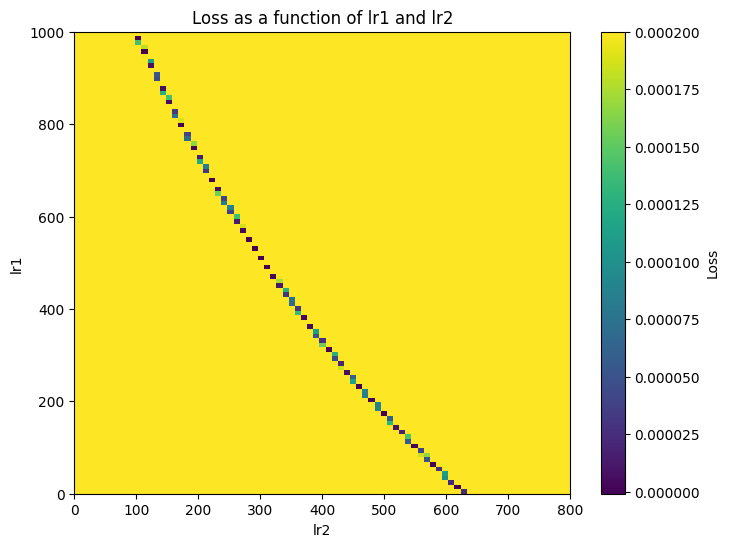

In [94]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0002:
            loss_grid[i, j] =0.0002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


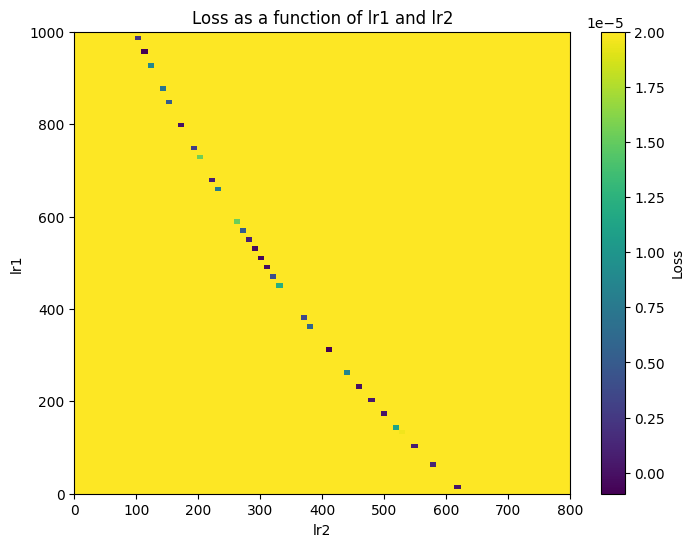

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.00002:
            loss_grid[i, j] =0.00002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


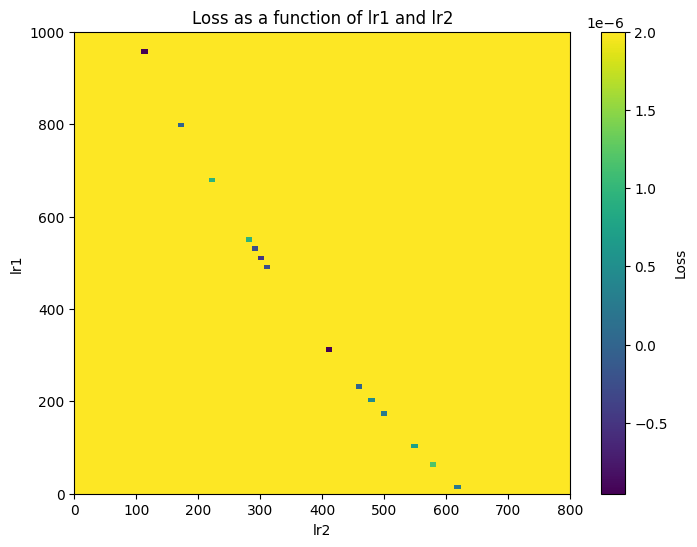

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.000002:
            loss_grid[i, j] =0.000002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


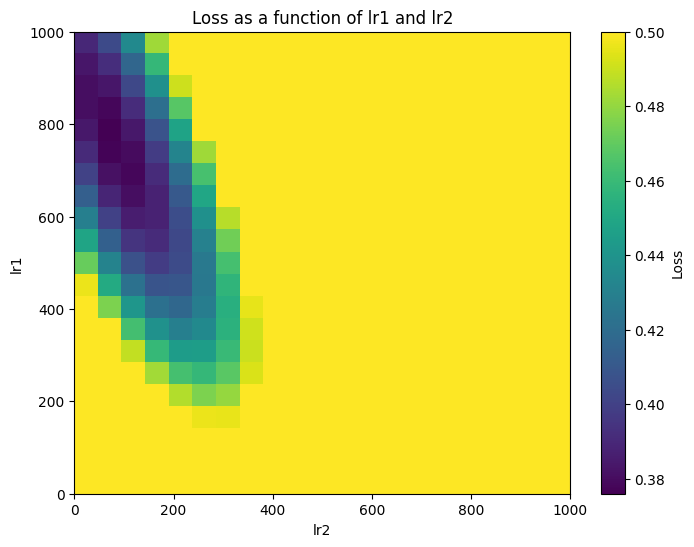

In [47]:
##consider seed 2025 with a larger number of test_data
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=200
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()/test_size
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


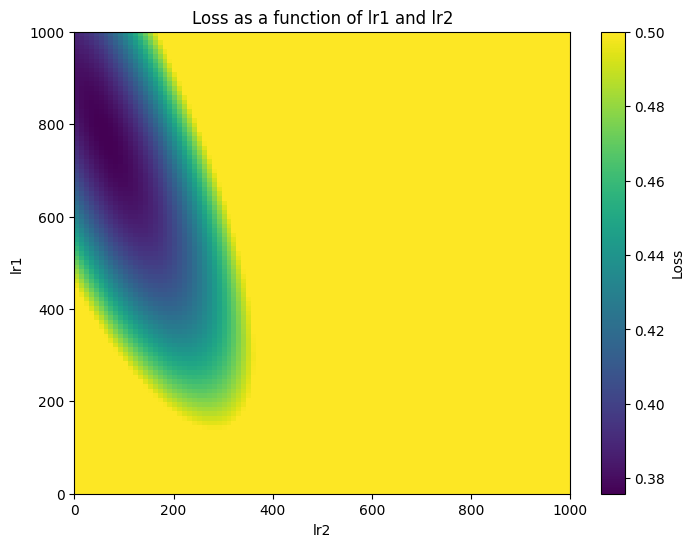

In [53]:
##consider seed 2025 with a larger number of test_data
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=200
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()/test_size
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


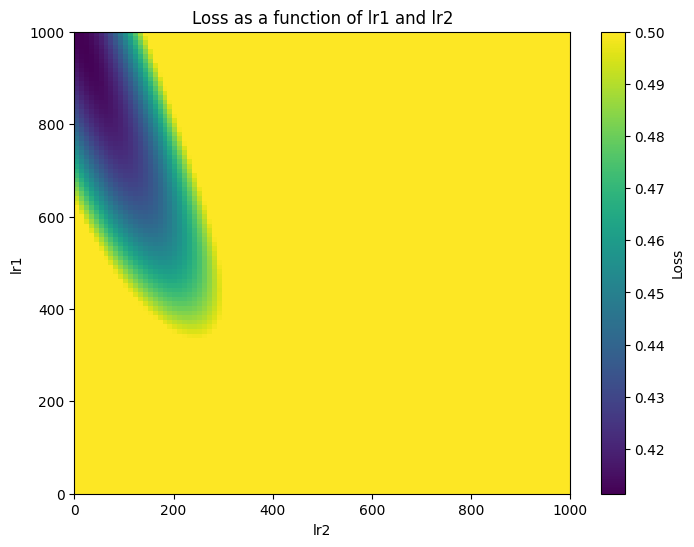

In [6]:
##consider seed 2025 with a larger number of test_data
## with many seeds


import torch
import numpy as np
import matplotlib.pyplot as plt
seeds=range(2020,2025)
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

    
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))
for seed in seeds:
# 
    
    torch.manual_seed(seed)

    # 参数初始化
    d = 1000
    h = 1500
    n = 2000
    rho = 0.2
    test_size=200
    x = torch.normal(mean=0, std=1, size=(test_size, d))

    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y = X @ beta + xi  # n x 1

    # 定义计算损失的函数


    # 定义LR1和LR2的范围
    

    # 网格搜索计算损失
    for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss.item()/test_size+loss_grid[i, j]
            #if loss_grid[i, j] >= 0.5:
            #    loss_grid[i, j] =0.5

for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            #_, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss_grid[i, j]/len(seeds)
            if loss_grid[i, j] >= 0.5:
                loss_grid[i, j] =0.5


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


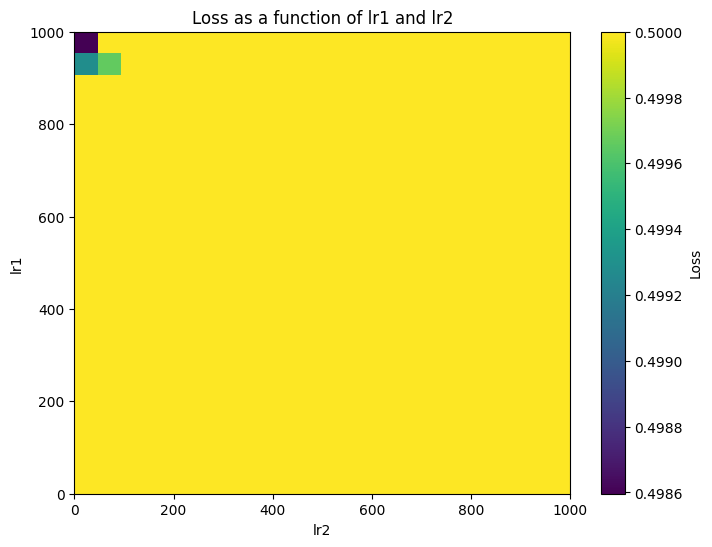

In [24]:
##consider seed 2025 with a larger number of test_data
## with many seeds
## check theoretical loss if we have  n=d=h, rho=0, then optimal loss is eta_1=2eta_2

import torch
import numpy as np
import matplotlib.pyplot as plt
seeds=range(2000,2025)
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

    
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))
for seed in seeds:
# 
    
    torch.manual_seed(seed)

    # 参数初始化
    d = 2000
    h = 2000
    n = 2000
    rho = 0
    test_size=200
    x = torch.normal(mean=0, std=1, size=(test_size, d))

    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y = X @ beta + xi  # n x 1

    # 定义计算损失的函数


    # 定义LR1和LR2的范围
    

    # 网格搜索计算损失
    for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss.item()/test_size+loss_grid[i, j]
            #if loss_grid[i, j] >= 0.5:
            #    loss_grid[i, j] =0.5

for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            #_, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss_grid[i, j]/len(seeds)
            if loss_grid[i, j] >= 0.5:
                loss_grid[i, j] =0.5


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


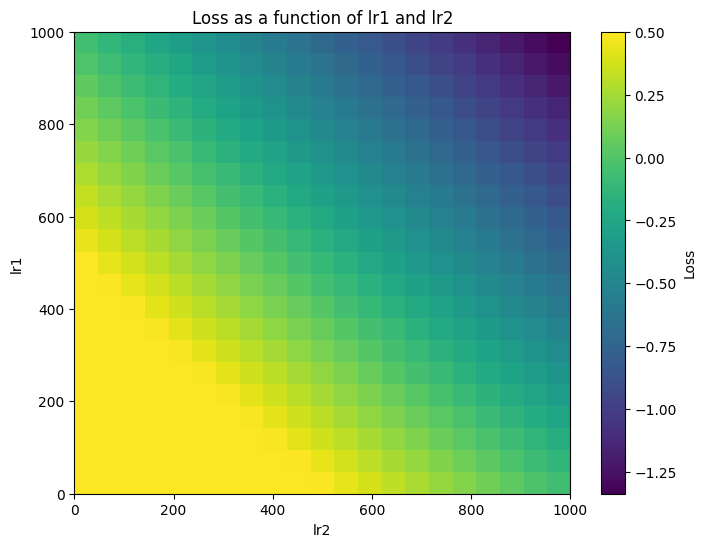

In [1]:
##consider seed 2025 with a larger number of test_data
## with many seeds
## check theoretical loss if we have  n=d=h, rho=0, then optimal loss is eta_1=2eta_2

import torch
import numpy as np
import matplotlib.pyplot as plt
seeds=range(2020,2025)
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    T1 = torch.trace((1/h) * (a@a.T @ W2.T @ W1.T @ W1 @ W2))
    T2 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ X.T @ y @ a.T @ W2.T@W2))
    T3 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W1.T @ W1@ W1.T @ X.T @ y @ a.T))
    T4 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W1.T @ X.T @ y @ a.T@ W2.T@W1.T@X.T@y@a.T))
    T5 = torch.trace((lr1/(n*h*np.sqrt(h))) * (a@a.T @ W2.T @ W2 @ a@ y.T @  X @ W1 @ W2))
    T6 = torch.trace((lr1**2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T@ X@X.T@y@a.T@W2.T@W2))
    T7 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ W1 @ W1.T @  X.T @ y@a.T))
    T8 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a@a.T  @ W2.T @ W2 @ a@ y.T @ X @ X.T @ y @  a.T @W2.T@W1.T@X.T@y@a.T))
    T9 = torch.trace((lr2/(n*h*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @ W2))
    T10 = torch.trace((lr1*lr2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y @ a.T@W2.T@W2))
    T11 = torch.trace((lr2**2/(n**2*h**2)) * (a@a.T@a@y.T@X@W1 @W1.T @ W1 @W1.T @ X.T @ y@a.T))
    T12 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a@a.T@a@y.T@X@W1 @W1.T @ X.T @ y@ a.T @ W2.T@ W1.T@X.T@y@a.T))
    T13 = torch.trace((lr1*lr2/(n**2*h**2)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ W1@W2))
    T14 = torch.trace((lr1**2*lr2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @X.T @ y@ a.T@W2.T @ W2))
    T15 = torch.trace((lr1*lr2**2/(n**3*h**2*np.sqrt(h))) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @W1 @ W1.T @ X.T @y@ a.T))
    T16 = torch.trace((lr1**2*lr2**2/(n**4 * h**3)) * (a @ a.T @a@ y.T@X @ W1 @ W2 @a@ y.T @ X @ X.T @ y@a.T@W2.T@W1.T@X.T@y@a.T))

    #L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L1=T1+T6+T7+T4+T10+T13+T16+T11
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

    
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))
for seed in seeds:
# 
    
    torch.manual_seed(seed)

    # 参数初始化
    d = 2000
    h = 2000
    n = 2000
    rho = 0
    test_size=200
    x = torch.normal(mean=0, std=1, size=(test_size, d))

    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y = X @ beta + xi  # n x 1

    # 定义计算损失的函数


    # 定义LR1和LR2的范围
    

    # 网格搜索计算损失
    for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss.item()/test_size+loss_grid[i, j]
            #if loss_grid[i, j] >= 0.5:
            #    loss_grid[i, j] =0.5

for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            #_, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
            loss_grid[i, j] = loss_grid[i, j]/len(seeds)
            if loss_grid[i, j] >= 0.5:
                loss_grid[i, j] =0.5


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


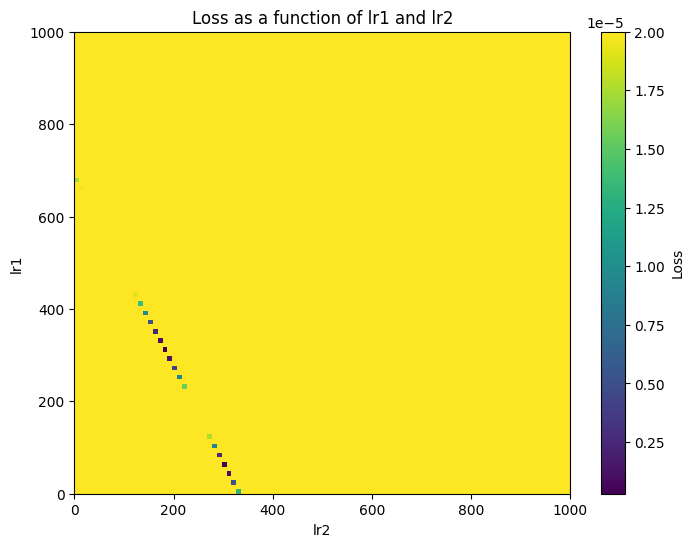

In [14]:
### consider different n,h,d for seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1500
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.00002:
            loss_grid[i, j] =0.00002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


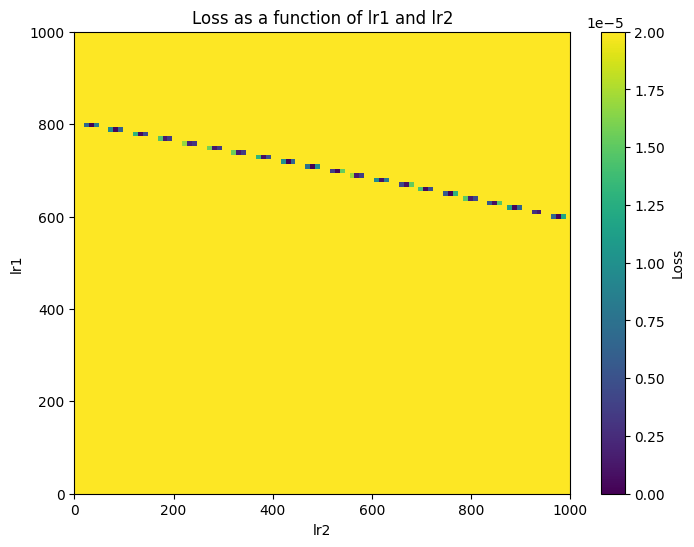

In [19]:
### consider different n,h,d for seed 2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 2000
h = 2000
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.00002:
            loss_grid[i, j] =0.00002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


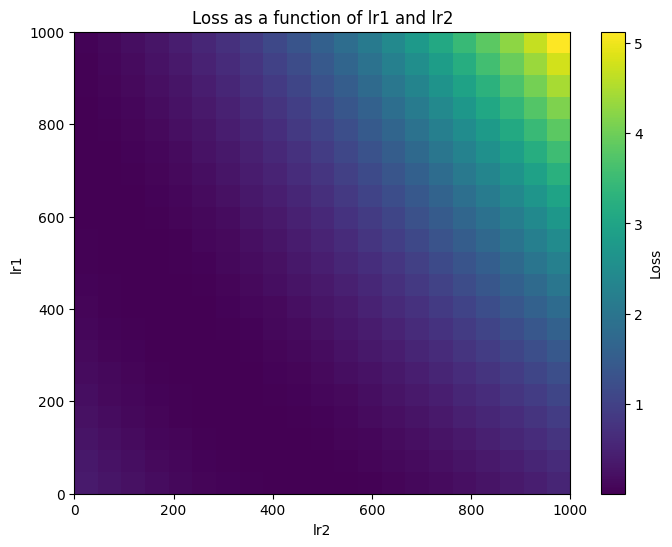

In [90]:
# seed 2024

import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


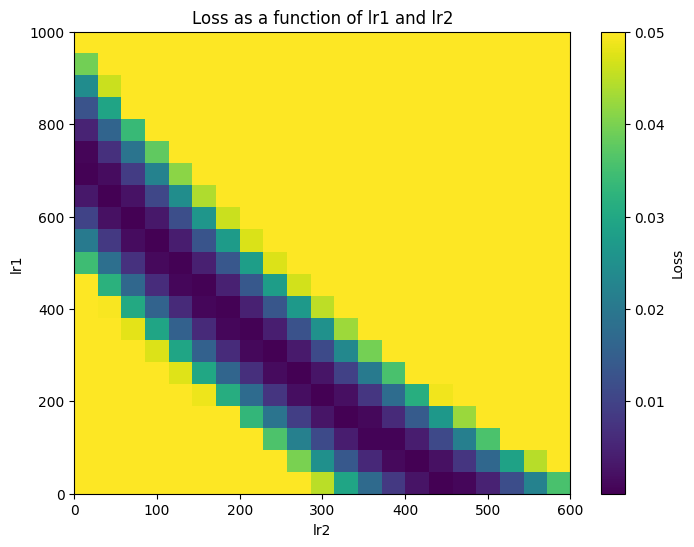

In [91]:
# seed 2024
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 601, 30)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.05:
            loss_grid[i, j] =0.05


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


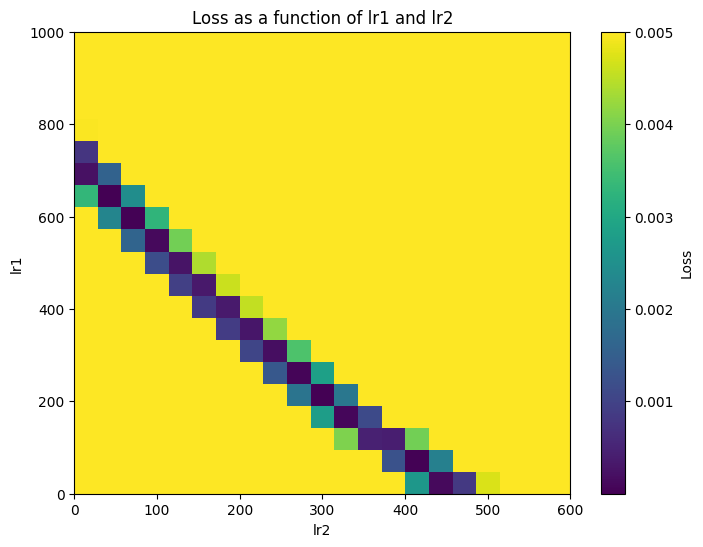

In [92]:
# seed 2024
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 601, 30)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.005:
            loss_grid[i, j] =0.005


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


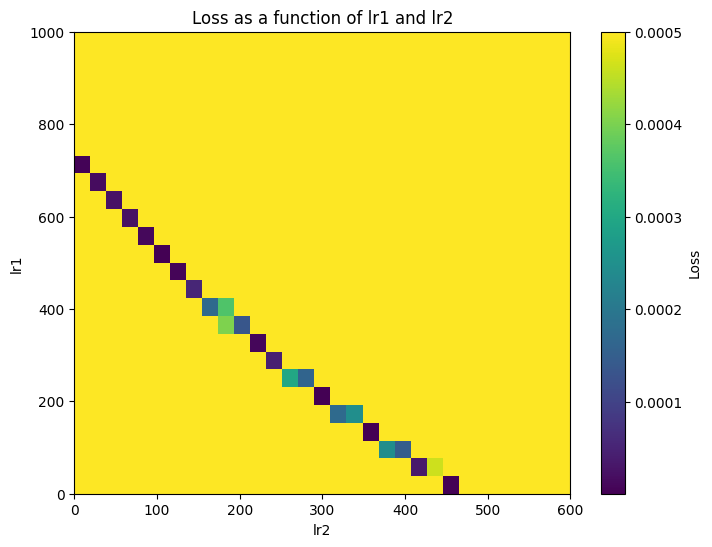

In [93]:
# seed 2024
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 40)  # 从0到2000，间隔50
lr2_range = np.arange(0, 601, 20)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0005:
            loss_grid[i, j] =0.0005


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


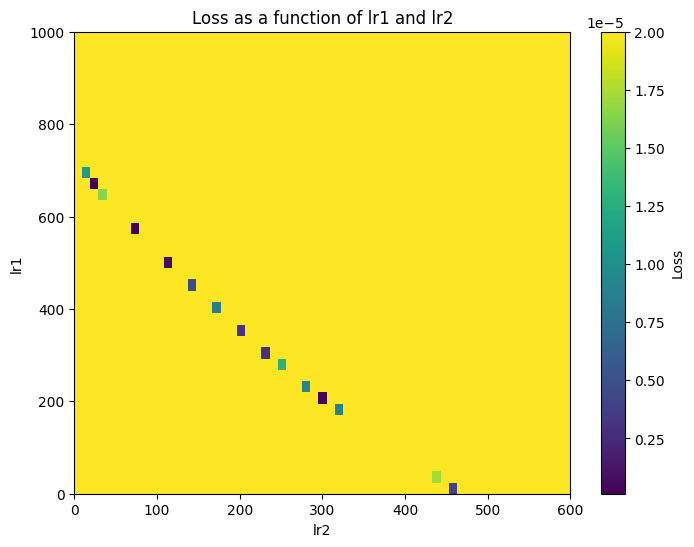

In [5]:
# seed 2024
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 25)  # 从0到2000，间隔50
lr2_range = np.arange(0, 601, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.00002:
            loss_grid[i, j] =0.00002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


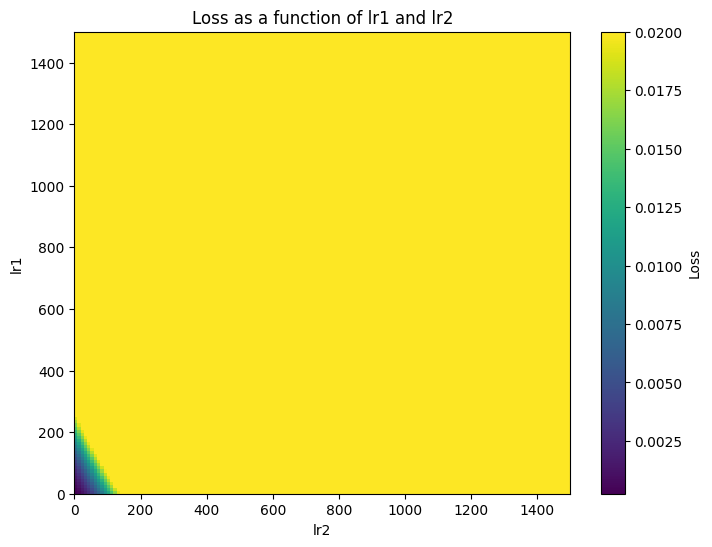

In [18]:
# seed 2024 consider different h d n
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 2000
h = 2000
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1501, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1501, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.02:
            loss_grid[i, j] =0.02


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


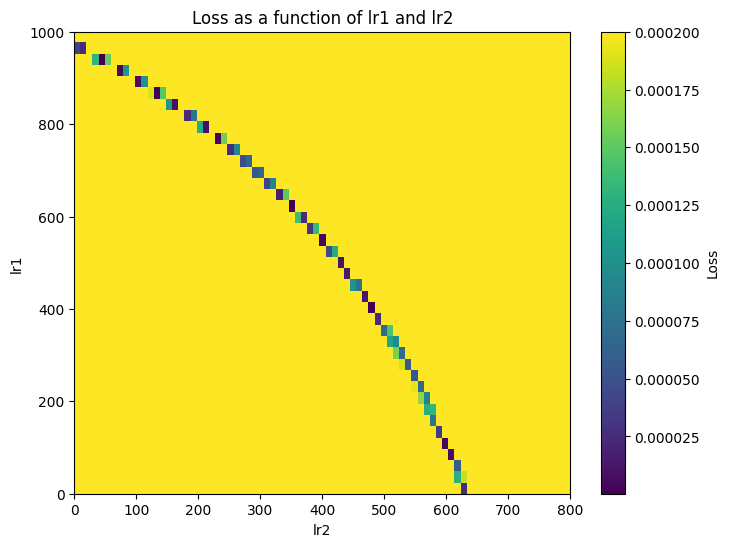

In [95]:
## seed 2023
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2023)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 25)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0002:
            loss_grid[i, j] =0.0002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


### update a

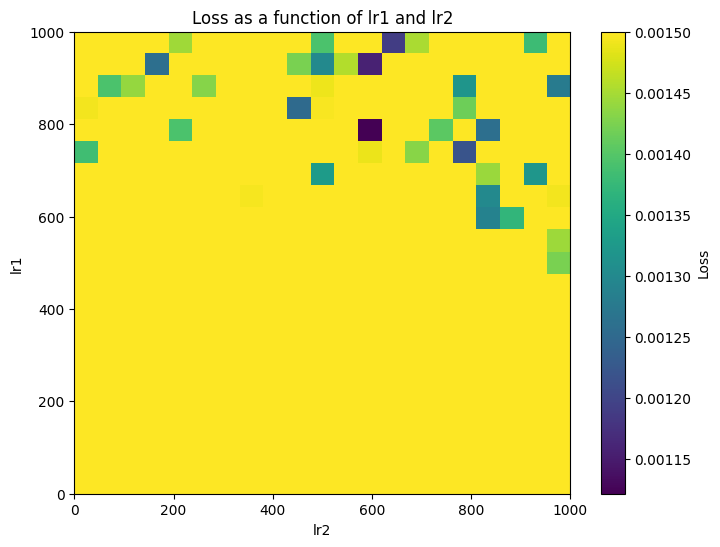

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2023)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
lamda=0.01

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

def compute_last_layer_weight(Z, y_t,lamda):
    n = Z.shape[0]
    h = Z.shape[1]
    I_h = torch.eye(Z.shape[1])
    a_hat = (
            torch.linalg.inv(Z.t() @ Z + (lamda / h) * n * I_h)
            @ Z.t()
            @ y_t
        )
    return a_hat

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    Z= 1/np.sqrt(h)*X@W1_update@W2_update

    a=compute_last_layer_weight(Z,y,lamda)







    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0015:
            loss_grid[i, j] =0.0015


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()





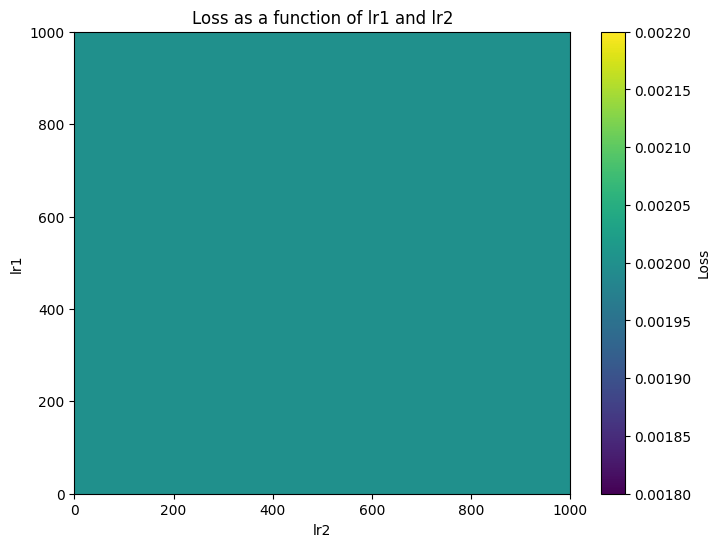

In [17]:
# update a 
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
lamda=0.01

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

def compute_last_layer_weight(Z, y_t,lamda):
    n = Z.shape[0]
    h = Z.shape[1]
    I_h = torch.eye(Z.shape[1])
    a_hat = (
            torch.linalg.inv(Z.t() @ Z + (lamda / h) * n * I_h)
            @ Z.t()
            @ y_t
        )
    return a_hat

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    Z= 1/np.sqrt(h)*X@W1_update@W2_update

    a=compute_last_layer_weight(Z,y,lamda)







    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.002:
            loss_grid[i, j] =0.002


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()





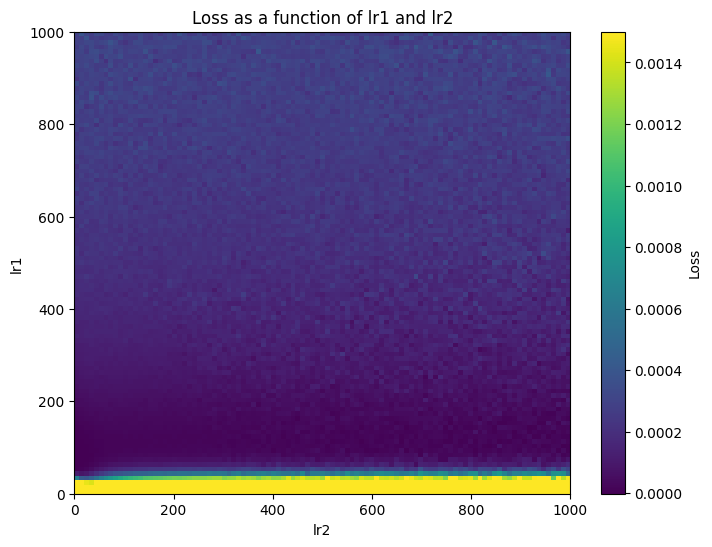

In [1]:
#update a
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
lamda=0.01

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

def compute_last_layer_weight(Z, y_t,lamda):
    n = Z.shape[0]
    h = Z.shape[1]
    I_h = torch.eye(Z.shape[1])
    a_hat = (
            torch.linalg.inv(Z.t() @ Z + (lamda / h) * n * I_h)
            @ Z.t()
            @ y_t
        )
    return a_hat

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    Z= 1/np.sqrt(h)*X@W1_update@W2_update

    a=compute_last_layer_weight(Z,y,lamda)







    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0015:
            loss_grid[i, j] =0.0015


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()





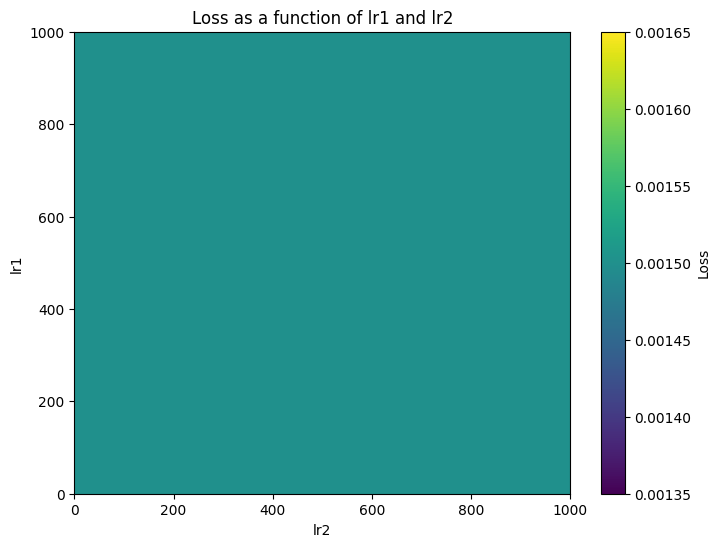

In [2]:
# update a 
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

# 参数初始化
d = 1500
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
lamda=0.01

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

def compute_last_layer_weight(Z, y_t,lamda):
    n = Z.shape[0]
    h = Z.shape[1]
    I_h = torch.eye(Z.shape[1])
    a_hat = (
            torch.linalg.inv(Z.t() @ Z + (lamda / h) * n * I_h)
            @ Z.t()
            @ y_t
        )
    return a_hat

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    Z= 1/np.sqrt(h)*X@W1_update@W2_update

    a=compute_last_layer_weight(Z,y,lamda)







    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a)
        loss_grid[i, j] = loss.item()
        if loss_grid[i, j] >= 0.0015:
            loss_grid[i, j] =0.0015


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()





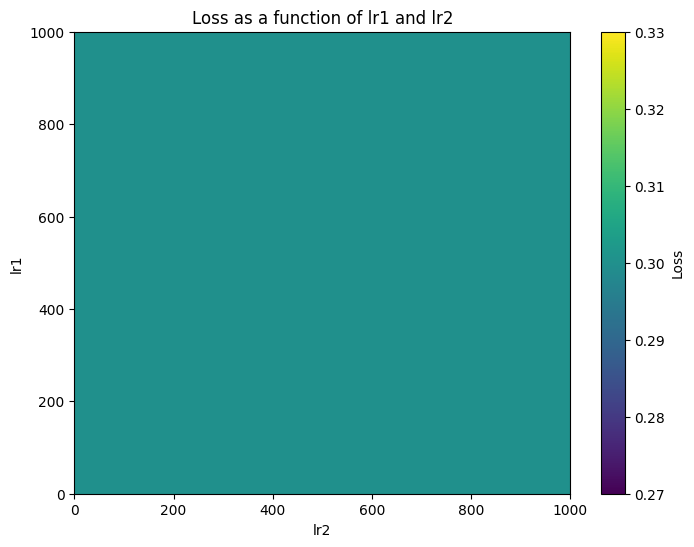

In [54]:
# update a  with a larger number of test_size
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

# 参数初始化
d = 1500
h = 1500
n = 2000
rho = 0.2

test_size=200
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
lamda=0.01

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

def compute_last_layer_weight(Z, y_t,lamda):
    n = Z.shape[0]
    h = Z.shape[1]
    I_h = torch.eye(Z.shape[1])
    a_hat = (
            torch.linalg.inv(Z.t() @ Z + (lamda / h) * n * I_h)
            @ Z.t()
            @ y_t
        )
    return a_hat

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

    Z= 1/np.sqrt(h)*X@W1_update@W2_update

    a=compute_last_layer_weight(Z,y,lamda)







    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 50)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        _, loss = compute_loss(W1, W2, X, lr1, lr2, y, beta, x,a)
        loss_grid[i, j] = loss.item()/test_size
        if loss_grid[i, j] >= 0.3:
            loss_grid[i, j] =0.3


# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()





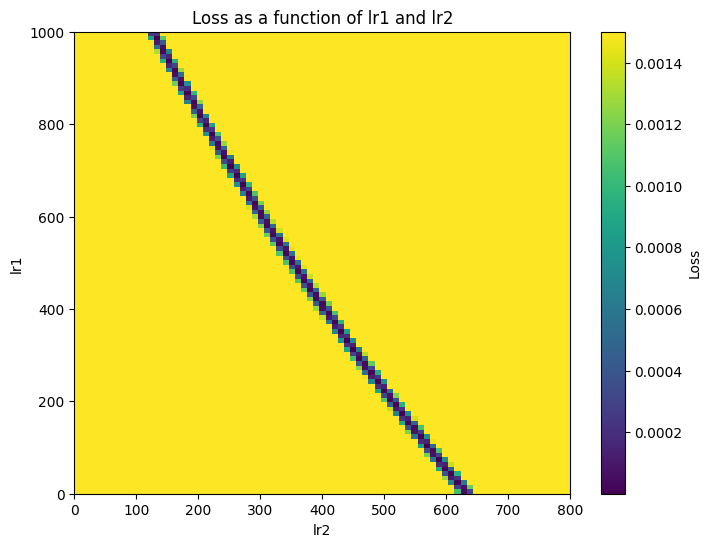

In [42]:
###use true gradien to search lr1 and lr2 seed2025
import torch 
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.0015:
            loss_grid[i, j] =0.0015

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


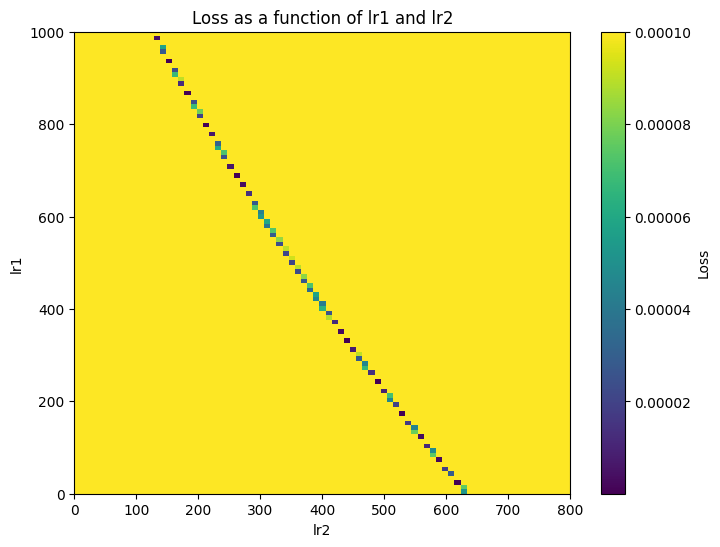

In [43]:
###use true gradien to search lr1 and lr2 seed2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.0001:
            loss_grid[i, j] =0.0001

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


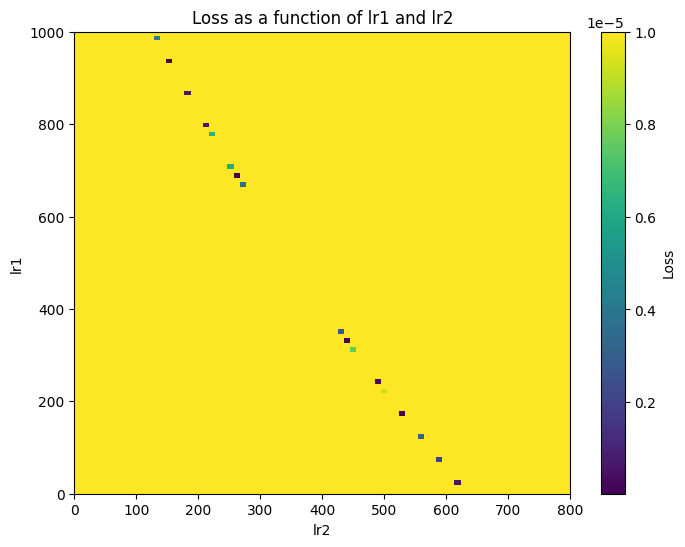

In [44]:
###use true gradien to search lr1 and lr2 seed2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.00001:
            loss_grid[i, j] =0.00001

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


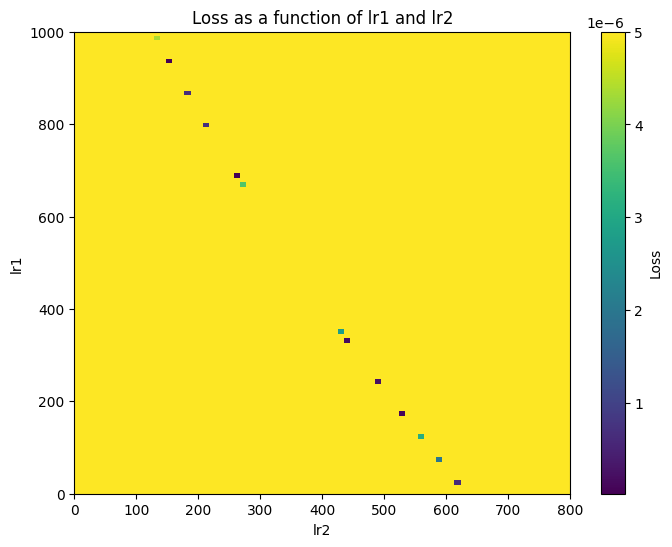

In [45]:
###use true gradien to search lr1 and lr2 seed2025
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2025)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001, 10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 801, 10)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.000005:
            loss_grid[i, j] =0.000005

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


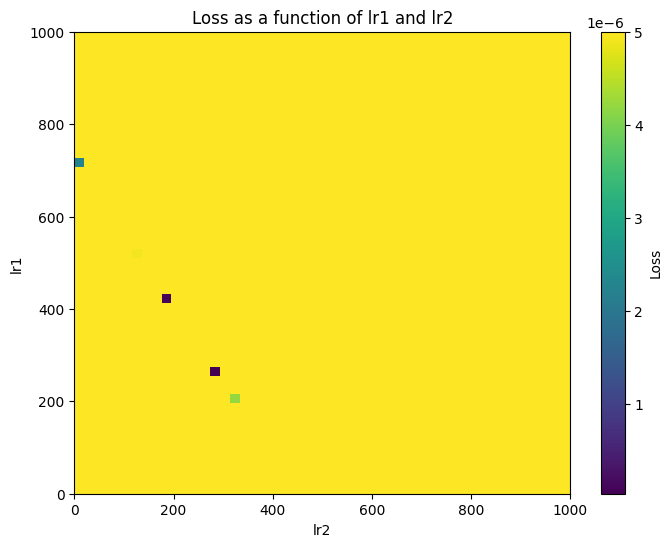

In [2]:
###use true gradien to search lr1 and lr2 seed 2024
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(2024)

# 参数初始化
d = 1000
h = 1500
n = 2000
rho = 0.2
x = torch.normal(mean=0, std=1, size=(1, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1

# 定义计算损失的函数
def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_

# 定义LR1和LR2的范围
lr1_range = np.arange(0, 1001,20)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001, 20)  # 从0到2000，间隔50

# 存储每对lr1, lr2的损失
loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

# 网格搜索计算损失
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.000005:
            loss_grid[i, j] =0.000005

# 绘制热力图
plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


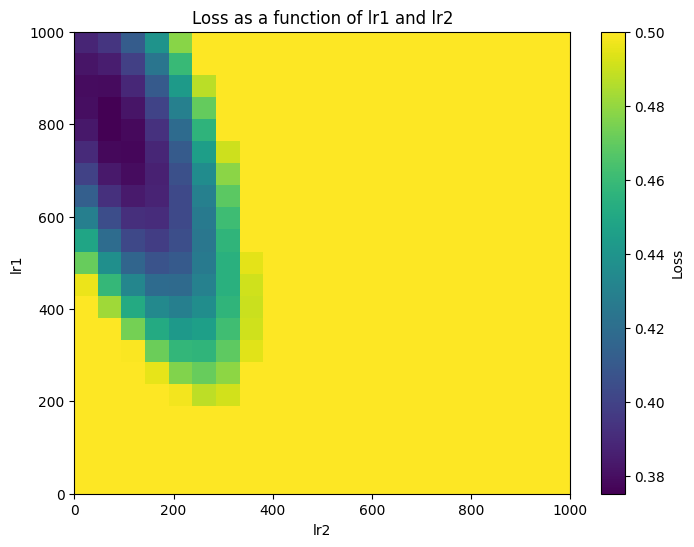

In [50]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=200
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,50)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


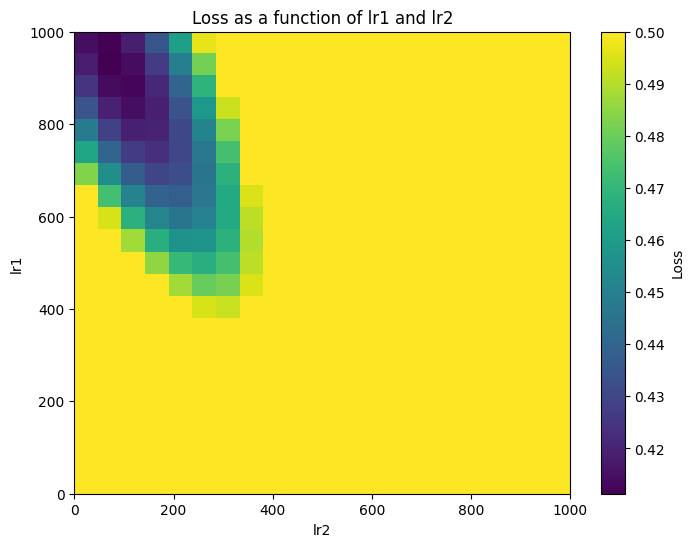

In [51]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,50)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,50)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


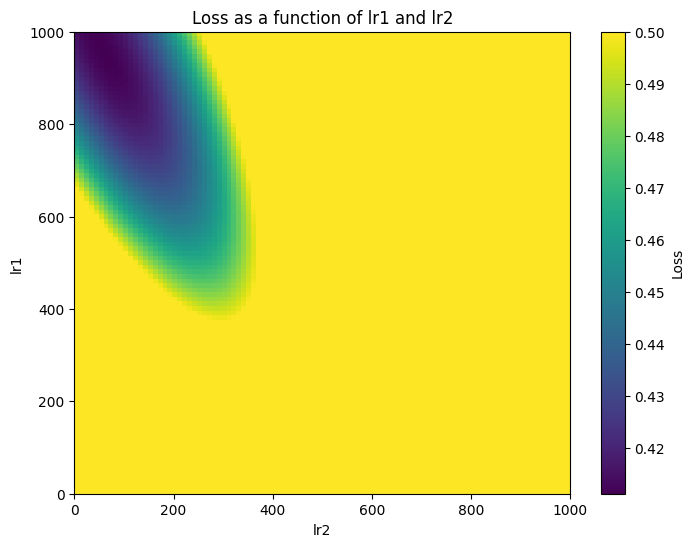

In [52]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,10)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


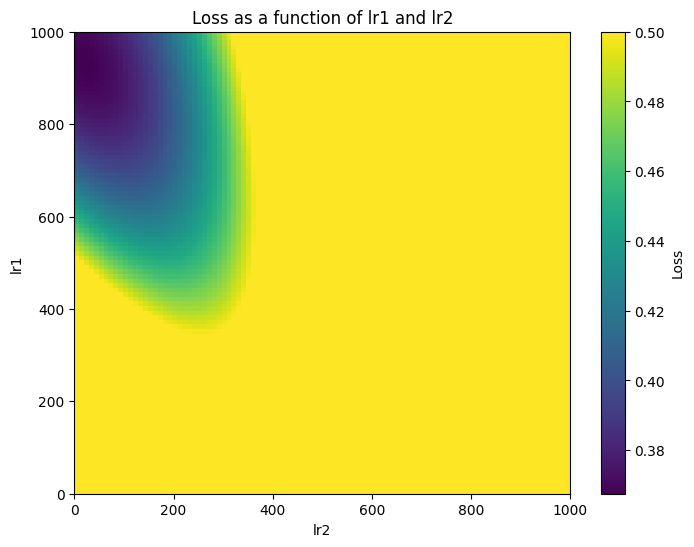

In [7]:
###use true gradient to search lr1 and lr2 with a larger number of test data
## with multiple seeds
import torch
import numpy as np
import matplotlib.pyplot as plt

seeds=range(2020,2025)

def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,10)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))

for seed in seeds:
    torch.manual_seed(seed)


    d = 1000
    h = 1500
    n = 2000
    rho = 0.2
    test_size=500
    x = torch.normal(mean=0, std=1, size=(test_size, d))

    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
    a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

    beta = torch.randn(size=[d])
    beta = beta / torch.norm(beta, p=2)
    beta = beta.unsqueeze(1)
    y = X @ beta + xi  # n x 1







    for i, lr1 in enumerate(lr1_range):
        for j, lr2 in enumerate(lr2_range):
            #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
            #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
            W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
            W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
            #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
            #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
            #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
            #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
            Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

            loss_grid[i, j] = Loss+loss_grid[i, j] 
            #if loss_grid[i, j] >= 0.5:
                #loss_grid[i, j] =0.5
            
for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):


        loss_grid[i, j] = loss_grid[i, j]/len(seeds)
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5

plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


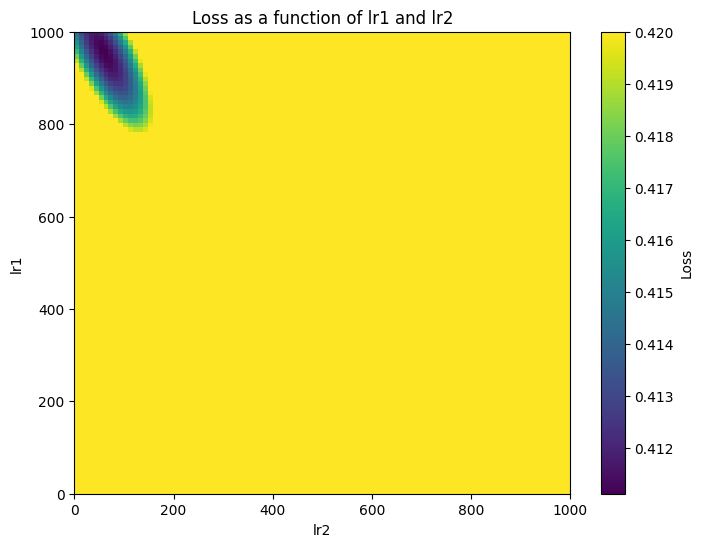

In [55]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1000
h = 1500
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,10)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.42:
            loss_grid[i, j] =0.42


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


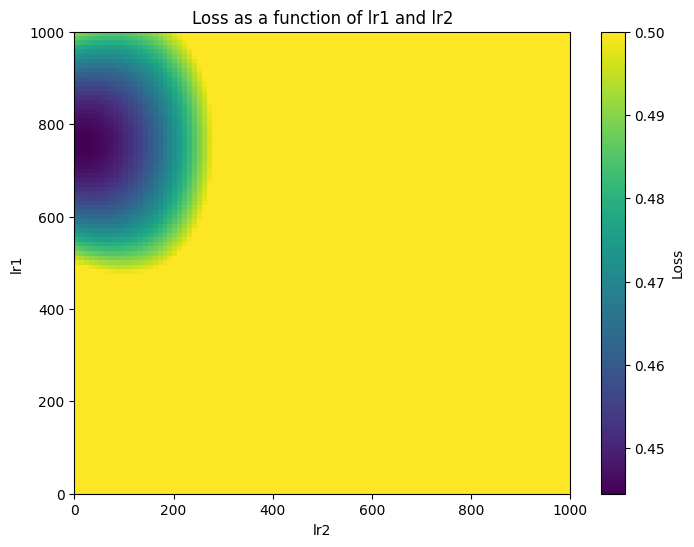

In [56]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1500
h = 1500
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,10)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


In [57]:
###use true gradient to search lr1 and lr2 with a larger number of test data
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 2000
h = 2000
n = 2500
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1))  # n x 1
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.randn(size=[d])
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(0, 1001,10)  # 从0到2000，间隔50
lr2_range = np.arange(0, 1001,10)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        Loss=1/test_size*(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta).T@(1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta)

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.5:
            loss_grid[i, j] =0.5


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


KeyboardInterrupt: 

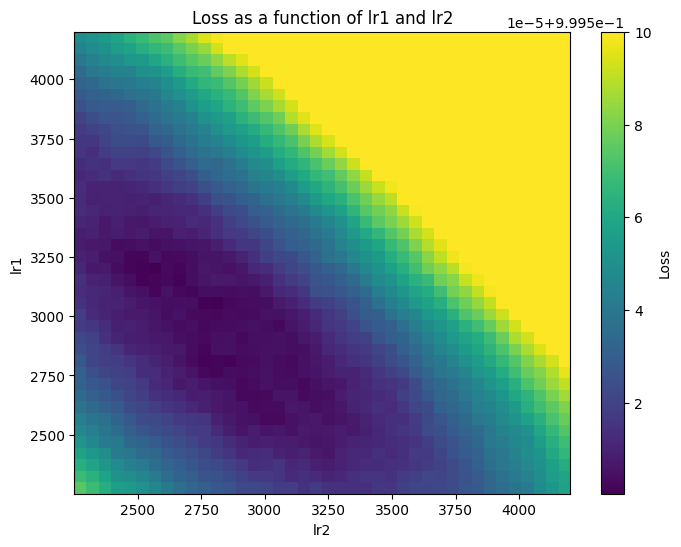

In [26]:
###use true gradient to search lr1 and lr2 with a larger number of test data
### set a=identity
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 2000
h = 2000
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
a=1/np.sqrt(h)*torch.eye(h)
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(2251, 4251,50)  # 从0到2000，间隔50
lr2_range = np.arange(2251, 4251,50)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        loss_matrix=1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta
        loss_matrix_F_norm=torch.norm(loss_matrix, 'fro')

        Loss=1/test_size*loss_matrix_F_norm*loss_matrix_F_norm

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.9996:
            loss_grid[i, j] =0.9996


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


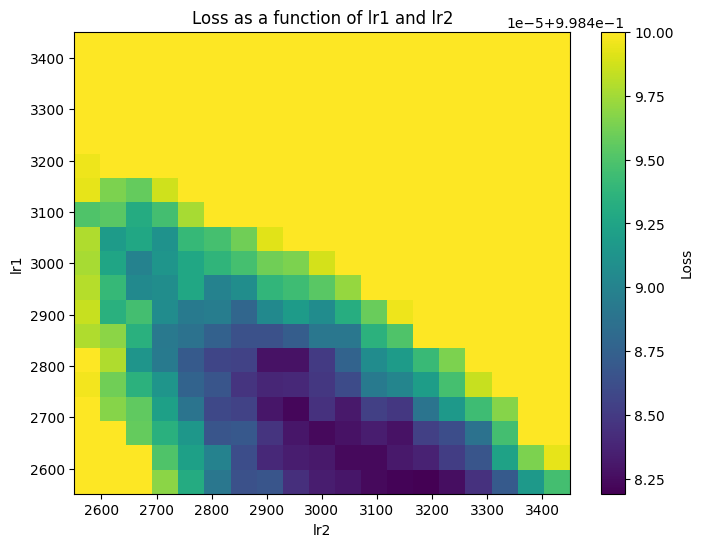

In [8]:
###use true gradient to search lr1 and lr2 with a larger number of test data
### set a=identity
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(2025)


d = 1500
h = 1500
n = 2000
rho = 0.2
test_size=500
x = torch.normal(mean=0, std=1, size=(test_size, d))

W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
X = torch.normal(mean=0, std=1, size=(n, d))             # n x d
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
a=1/np.sqrt(h)*torch.eye(h)
#a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1

beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
beta = beta / torch.norm(beta, p=2)
#beta = beta.unsqueeze(1)
y = X @ beta + xi  # n x 1


def compute_loss(W1, W2, X, lr1, lr2, y, beta, x):
    L = {}
    W1_update = W1 + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
    W2_update = W2 + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T
    L1 = torch.trace(1/h * x.T @ x @ W1_update @ W2_update @ a @ a.T @ W2_update.T @ W1_update.T)
    L2 = torch.trace(1/np.sqrt(h) * x.T @ x @ beta @ a.T @ W2_update.T @ W1_update.T)
    L3 = torch.trace(1/np.sqrt(h) * x.T @ x @ W1_update @ W2_update @ a @ beta.T)
    L4 = torch.trace(x.T @ x @ beta @ beta.T)

    L[1] = L1
    L[2] = L2
    L[3] = L3
    L[4] = L4

    L_ = L1 - L2 - L3 + L4
    return L, L_


lr1_range = np.arange(2551, 3501,50)  # 从0到2000，间隔50
lr2_range = np.arange(2551, 3501,50)  # 从0到2000，间隔50


loss_grid = np.zeros((len(lr1_range), len(lr2_range)))


for i, lr1 in enumerate(lr1_range):
    for j, lr2 in enumerate(lr2_range):
        #W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        #W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        W1_true=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_true=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
        #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T
        #Loss_true_1=(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)*(1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta)
        #Loss_true_2=(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
        loss_matrix=1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta
        loss_matrix_F_norm=torch.norm(loss_matrix, 'fro')

        Loss=1/test_size*loss_matrix_F_norm*loss_matrix_F_norm

        loss_grid[i, j] = Loss
        if loss_grid[i, j] >= 0.99850:
            loss_grid[i, j] =0.99850


plt.figure(figsize=(8, 6))
plt.imshow(loss_grid, aspect='auto', cmap='viridis', origin='lower', 
           extent=[lr2_range[0], lr2_range[-1], lr1_range[0], lr1_range[-1]])
plt.colorbar(label='Loss')
plt.xlabel('lr2')
plt.ylabel('lr1')
plt.title('Loss as a function of lr1 and lr2')
plt.show()


In [29]:
# To test whether we can apply the approximated gradient to update  (from the perspective of loss) 
# try larger number of test data
# with more seeds
#set a as identity
import torch
import numpy as np
seeds=range(2005,2025)
L_dict={}
for i in range(4):
    L_dict[i+1]=0
Loss_true=0
Loss_decompose=0
Loss_appro=0
for seed in seeds:
    torch.manual_seed(seed)
    d = 1500
    h = 1500
    n = 2000  
    rho =0.2
    lr1=3000
    lr2=3000
    #lr=[(20,20),(2000,2000),(4000,4000),(4000000,4000000),(16000000,16000000)]

    test_size=500
    W1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))  # d x h
    W2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h))  # h x h
    X = torch.normal(mean=0, std=1, size=(n, d))     # n x d
    xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h))  # n x 1
    #a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1))   # h x 1
    a= 1/np.sqrt(h)*torch.eye(h)
    #beta = torch.normal(mean=0, std=1/d, size=(d, 1))
    x=torch.normal(mean=0, std=1, size=(test_size, d))

    beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h))
    beta = beta / torch.norm(beta, p=2)
    #beta = beta.unsqueeze(1)
    y=X@beta+xi



    def compute_loss(W1,W2,X,lr1,lr2,y,beta,x):
        L={}
        W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
        W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
        L1=torch.trace(1/h*x.T@x@W1_update@ W2_update@a@a.T@ W2_update.T@ W1_update.T)
        L2=torch.trace(1/np.sqrt(h)*x.T@x@ beta@a.T@ W2_update.T@ W1_update.T)
        L3=torch.trace(1/np.sqrt(h)* x.T@x@W1_update@W2_update@a@beta.T)
        L4=torch.trace(x.T@x@beta@beta.T)

        L[1] = L1
        L[2] = L2
        L[3] = L3
        L[4] = L4

        L_=L1-L2-L3+L4

        return L, L_


    loss, loss_ = compute_loss(W1,W2,X,lr1,lr2,y,beta,x)

    for i in range(4):
        L_dict[i+1]=L_dict[i+1]+ loss[i+1]/test_size
    #print(loss_/test_size)
    Loss_decompose= Loss_decompose+loss_.item()/test_size


    #for t, value in loss.items():
        #print(f"L{t}: {value.item()}")
    

       # print('#############################')

    W1_update=W1+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_update=W2+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    W1_true=W1-(lr1/(n*h))*X.T@X@W1@W2@a@a.T@W2.T+(lr1/(n*np.sqrt(h)))*X.T@y@a.T@W2.T
    W2_true=W2-(lr2/(n*h))*W1.T@X.T@X@W1@W2@a@a.T+(lr2/(n*np.sqrt(h)))*W1.T@X.T@y@a.T
    #W1_supdate=W1-lr1/(n*h)*X.T@X@W1@W2@a@a.T@W2.T
    #W2_supdate=W2-lr2/(n*h)*W1.T@X.T@X@W1@W2@a@a.T

    loss_matrix_appro=1/np.sqrt(h)*x@W1_update@W2_update@a-x@beta
    loss_matrix_F_norm_appro=torch.norm(loss_matrix_appro, 'fro')

    loss_matrix=1/np.sqrt(h)*x@W1_true@W2_true@a-x@beta
    loss_matrix_F_norm=torch.norm(loss_matrix, 'fro')

    Loss=1/test_size*loss_matrix_F_norm*loss_matrix_F_norm
    Loss_appro=Loss_appro+1/test_size* loss_matrix_F_norm_appro* loss_matrix_F_norm_appro
    #Loss_true_2=1/test_size*(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta).T@(1/np.sqrt(h)*x@W1_supdate@W2_supdate@a-x@beta)
    Loss_true=Loss_true+1/test_size*loss_matrix_F_norm*loss_matrix_F_norm


print(f'Loss_decompose:{Loss_decompose/len(seeds)}')
for t, value in L_dict.items():
    print(f"L{t}: {value.item()/len(seeds)}")
print(f'Loss_appro:{Loss_appro/len(seeds)}')
print(f'Loss_true:{Loss_true/len(seeds)}')

Loss_decompose:0.9983194854736329
L1: 0.0033298730850219727
L2: 0.0026569457724690436
L3: 0.0026569457724690436
L4: 1.0003034591674804
Loss_appro:0.998306930065155
Loss_true:0.9983012080192566


[1.08493115e+03 3.97440839e+00 3.92383790e+00 3.90986776e+00
 3.84848070e+00 3.82973552e+00 3.78851414e+00 3.77430058e+00
 3.73997688e+00 3.70973134e+00 3.70851564e+00 3.67797017e+00
 3.66645908e+00 3.64252138e+00 3.63126206e+00 3.61510086e+00
 3.60987711e+00 3.57364988e+00 3.56401849e+00 3.54655933e+00
 3.52415681e+00 3.51429415e+00 3.50483131e+00 3.48396039e+00
 3.46766520e+00 3.43023419e+00 3.42398739e+00 3.41826558e+00
 3.39541197e+00 3.36848617e+00 3.36463022e+00 3.35339999e+00
 3.32102919e+00 3.30354476e+00 3.29866004e+00 3.29020882e+00
 3.26739287e+00 3.25868058e+00 3.24865031e+00 3.23689318e+00
 3.22169328e+00 3.21030831e+00 3.19573426e+00 3.17273307e+00
 3.16288447e+00 3.15783334e+00 3.13779306e+00 3.13400650e+00
 3.12404704e+00 3.11472940e+00 3.10447431e+00 3.09881544e+00
 3.07651305e+00 3.06346369e+00 3.05622888e+00 3.04656076e+00
 3.03802156e+00 3.02138305e+00 3.01414943e+00 3.00073075e+00
 2.98288560e+00 2.97795033e+00 2.96697998e+00 2.95562649e+00
 2.94340467e+00 2.929431

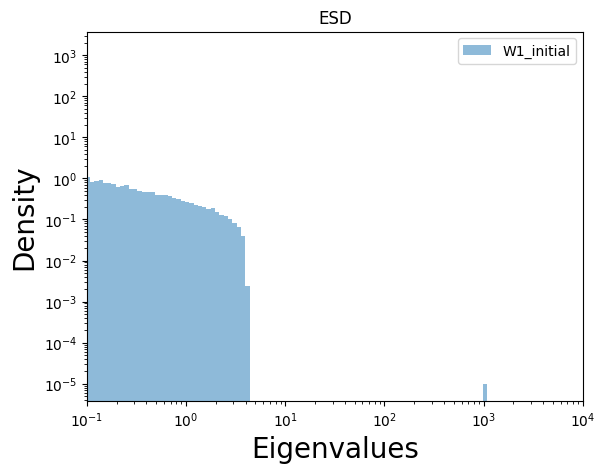

[9.66032791e+01 3.97148991e+00 3.93828750e+00 3.90646124e+00
 3.84508967e+00 3.81368184e+00 3.80818176e+00 3.75197697e+00
 3.74546766e+00 3.72757864e+00 3.67753696e+00 3.66726422e+00
 3.65542865e+00 3.63814521e+00 3.61749244e+00 3.59896350e+00
 3.58221412e+00 3.54489350e+00 3.53380680e+00 3.52361012e+00
 3.49987340e+00 3.49657464e+00 3.48282433e+00 3.44115734e+00
 3.43798637e+00 3.41530180e+00 3.40576243e+00 3.38233709e+00
 3.37611389e+00 3.36429644e+00 3.34529328e+00 3.32882404e+00
 3.31424475e+00 3.30294371e+00 3.29660845e+00 3.28327560e+00
 3.27826500e+00 3.25828338e+00 3.23989916e+00 3.22554493e+00
 3.20868230e+00 3.20488238e+00 3.18568993e+00 3.18049860e+00
 3.16809773e+00 3.15023518e+00 3.14833951e+00 3.13766432e+00
 3.12132955e+00 3.10142541e+00 3.08507800e+00 3.07561231e+00
 3.07026958e+00 3.06103182e+00 3.05066252e+00 3.03754568e+00
 3.02163005e+00 3.00965381e+00 3.00221729e+00 2.98782969e+00
 2.98491096e+00 2.97157598e+00 2.95899034e+00 2.94775748e+00
 2.94214106e+00 2.936776

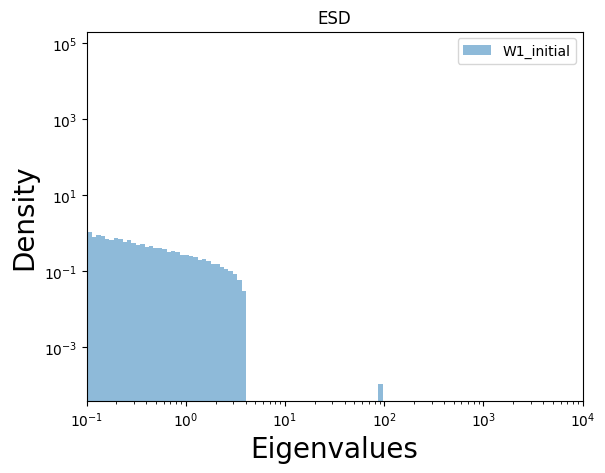

In [96]:
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u1 = torch.normal(mean=0, std=1, size=(d, 1), device=device)
u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000,100
I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

print_esd(W1,"W1_initial")
print_esd(W2,"W1_initial")


[1.01505127e+02 3.94521666e+00 3.91336465e+00 3.87747455e+00
 3.84000635e+00 3.82594085e+00 3.77811480e+00 3.74641371e+00
 3.72533345e+00 3.72311854e+00 3.68157363e+00 3.64637685e+00
 3.64618254e+00 3.62931871e+00 3.60370016e+00 3.59933639e+00
 3.58084607e+00 3.56734657e+00 3.53710365e+00 3.50948048e+00
 3.49732399e+00 3.48359728e+00 3.47606039e+00 3.46430063e+00
 3.43273258e+00 3.41760564e+00 3.39954042e+00 3.38756800e+00
 3.38638282e+00 3.35366678e+00 3.32777143e+00 3.31436110e+00
 3.30352855e+00 3.30038667e+00 3.27954817e+00 3.27438879e+00
 3.27085137e+00 3.26141691e+00 3.25064492e+00 3.22820735e+00
 3.22433972e+00 3.21147752e+00 3.19609690e+00 3.19243073e+00
 3.17560029e+00 3.17204356e+00 3.14555621e+00 3.13037395e+00
 3.12443662e+00 3.12037134e+00 3.10827112e+00 3.09492159e+00
 3.07691932e+00 3.06244087e+00 3.05306602e+00 3.03415489e+00
 3.02295589e+00 3.01132131e+00 3.00419641e+00 3.00114107e+00
 2.98764253e+00 2.96914649e+00 2.95948911e+00 2.94471431e+00
 2.93122697e+00 2.922893

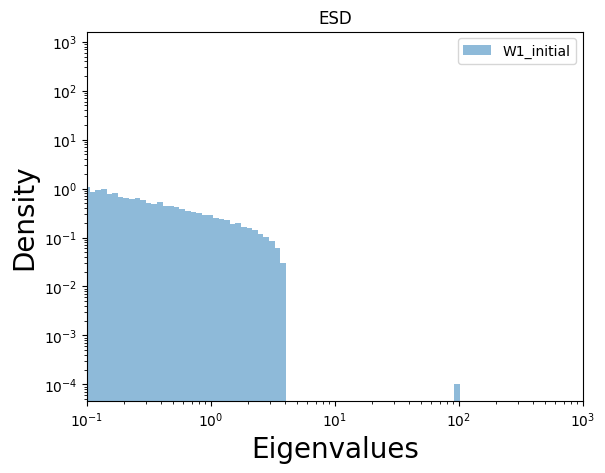

[9.66614868e+02 3.93192220e+00 3.88365221e+00 3.86615562e+00
 3.83944273e+00 3.81348324e+00 3.79239225e+00 3.76898289e+00
 3.75159764e+00 3.71991038e+00 3.71203661e+00 3.67943954e+00
 3.66994858e+00 3.64632845e+00 3.63988853e+00 3.62776780e+00
 3.60888767e+00 3.57083249e+00 3.56043649e+00 3.52768111e+00
 3.49580646e+00 3.48597264e+00 3.45714140e+00 3.45290899e+00
 3.44773459e+00 3.42565084e+00 3.41897607e+00 3.41438675e+00
 3.39373469e+00 3.38443923e+00 3.36290359e+00 3.35053158e+00
 3.33001208e+00 3.31421256e+00 3.30599189e+00 3.29677367e+00
 3.27686262e+00 3.25889611e+00 3.24907756e+00 3.22965574e+00
 3.21972370e+00 3.19596386e+00 3.19017673e+00 3.17533398e+00
 3.16173124e+00 3.15493345e+00 3.15104342e+00 3.13754630e+00
 3.11281109e+00 3.09692407e+00 3.08805370e+00 3.07704520e+00
 3.06852722e+00 3.05842042e+00 3.05507278e+00 3.04341125e+00
 3.02474618e+00 3.01310587e+00 3.01017761e+00 2.98429203e+00
 2.97822976e+00 2.96857429e+00 2.95551801e+00 2.94154263e+00
 2.93271565e+00 2.927934

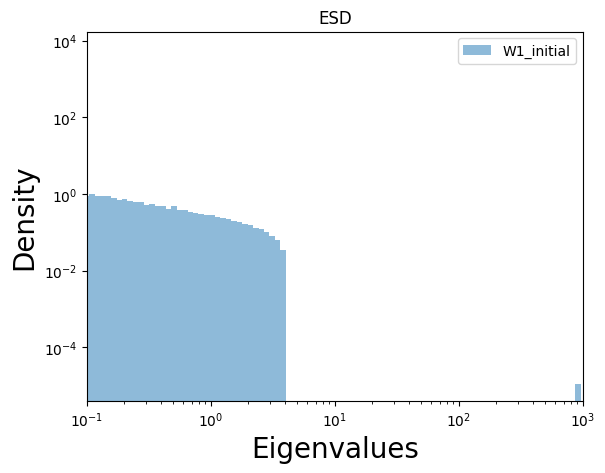

In [84]:
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e3)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u1 = torch.normal(mean=0, std=1, size=(d, 1), device=device)
u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 100,1000
I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

print_esd(W1,"W1_initial")
print_esd(W2,"W1_initial")


[1.02969067e+03 4.89271362e+02 3.94561553e+00 3.90700245e+00
 3.87369776e+00 3.85321116e+00 3.79238272e+00 3.76191425e+00
 3.74489021e+00 3.71054077e+00 3.68815017e+00 3.67178559e+00
 3.64822078e+00 3.63037539e+00 3.62132382e+00 3.61216807e+00
 3.58410954e+00 3.55035138e+00 3.54055977e+00 3.52921295e+00
 3.50250745e+00 3.49148011e+00 3.47999406e+00 3.44619417e+00
 3.43990111e+00 3.42040801e+00 3.41166186e+00 3.40142298e+00
 3.36380839e+00 3.35064983e+00 3.34172535e+00 3.32123375e+00
 3.30847096e+00 3.29801488e+00 3.27686882e+00 3.26828694e+00
 3.26422977e+00 3.25080657e+00 3.23920226e+00 3.23140955e+00
 3.21858239e+00 3.19921470e+00 3.19162583e+00 3.17523360e+00
 3.16082025e+00 3.15822673e+00 3.14076924e+00 3.13613892e+00
 3.11319065e+00 3.10476398e+00 3.10043049e+00 3.08652949e+00
 3.07069707e+00 3.05777550e+00 3.03742218e+00 3.02817845e+00
 3.01388383e+00 3.01074576e+00 3.00274777e+00 2.98684597e+00
 2.98389244e+00 2.96864343e+00 2.95454764e+00 2.94514203e+00
 2.93498993e+00 2.916605

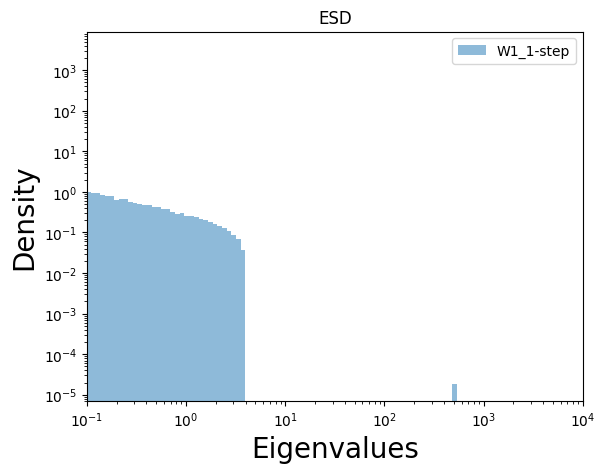

[2.01945081e+03 9.05221100e+01 3.98163509e+00 3.96056843e+00
 3.90568709e+00 3.83903122e+00 3.80672479e+00 3.79814053e+00
 3.75186300e+00 3.72015381e+00 3.71583796e+00 3.69861579e+00
 3.67602158e+00 3.65396070e+00 3.64207435e+00 3.62072539e+00
 3.59627008e+00 3.57893848e+00 3.56298804e+00 3.54762626e+00
 3.52175045e+00 3.51309967e+00 3.49800348e+00 3.49523926e+00
 3.47263622e+00 3.44261885e+00 3.42420983e+00 3.40900111e+00
 3.38862467e+00 3.37265205e+00 3.35252786e+00 3.33003378e+00
 3.31742430e+00 3.29962087e+00 3.29244089e+00 3.28672743e+00
 3.26810408e+00 3.25825596e+00 3.25024295e+00 3.23740816e+00
 3.22629094e+00 3.20881367e+00 3.19871330e+00 3.18479967e+00
 3.17564750e+00 3.15708852e+00 3.14794588e+00 3.14177012e+00
 3.13133812e+00 3.11996698e+00 3.10250831e+00 3.09675407e+00
 3.08692169e+00 3.08484864e+00 3.06421661e+00 3.05775070e+00
 3.04510403e+00 3.02743554e+00 3.01294422e+00 2.99376535e+00
 2.98523593e+00 2.97727585e+00 2.96970296e+00 2.95572424e+00
 2.94590807e+00 2.934426

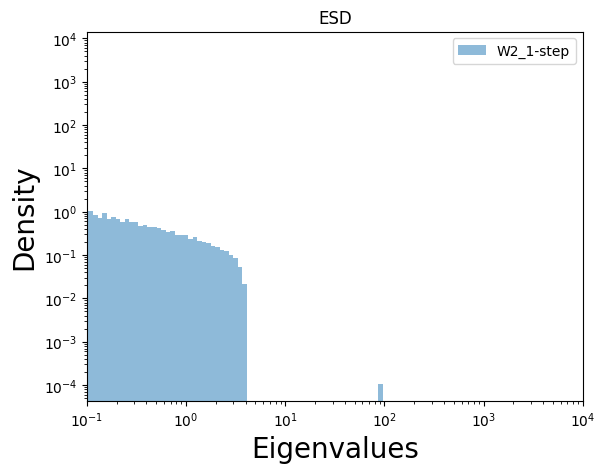

In [92]:
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
rho = 0
test_size = 500

x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)
u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000,100
lr1=500
lr2=1000

I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi

W1_true = W1 - lr1/(n*h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1/(n*np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2/(n*h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2/(n*np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[7.13805054e+02 1.07915886e+02 3.89430833e+00 3.83222890e+00
 3.82223630e+00 3.80231500e+00 3.78049660e+00 3.76760674e+00
 3.73239183e+00 3.71746159e+00 3.70997715e+00 3.68412328e+00
 3.65193605e+00 3.64794898e+00 3.61660218e+00 3.57783246e+00
 3.56427622e+00 3.55284595e+00 3.53169703e+00 3.51337814e+00
 3.49598908e+00 3.48150468e+00 3.47480512e+00 3.45296979e+00
 3.45057797e+00 3.43095469e+00 3.42621922e+00 3.39102936e+00
 3.38111711e+00 3.35969567e+00 3.34533668e+00 3.33682323e+00
 3.33347726e+00 3.31076050e+00 3.29318023e+00 3.28241825e+00
 3.26799774e+00 3.25018454e+00 3.24029136e+00 3.22888660e+00
 3.20788360e+00 3.19736743e+00 3.19258833e+00 3.18441367e+00
 3.17036080e+00 3.15143633e+00 3.13384962e+00 3.12581706e+00
 3.11764908e+00 3.10035777e+00 3.09001160e+00 3.07970142e+00
 3.06713581e+00 3.06289458e+00 3.05302453e+00 3.04450750e+00
 3.02797246e+00 3.02335405e+00 3.00949478e+00 2.99048924e+00
 2.98055840e+00 2.96856856e+00 2.96126151e+00 2.95781064e+00
 2.94715452e+00 2.939791

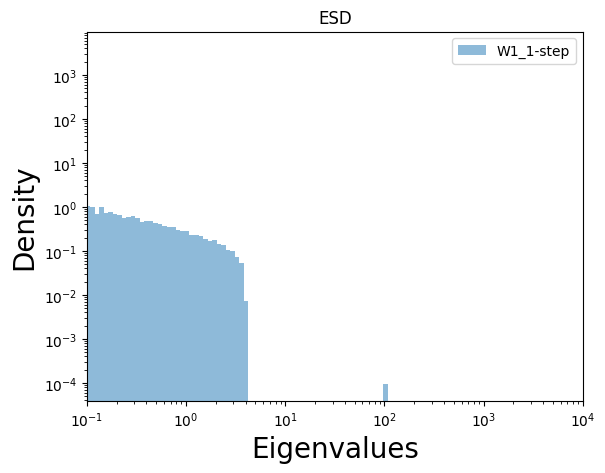

[1.04176306e+03 6.12962036e+02 3.94405818e+00 3.90637898e+00
 3.90154743e+00 3.83655405e+00 3.79823112e+00 3.78770757e+00
 3.76200914e+00 3.74385500e+00 3.72686768e+00 3.68986297e+00
 3.67546415e+00 3.66437054e+00 3.62136817e+00 3.58631492e+00
 3.57093000e+00 3.55031681e+00 3.53676820e+00 3.51670909e+00
 3.48762178e+00 3.47272992e+00 3.45715976e+00 3.43711066e+00
 3.43110371e+00 3.41197729e+00 3.40601730e+00 3.38778806e+00
 3.37090158e+00 3.35442090e+00 3.35193062e+00 3.33605409e+00
 3.30227637e+00 3.29732466e+00 3.28516030e+00 3.26195288e+00
 3.24503684e+00 3.22790384e+00 3.22530746e+00 3.21029305e+00
 3.20107007e+00 3.19314909e+00 3.18669295e+00 3.16302824e+00
 3.15714836e+00 3.15045762e+00 3.14078593e+00 3.12752151e+00
 3.10619044e+00 3.09644866e+00 3.08805704e+00 3.07877326e+00
 3.05956030e+00 3.05343342e+00 3.03866434e+00 3.03500915e+00
 3.02255058e+00 3.01753116e+00 3.01047158e+00 2.98753095e+00
 2.98160625e+00 2.97717667e+00 2.96533704e+00 2.95201087e+00
 2.93831801e+00 2.927743

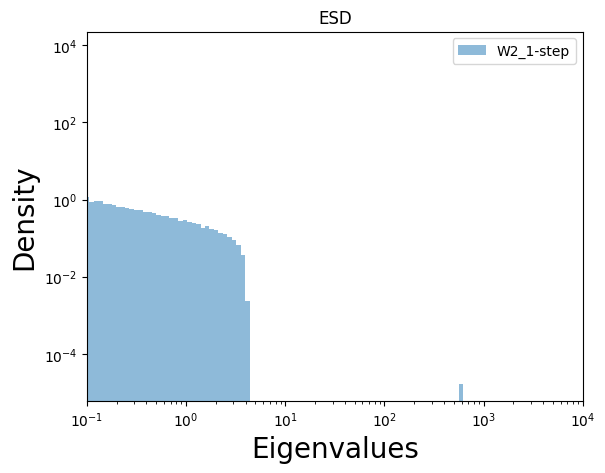

In [94]:
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
rho = 0
test_size = 500

x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)
u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 100,1000
lr1=500
lr2=500

I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi

W1_true = W1 - lr1/(n*h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1/(n*np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2/(n*h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2/(n*np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[1.07757483e+03 5.34736938e+02 6.91111908e+01 6.62186584e+01
 6.37741737e+01 6.08272743e+01 5.90081406e+01 5.81630859e+01
 5.76671104e+01 5.61817245e+01 5.53197670e+01 5.37296638e+01
 5.33636169e+01 5.27319260e+01 5.15461159e+01 4.95269127e+01
 4.89076347e+01 4.85653267e+01 4.82676544e+01 4.74894371e+01
 4.65704460e+01 4.59856262e+01 4.49720039e+01 4.45464630e+01
 4.39227142e+01 4.32415047e+01 4.31052094e+01 4.27431679e+01
 4.24365730e+01 4.15408821e+01 4.03865509e+01 4.01008987e+01
 3.98560448e+01 3.91698418e+01 3.88435287e+01 3.81973534e+01
 3.79436340e+01 3.75819855e+01 3.71663055e+01 3.64177399e+01
 3.62328644e+01 3.54192162e+01 3.50889778e+01 3.42477112e+01
 3.39730721e+01 3.35627899e+01 3.33246078e+01 3.26251488e+01
 3.23746567e+01 3.22475281e+01 3.17121048e+01 3.13174286e+01
 3.11757488e+01 3.10279617e+01 3.08462696e+01 3.00376797e+01
 2.97760239e+01 2.94483280e+01 2.91490040e+01 2.90466461e+01
 2.85503826e+01 2.83392887e+01 2.77587452e+01 2.75739994e+01
 2.73338642e+01 2.708530

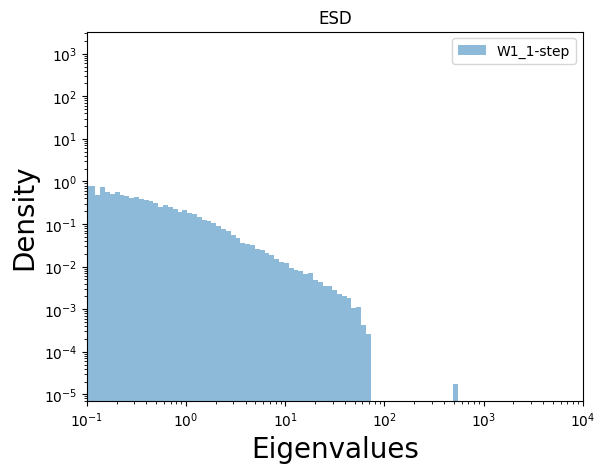

[9.67016602e+03 1.04142853e+02 6.61925735e+01 6.36496735e+01
 6.19944038e+01 6.11155777e+01 6.10488434e+01 5.92351418e+01
 5.89523964e+01 5.78217468e+01 5.62850189e+01 5.46180992e+01
 5.27113724e+01 5.15563354e+01 5.09296227e+01 5.06782036e+01
 4.98266296e+01 4.89431419e+01 4.83979187e+01 4.64223213e+01
 4.62237511e+01 4.60027313e+01 4.52044601e+01 4.48123817e+01
 4.38886719e+01 4.26408386e+01 4.23903503e+01 4.19024086e+01
 4.17834702e+01 4.11480827e+01 4.04672279e+01 4.00850945e+01
 3.96161499e+01 3.94005432e+01 3.90530128e+01 3.86482430e+01
 3.79435616e+01 3.77294159e+01 3.72270622e+01 3.65055695e+01
 3.58478203e+01 3.55380745e+01 3.46710587e+01 3.45867424e+01
 3.43891296e+01 3.40574875e+01 3.34252281e+01 3.30567055e+01
 3.26187439e+01 3.23032951e+01 3.19710636e+01 3.12707691e+01
 3.10165520e+01 3.05494518e+01 3.01035748e+01 3.00513058e+01
 2.96610107e+01 2.95689087e+01 2.93843975e+01 2.89145336e+01
 2.83658810e+01 2.82072906e+01 2.75238438e+01 2.72971764e+01
 2.71700611e+01 2.701307

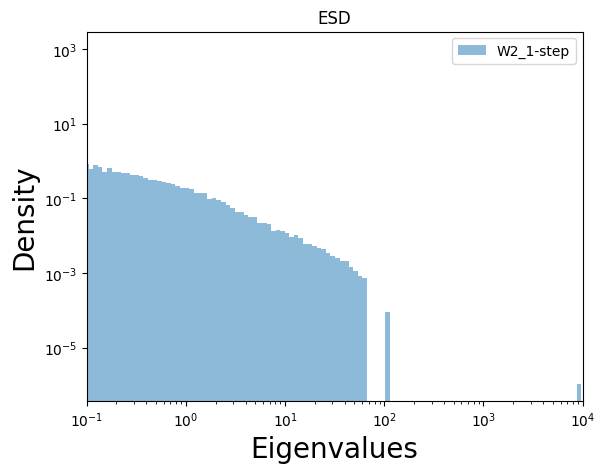

In [1]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000, 100

I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi

lr1=50
lr2=50

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[1.00602765e+03 3.90829086e+00 3.90619731e+00 3.89270020e+00
 3.84340882e+00 3.78981495e+00 3.78619909e+00 3.74499726e+00
 3.72585225e+00 3.71084023e+00 3.68577266e+00 3.66654825e+00
 3.64588523e+00 3.61263776e+00 3.58673024e+00 3.57271814e+00
 3.56572962e+00 3.56067562e+00 3.53862643e+00 3.52360129e+00
 3.51023817e+00 3.49005651e+00 3.47958064e+00 3.44740272e+00
 3.43858838e+00 3.41198802e+00 3.39917207e+00 3.37611485e+00
 3.36305618e+00 3.35175657e+00 3.33775902e+00 3.31991744e+00
 3.30418968e+00 3.29676962e+00 3.28241801e+00 3.26091719e+00
 3.25716925e+00 3.23109078e+00 3.22758150e+00 3.21721220e+00
 3.20135617e+00 3.18974090e+00 3.17979598e+00 3.17945170e+00
 3.15886188e+00 3.15293741e+00 3.13570333e+00 3.12638211e+00
 3.10532355e+00 3.09119558e+00 3.08392644e+00 3.08039975e+00
 3.07118654e+00 3.05266929e+00 3.03809285e+00 3.03095651e+00
 3.01677012e+00 3.01492882e+00 2.99589229e+00 2.98569441e+00
 2.97090673e+00 2.96101379e+00 2.95546508e+00 2.94815350e+00
 2.93136096e+00 2.919398

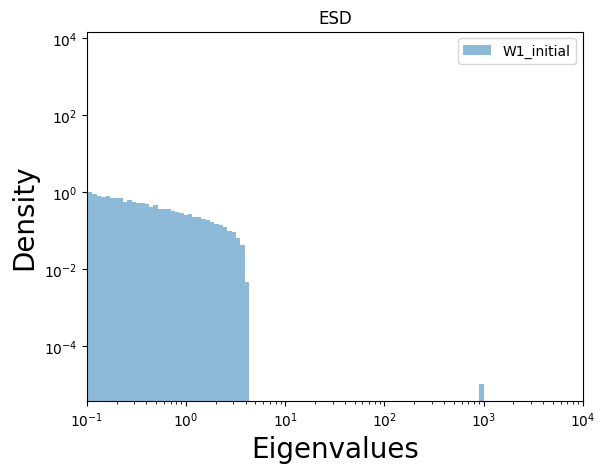

[1.06274094e+02 3.99003124e+00 3.90767717e+00 3.88125420e+00
 3.82864189e+00 3.80011940e+00 3.74076581e+00 3.73181844e+00
 3.72775054e+00 3.71885347e+00 3.70402527e+00 3.67781568e+00
 3.64525747e+00 3.61706877e+00 3.60978484e+00 3.58075404e+00
 3.56727099e+00 3.54573798e+00 3.52195573e+00 3.49709320e+00
 3.46663809e+00 3.46394539e+00 3.44663167e+00 3.42452836e+00
 3.41564417e+00 3.39020157e+00 3.38271904e+00 3.37296295e+00
 3.35795879e+00 3.34992456e+00 3.33795047e+00 3.31587982e+00
 3.30801892e+00 3.28721929e+00 3.27993941e+00 3.27278495e+00
 3.24729490e+00 3.24019933e+00 3.23013115e+00 3.21347070e+00
 3.20504713e+00 3.19489670e+00 3.19331670e+00 3.17092228e+00
 3.16161299e+00 3.14814210e+00 3.13514256e+00 3.12893581e+00
 3.12850618e+00 3.09553337e+00 3.08489180e+00 3.08457255e+00
 3.06103826e+00 3.04550338e+00 3.04013252e+00 3.03120112e+00
 3.01630473e+00 3.01108384e+00 2.99583411e+00 2.98873997e+00
 2.97000647e+00 2.95284390e+00 2.94292593e+00 2.93133163e+00
 2.91973400e+00 2.915791

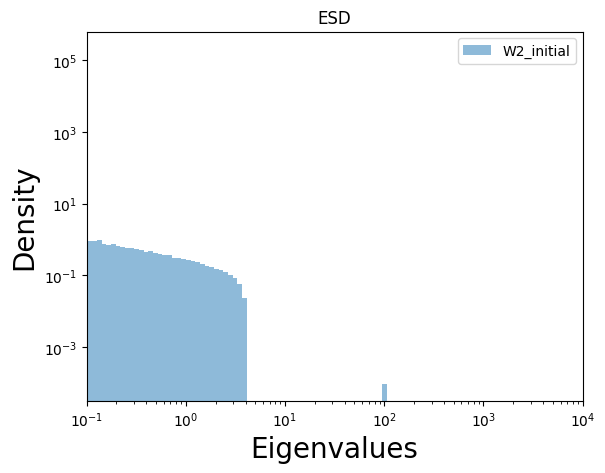

In [4]:
## visualize ESD
## rank-1-nonrandom-setup
## 3-layer
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000

W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)

y = X @ beta + xi

A_1=-(1/(n*np.sqrt(h)))*X.T@y@a.T@W2_.T
A_2=-(1/(n*np.sqrt(h)))*W1_.T@X.T@y@a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)

#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u1 = torch.normal(mean=0, std=1, size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000,100
I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

print_esd(W1,"W1_initial")
print_esd(W2,"W2_initial")


[9.44021484e+02 5.66573853e+02 3.95660186e+00 3.88486266e+00
 3.86536384e+00 3.82055235e+00 3.80646563e+00 3.79165864e+00
 3.75809097e+00 3.72345591e+00 3.70084810e+00 3.67915678e+00
 3.65096211e+00 3.63629603e+00 3.60370135e+00 3.58528590e+00
 3.57757139e+00 3.55870628e+00 3.54872274e+00 3.53919673e+00
 3.51565027e+00 3.49839759e+00 3.47921777e+00 3.45782328e+00
 3.45228267e+00 3.43084383e+00 3.42843342e+00 3.40003896e+00
 3.38994813e+00 3.37455082e+00 3.35804844e+00 3.34253216e+00
 3.32003498e+00 3.30899477e+00 3.29289365e+00 3.28594995e+00
 3.26556969e+00 3.24978900e+00 3.22600031e+00 3.22205448e+00
 3.21216178e+00 3.19874167e+00 3.19398570e+00 3.18302751e+00
 3.16443014e+00 3.15552759e+00 3.14478922e+00 3.14166856e+00
 3.13007116e+00 3.11469555e+00 3.10545516e+00 3.09949541e+00
 3.07346344e+00 3.06649470e+00 3.05412436e+00 3.04481649e+00
 3.02826309e+00 3.01926827e+00 3.00473261e+00 2.99309635e+00
 2.97725439e+00 2.97054911e+00 2.95718670e+00 2.94600987e+00
 2.93361211e+00 2.930744

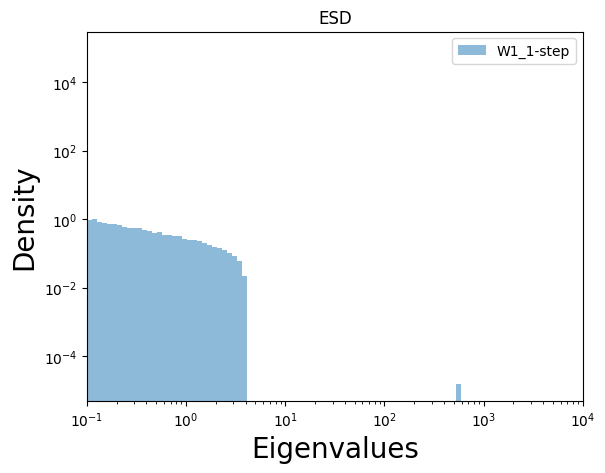

[1.05333847e+02 3.99617529e+00 3.90340686e+00 3.84977627e+00
 3.84080338e+00 3.81081939e+00 3.74645591e+00 3.73786020e+00
 3.72449994e+00 3.70181894e+00 3.68681717e+00 3.67535925e+00
 3.65333676e+00 3.62140298e+00 3.60734034e+00 3.58290434e+00
 3.56574082e+00 3.55967617e+00 3.55790091e+00 3.53516412e+00
 3.51446748e+00 3.50345659e+00 3.46217203e+00 3.44638228e+00
 3.43937802e+00 3.41895223e+00 3.41031623e+00 3.39508200e+00
 3.36798525e+00 3.35341597e+00 3.34220839e+00 3.33505034e+00
 3.30938721e+00 3.29932523e+00 3.27816129e+00 3.27725506e+00
 3.25145340e+00 3.24266934e+00 3.22206616e+00 3.21777844e+00
 3.20759916e+00 3.18294740e+00 3.17485452e+00 3.17158628e+00
 3.16573644e+00 3.14956117e+00 3.13972402e+00 3.13358998e+00
 3.12479424e+00 3.10284185e+00 3.09184170e+00 3.07638431e+00
 3.07206225e+00 3.06437707e+00 3.05618048e+00 3.03857088e+00
 3.03094411e+00 3.01351738e+00 3.00686550e+00 2.99882841e+00
 2.98484135e+00 2.97852898e+00 2.96532011e+00 2.94529724e+00
 2.94409800e+00 2.931952

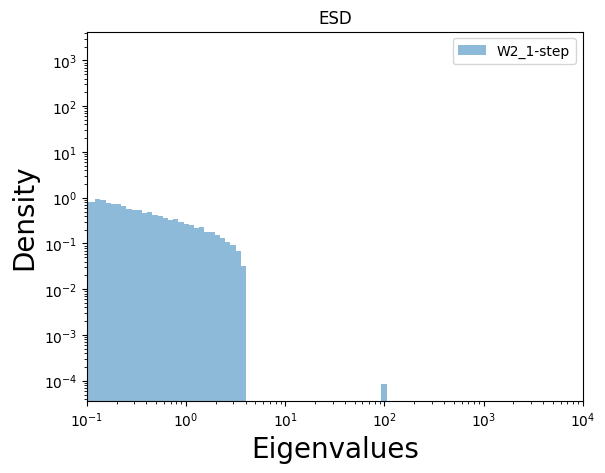

In [9]:
## visualize ESD
## rank-1-nonrandom-setup
## 3-layer
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
rho = 0
test_size = 500
W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)

y = X @ beta + xi

A_1=-(1/(n*np.sqrt(h)))*X.T@y@a.T@W2_.T
A_2=-(1/(n*np.sqrt(h)))*W1_.T@X.T@y@a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)

#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u1 = torch.normal(mean=0, std=1, size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000,100
I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)
y = X @ beta + xi

lr1=500
lr2=5

W1_true = W1 - lr1/(n*h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1/(n*np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2/(n*h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2/(n*np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[9.44754272e+02 5.94847656e+02 6.82518234e+01 6.73538208e+01
 6.42872467e+01 6.21349945e+01 6.04580612e+01 5.77781334e+01
 5.71552963e+01 5.61408577e+01 5.52009087e+01 5.43346634e+01
 5.38862686e+01 5.24194832e+01 5.08067818e+01 4.98882179e+01
 4.93081665e+01 4.87454453e+01 4.80432930e+01 4.67133484e+01
 4.63303642e+01 4.47835426e+01 4.46057739e+01 4.37254333e+01
 4.31626587e+01 4.18224792e+01 4.16532707e+01 4.13679771e+01
 4.08248978e+01 4.07494888e+01 3.99227753e+01 3.95650520e+01
 3.90721741e+01 3.85056076e+01 3.76232758e+01 3.73663826e+01
 3.70905342e+01 3.69534340e+01 3.65897789e+01 3.62604713e+01
 3.54605064e+01 3.50945168e+01 3.50442886e+01 3.48633194e+01
 3.43351440e+01 3.42264214e+01 3.38209534e+01 3.30740433e+01
 3.22596779e+01 3.19684620e+01 3.16430817e+01 3.15039425e+01
 3.13492928e+01 3.11038113e+01 3.09680939e+01 3.06006470e+01
 2.99359951e+01 2.96916580e+01 2.91589603e+01 2.86362724e+01
 2.85882015e+01 2.81359291e+01 2.79142742e+01 2.75629253e+01
 2.74084511e+01 2.711162

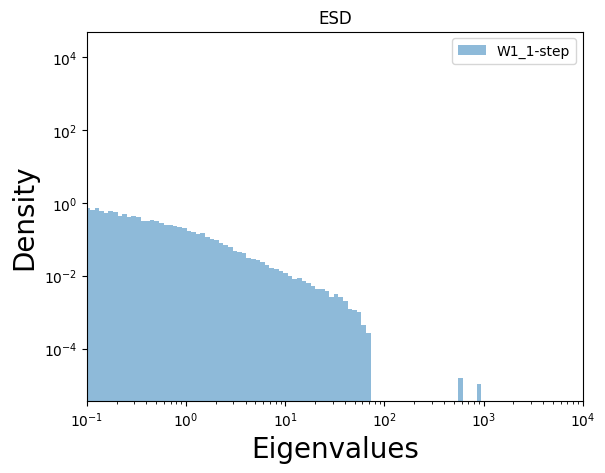

[1.04367645e+02 7.44657822e+01 4.15225363e+00 4.10051537e+00
 4.02854443e+00 4.00694180e+00 3.97467995e+00 3.96647120e+00
 3.94410896e+00 3.92337799e+00 3.88986135e+00 3.86498547e+00
 3.81518459e+00 3.79282498e+00 3.77419734e+00 3.76531219e+00
 3.74480271e+00 3.73184562e+00 3.71282029e+00 3.69621420e+00
 3.65665841e+00 3.64341259e+00 3.62447357e+00 3.61484551e+00
 3.60543799e+00 3.58861899e+00 3.57072067e+00 3.56423831e+00
 3.53998995e+00 3.51818991e+00 3.51045275e+00 3.49410820e+00
 3.48902893e+00 3.47023630e+00 3.46664143e+00 3.45175743e+00
 3.41632557e+00 3.40856934e+00 3.40188336e+00 3.38854384e+00
 3.37307739e+00 3.36674738e+00 3.34193540e+00 3.32899523e+00
 3.30979538e+00 3.30092406e+00 3.26993585e+00 3.26237965e+00
 3.25353861e+00 3.24017668e+00 3.22811055e+00 3.21984601e+00
 3.20397425e+00 3.19651175e+00 3.18065214e+00 3.17595291e+00
 3.15388131e+00 3.14874983e+00 3.12940645e+00 3.11689162e+00
 3.10590863e+00 3.09256959e+00 3.08272243e+00 3.07969236e+00
 3.05998468e+00 3.053825

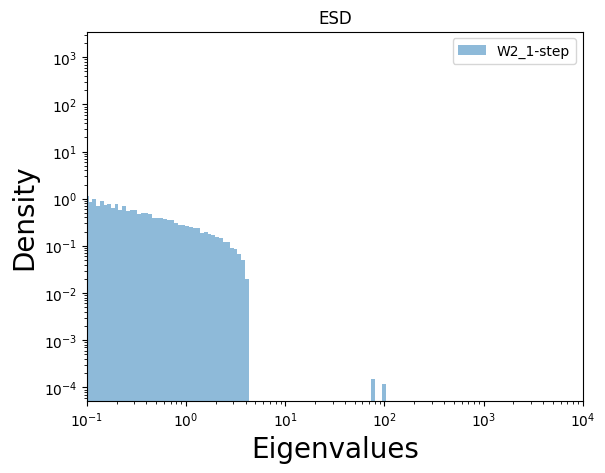

In [10]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)

A_1=-(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=-(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)

#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 1000, 100

I1 = torch.eye(d, device=device)
Sigma1 = I1 + la1 * (u1 @ u1.T)
I2 = torch.eye(h, device=device)
Sigma2 = I2 + la2 * (u2 @ u2.T)
L1 = torch.linalg.cholesky(Sigma1)
Z1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W1 = L1 @ Z1
L2 = torch.linalg.cholesky(Sigma2)
Z2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
W2 = L2 @ Z2

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi

lr1=50
lr2=5

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[4.03634247e+02 3.93008852e+00 3.89661002e+00 3.88375974e+00
 3.83562350e+00 3.81337738e+00 3.75116014e+00 3.74235201e+00
 3.70674753e+00 3.67130089e+00 3.66060019e+00 3.64698291e+00
 3.61097026e+00 3.59300518e+00 3.58390284e+00 3.56649566e+00
 3.55501080e+00 3.54053593e+00 3.52505851e+00 3.50468373e+00
 3.49767184e+00 3.47534728e+00 3.44630122e+00 3.43404412e+00
 3.42832923e+00 3.40732193e+00 3.38037133e+00 3.37099075e+00
 3.36715770e+00 3.33771491e+00 3.32331848e+00 3.31835151e+00
 3.30119848e+00 3.29532862e+00 3.28936577e+00 3.27805519e+00
 3.25729728e+00 3.23438954e+00 3.23235917e+00 3.21248603e+00
 3.18175864e+00 3.17455792e+00 3.16433883e+00 3.16001749e+00
 3.13550615e+00 3.12746954e+00 3.12112236e+00 3.11137772e+00
 3.10170937e+00 3.08660579e+00 3.08233619e+00 3.06181049e+00
 3.05858302e+00 3.04176044e+00 3.03384519e+00 3.02028084e+00
 3.00531173e+00 2.99245143e+00 2.98849964e+00 2.97825193e+00
 2.96197391e+00 2.95279288e+00 2.94894218e+00 2.93464208e+00
 2.92213655e+00 2.919769

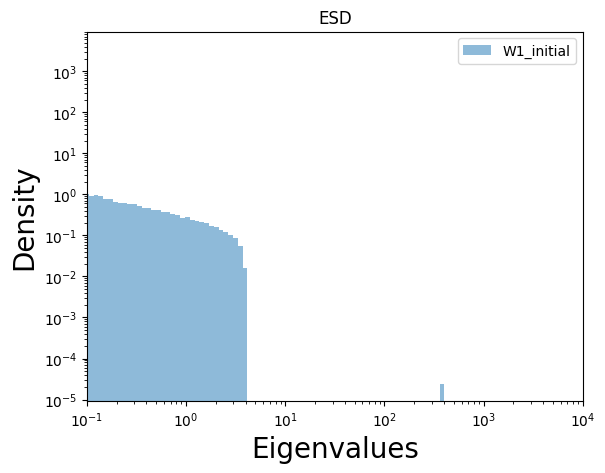

[6.40268707e+00 3.95257044e+00 3.88190222e+00 3.86319184e+00
 3.85664392e+00 3.83585191e+00 3.82984567e+00 3.77194619e+00
 3.76650691e+00 3.72928333e+00 3.69615293e+00 3.67344594e+00
 3.65725040e+00 3.63638854e+00 3.63557625e+00 3.61020780e+00
 3.60556555e+00 3.57651424e+00 3.56940007e+00 3.54148293e+00
 3.51312447e+00 3.50930595e+00 3.47150779e+00 3.46866465e+00
 3.45645642e+00 3.43237090e+00 3.41832137e+00 3.40515614e+00
 3.38711977e+00 3.36124897e+00 3.35007954e+00 3.34472561e+00
 3.34426641e+00 3.31261849e+00 3.29839659e+00 3.28864050e+00
 3.27748919e+00 3.25897622e+00 3.25331306e+00 3.23674989e+00
 3.20921302e+00 3.20692992e+00 3.18024802e+00 3.17272973e+00
 3.16358948e+00 3.15395784e+00 3.14205813e+00 3.11749864e+00
 3.10899901e+00 3.10065413e+00 3.09573126e+00 3.08630681e+00
 3.06380248e+00 3.05703974e+00 3.04444504e+00 3.02962017e+00
 3.02468657e+00 3.01018906e+00 2.99936581e+00 2.99318242e+00
 2.97810268e+00 2.97054911e+00 2.95485616e+00 2.95171714e+00
 2.94017196e+00 2.935859

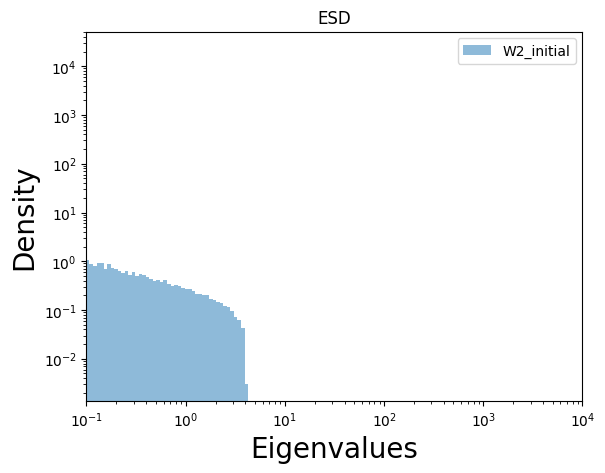

In [3]:
##special initial
## visualize ESD
## rank-1-nonrandom-setup
## 3-layer
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d = 1000
h = 1000
n = 1000
rho=0

W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)
X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, 1), device=device)
a = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)

beta = torch.randn(size=[d], device=device)
beta = beta / torch.norm(beta, p=2)
beta = beta.unsqueeze(1)

y = X @ beta + xi

A_1=-(1/(n*np.sqrt(h)))*X.T@y@a.T@W2_.T
A_2=-(1/(n*np.sqrt(h)))*W1_.T@X.T@y@a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,2
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)

print_esd(W1,"W1_initial")
print_esd(W2,"W2_initial")


[4.01506165e+02 3.94995356e+00 3.89489937e+00 3.86205316e+00
 3.84503651e+00 3.82103300e+00 3.78830385e+00 3.76141691e+00
 3.70983171e+00 3.68204856e+00 3.66655135e+00 3.64875960e+00
 3.63175011e+00 3.61730933e+00 3.60164356e+00 3.58528423e+00
 3.55673361e+00 3.54939485e+00 3.52076721e+00 3.50210452e+00
 3.48653579e+00 3.47420526e+00 3.44844961e+00 3.44197035e+00
 3.41646171e+00 3.39891386e+00 3.39445448e+00 3.37469745e+00
 3.35890031e+00 3.35153794e+00 3.32605815e+00 3.31677055e+00
 3.30764270e+00 3.28423119e+00 3.28326225e+00 3.27095389e+00
 3.24200821e+00 3.23745465e+00 3.22253275e+00 3.21358538e+00
 3.20802426e+00 3.19032240e+00 3.17458367e+00 3.16240311e+00
 3.15757489e+00 3.14534020e+00 3.13268828e+00 3.12117290e+00
 3.11473083e+00 3.10304880e+00 3.09049678e+00 3.07857394e+00
 3.07121277e+00 3.05224180e+00 3.04970932e+00 3.03304029e+00
 3.02398372e+00 3.02144623e+00 3.00313759e+00 2.99594975e+00
 2.98510456e+00 2.96922421e+00 2.94718957e+00 2.93906140e+00
 2.92711854e+00 2.917184

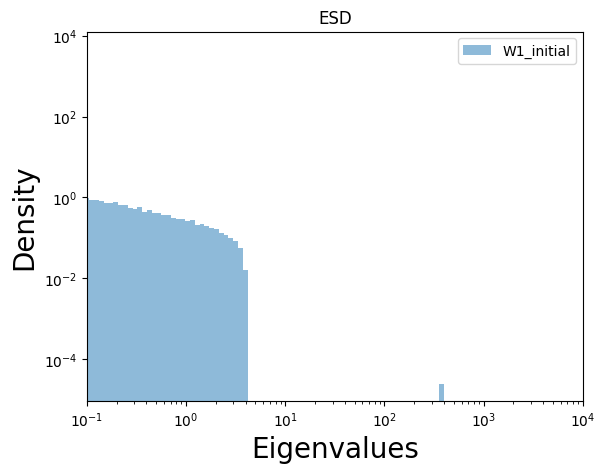

[4.01422691e+00 3.95103931e+00 3.88741231e+00 3.87074423e+00
 3.84439564e+00 3.80705786e+00 3.77048349e+00 3.74544907e+00
 3.70565963e+00 3.66941929e+00 3.65468931e+00 3.64513636e+00
 3.63092685e+00 3.61701870e+00 3.60779238e+00 3.56948447e+00
 3.55984879e+00 3.55184531e+00 3.52777719e+00 3.51794577e+00
 3.50579166e+00 3.48259735e+00 3.46997929e+00 3.45708251e+00
 3.44738507e+00 3.43516827e+00 3.40189528e+00 3.39657187e+00
 3.39261603e+00 3.37682819e+00 3.36296892e+00 3.35064936e+00
 3.31806636e+00 3.30196810e+00 3.28819227e+00 3.27807951e+00
 3.25435853e+00 3.24982905e+00 3.23468018e+00 3.23049426e+00
 3.20847487e+00 3.19322395e+00 3.18438840e+00 3.17566204e+00
 3.16937423e+00 3.15395212e+00 3.15148091e+00 3.12621188e+00
 3.11948538e+00 3.11293983e+00 3.09055972e+00 3.08082318e+00
 3.07235360e+00 3.05491948e+00 3.04229617e+00 3.03209710e+00
 3.02158713e+00 2.99644685e+00 2.99292326e+00 2.97664046e+00
 2.97329783e+00 2.96475577e+00 2.95060015e+00 2.94191813e+00
 2.93673921e+00 2.923504

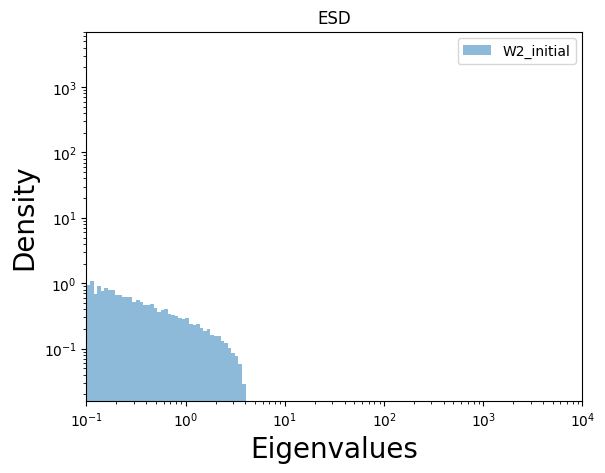

In [13]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)

A_1=-(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=-(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)


print_esd(W1, 'W1_initial')
print_esd(W2,'W2_initial')


[3.28601624e+02 6.85908127e+01 6.48883514e+01 6.32924500e+01
 6.19581032e+01 6.00304832e+01 5.93535385e+01 5.80439262e+01
 5.72681465e+01 5.55891075e+01 5.45397377e+01 5.40177460e+01
 5.23438759e+01 5.15563965e+01 5.08423576e+01 4.98619118e+01
 4.86828079e+01 4.83558235e+01 4.71597939e+01 4.62809868e+01
 4.58192482e+01 4.48067207e+01 4.46241150e+01 4.39825249e+01
 4.35039940e+01 4.34741135e+01 4.28116035e+01 4.13676682e+01
 4.05448456e+01 4.03699570e+01 3.95972099e+01 3.94638023e+01
 3.85264130e+01 3.80941849e+01 3.76957169e+01 3.74475670e+01
 3.67539787e+01 3.66343269e+01 3.64096413e+01 3.60447617e+01
 3.51867027e+01 3.46688461e+01 3.43885841e+01 3.42054672e+01
 3.35281982e+01 3.34025955e+01 3.29795685e+01 3.27226639e+01
 3.26142769e+01 3.22357788e+01 3.16239643e+01 3.12183437e+01
 3.10380154e+01 3.06233749e+01 3.02310085e+01 2.99310741e+01
 2.96953163e+01 2.92216778e+01 2.91273613e+01 2.89989929e+01
 2.85430050e+01 2.83355885e+01 2.79872513e+01 2.77501221e+01
 2.72105999e+01 2.689310

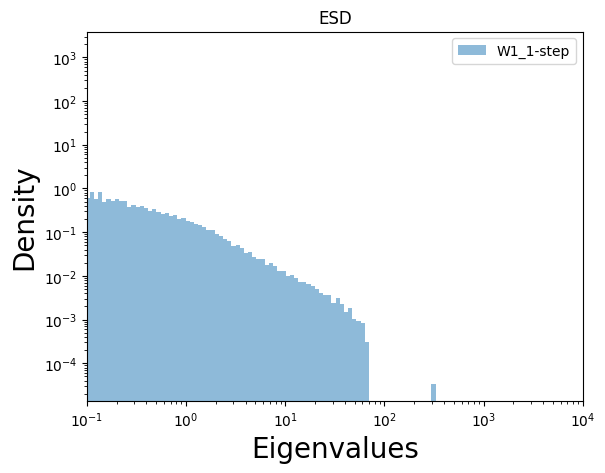

[1.14119614e+02 5.40783596e+00 5.26084661e+00 5.19899082e+00
 5.18036652e+00 5.04391050e+00 4.95250702e+00 4.90811062e+00
 4.82635689e+00 4.80163622e+00 4.77076435e+00 4.71269751e+00
 4.69566154e+00 4.65295935e+00 4.60047293e+00 4.57134771e+00
 4.55575275e+00 4.50329590e+00 4.49408245e+00 4.48070097e+00
 4.43999863e+00 4.40685177e+00 4.38487101e+00 4.34835148e+00
 4.31541634e+00 4.31056643e+00 4.26666594e+00 4.25367928e+00
 4.22631979e+00 4.20927048e+00 4.17791700e+00 4.15792656e+00
 4.15054560e+00 4.10440254e+00 4.08447504e+00 4.06616879e+00
 4.05730295e+00 4.03203630e+00 4.02468395e+00 4.00968504e+00
 3.98648357e+00 3.98054123e+00 3.94614005e+00 3.92722678e+00
 3.92046046e+00 3.90727782e+00 3.87500548e+00 3.86065054e+00
 3.83654881e+00 3.82720923e+00 3.81175709e+00 3.78508258e+00
 3.77665257e+00 3.75024056e+00 3.72589707e+00 3.71826458e+00
 3.69019818e+00 3.66956282e+00 3.64443159e+00 3.62452078e+00
 3.61211157e+00 3.60803413e+00 3.59373450e+00 3.56702638e+00
 3.56064558e+00 3.545308

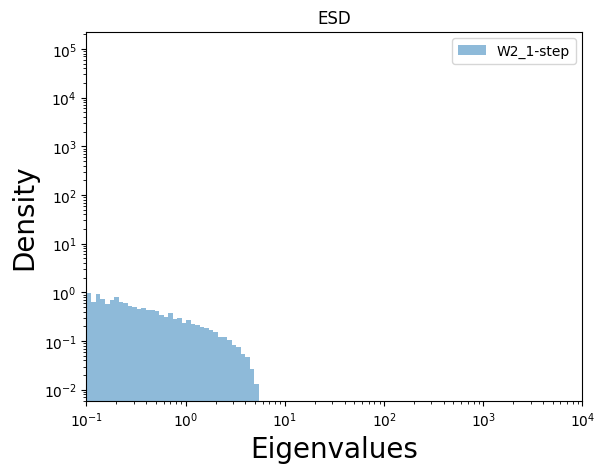

In [15]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)

A_1=-(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=-(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)

#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)



X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
y = X @ beta + xi

lr1=10
lr2=50

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')


[4.03411835e+02 3.96330690e+00 3.92402339e+00 3.89192128e+00
 3.87466240e+00 3.81699276e+00 3.77584124e+00 3.75626850e+00
 3.72024107e+00 3.70265102e+00 3.69377184e+00 3.66436553e+00
 3.65710068e+00 3.64952993e+00 3.64084339e+00 3.60277581e+00
 3.58603811e+00 3.55837321e+00 3.53615141e+00 3.52867413e+00
 3.50960255e+00 3.48765874e+00 3.48033047e+00 3.47400403e+00
 3.42494607e+00 3.41797638e+00 3.41176796e+00 3.40056372e+00
 3.39777827e+00 3.35772133e+00 3.35155869e+00 3.33672976e+00
 3.32488108e+00 3.31744099e+00 3.29492712e+00 3.27021527e+00
 3.25670052e+00 3.24184966e+00 3.23246980e+00 3.22966814e+00
 3.19927740e+00 3.19031525e+00 3.17569637e+00 3.16500902e+00
 3.15654087e+00 3.15336156e+00 3.13660312e+00 3.12484598e+00
 3.11870337e+00 3.11606979e+00 3.10025191e+00 3.09188962e+00
 3.06236291e+00 3.05938292e+00 3.04759073e+00 3.04033065e+00
 3.02971292e+00 3.01586795e+00 3.01191163e+00 2.99853039e+00
 2.99115086e+00 2.97788978e+00 2.96929717e+00 2.95652628e+00
 2.93588948e+00 2.921391

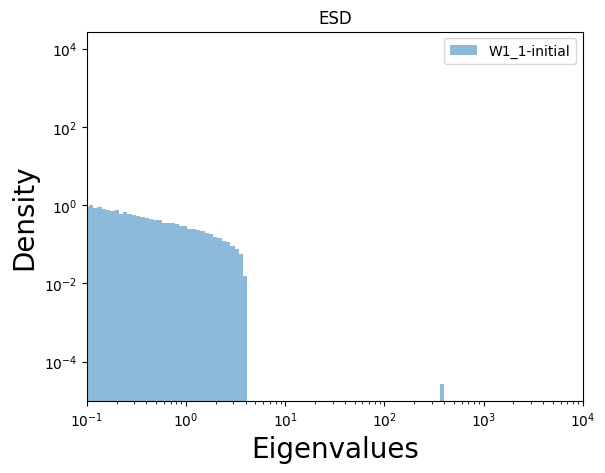

[3.97828436e+00 3.93754816e+00 3.87641191e+00 3.84580302e+00
 3.80518365e+00 3.79706860e+00 3.77004814e+00 3.74694562e+00
 3.71595216e+00 3.70804596e+00 3.68334174e+00 3.67374516e+00
 3.65091991e+00 3.62872863e+00 3.61072326e+00 3.57539654e+00
 3.55225539e+00 3.54164791e+00 3.52042627e+00 3.50891805e+00
 3.49007082e+00 3.47895813e+00 3.46786594e+00 3.45052791e+00
 3.44141054e+00 3.42862248e+00 3.39305711e+00 3.38423920e+00
 3.37817883e+00 3.35405040e+00 3.33073282e+00 3.32126164e+00
 3.31792593e+00 3.31624055e+00 3.30738473e+00 3.28815937e+00
 3.26845479e+00 3.24466753e+00 3.23187351e+00 3.20538259e+00
 3.19890356e+00 3.18411970e+00 3.17179966e+00 3.16746402e+00
 3.15517712e+00 3.14755511e+00 3.12926006e+00 3.11969519e+00
 3.10733676e+00 3.09649324e+00 3.08624840e+00 3.06738901e+00
 3.06024265e+00 3.04900026e+00 3.03491831e+00 3.03123236e+00
 3.00625229e+00 3.00105500e+00 2.99279428e+00 2.98350787e+00
 2.98095727e+00 2.97071123e+00 2.95341516e+00 2.94635892e+00
 2.93531251e+00 2.923011

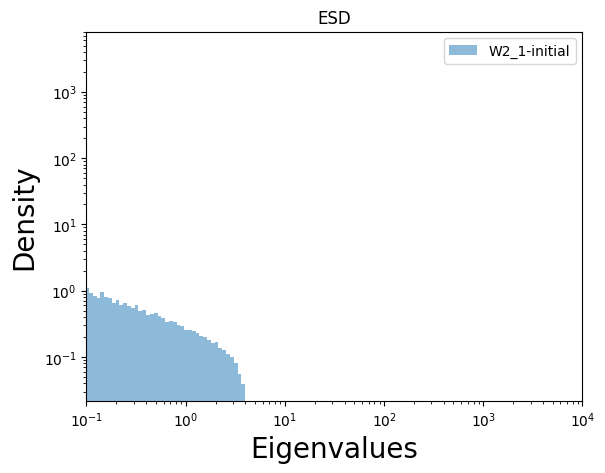

In [1]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v  
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)


A_1=(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)


X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
#beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v 
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 

y = X @ beta + xi

lr1=0
lr2=0

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

#print_esd(W1_true, 'W1_1-step')
#print_esd(W2_true,'W2_1-step')
print_esd(W1_true, 'W1_1-initial')
print_esd(W2_true,'W2_1-initial')


[3.38505005e+03 3.40804596e+02 3.69245672e+00 3.65178275e+00
 3.61252975e+00 3.59915614e+00 3.59110522e+00 3.57354021e+00
 3.52376962e+00 3.52088809e+00 3.46957850e+00 3.44893193e+00
 3.41197085e+00 3.37808013e+00 3.36176205e+00 3.35949922e+00
 3.33996153e+00 3.32988739e+00 3.31783772e+00 3.28454828e+00
 3.28193235e+00 3.27220321e+00 3.24678159e+00 3.23555541e+00
 3.23141432e+00 3.20240068e+00 3.19368696e+00 3.18092871e+00
 3.15637875e+00 3.14229560e+00 3.13038731e+00 3.11903024e+00
 3.10349584e+00 3.10008526e+00 3.08283305e+00 3.07671928e+00
 3.05621266e+00 3.04647613e+00 3.03619647e+00 3.02974129e+00
 3.01796269e+00 2.99708200e+00 2.98388410e+00 2.96002150e+00
 2.95479298e+00 2.95129275e+00 2.94280839e+00 2.93874550e+00
 2.92547989e+00 2.91263556e+00 2.88616037e+00 2.87665343e+00
 2.86819506e+00 2.85649800e+00 2.84956217e+00 2.83565736e+00
 2.82815480e+00 2.80913997e+00 2.80303049e+00 2.78982377e+00
 2.78138232e+00 2.77566171e+00 2.77373338e+00 2.75704503e+00
 2.73745871e+00 2.722389

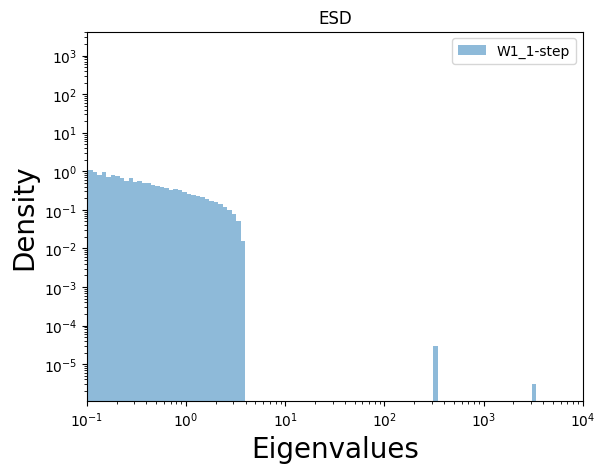

[3.96471858e+00 3.86178756e+00 3.84573746e+00 3.81316447e+00
 3.79128599e+00 3.76497960e+00 3.74213481e+00 3.73379326e+00
 3.69512582e+00 3.67696476e+00 3.66777349e+00 3.65452051e+00
 3.62813568e+00 3.61169910e+00 3.58772707e+00 3.58034897e+00
 3.56602716e+00 3.54167747e+00 3.52595091e+00 3.51599741e+00
 3.49953532e+00 3.48210311e+00 3.47926784e+00 3.45709181e+00
 3.42562413e+00 3.40859222e+00 3.39749908e+00 3.37399840e+00
 3.35475159e+00 3.34164596e+00 3.32630491e+00 3.32136369e+00
 3.30683637e+00 3.28308153e+00 3.27463460e+00 3.25973678e+00
 3.25617337e+00 3.24445486e+00 3.23195076e+00 3.20966673e+00
 3.20648837e+00 3.19966912e+00 3.18219256e+00 3.17819929e+00
 3.16420770e+00 3.14803004e+00 3.13716602e+00 3.12246895e+00
 3.11409235e+00 3.10109115e+00 3.09991121e+00 3.08795881e+00
 3.07875061e+00 3.06736588e+00 3.05070734e+00 3.04392028e+00
 3.02816844e+00 3.02180076e+00 3.01034355e+00 2.99383235e+00
 2.98262501e+00 2.96990013e+00 2.96448159e+00 2.95416212e+00
 2.95103049e+00 2.935889

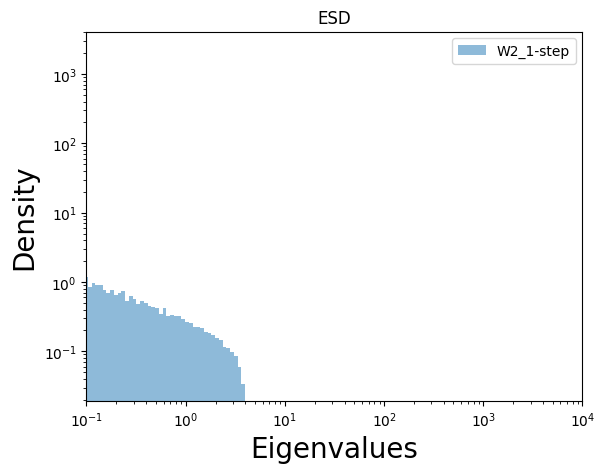

In [2]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v  
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)


A_1=(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)


X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
#beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v 
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 

y = X @ beta + xi

lr1=40
lr2=0

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')
#print_esd(W1_true, 'W1_1-initial')
#print_esd(W2_true,'W2_1-initial')


[1.74911865e+03 3.56288818e+02 3.72053552e+00 3.68040228e+00
 3.67496443e+00 3.64383602e+00 3.61866665e+00 3.58730865e+00
 3.56113148e+00 3.51660728e+00 3.50501180e+00 3.49993587e+00
 3.48026371e+00 3.44042659e+00 3.40779305e+00 3.40584803e+00
 3.38411450e+00 3.37147427e+00 3.35687709e+00 3.33880877e+00
 3.32623577e+00 3.30761027e+00 3.29150581e+00 3.28453422e+00
 3.26910210e+00 3.24344945e+00 3.24222207e+00 3.23304677e+00
 3.22905231e+00 3.19763708e+00 3.17853951e+00 3.16215110e+00
 3.15310740e+00 3.14124703e+00 3.12269735e+00 3.11021304e+00
 3.09401202e+00 3.08853292e+00 3.06484604e+00 3.05850673e+00
 3.04747701e+00 3.03571582e+00 3.02151299e+00 3.01323080e+00
 3.00448012e+00 2.99224138e+00 2.98728800e+00 2.97711515e+00
 2.96444488e+00 2.94526172e+00 2.94176340e+00 2.92717719e+00
 2.90508008e+00 2.90083313e+00 2.88206363e+00 2.86736989e+00
 2.86554122e+00 2.84527683e+00 2.84249353e+00 2.83503985e+00
 2.82183385e+00 2.81160045e+00 2.80795240e+00 2.79652286e+00
 2.79124904e+00 2.784600

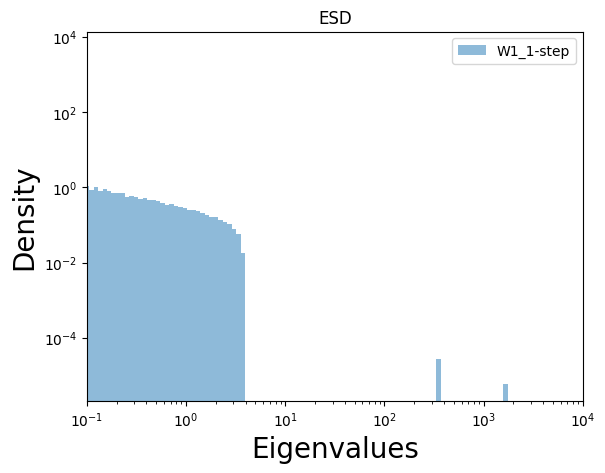

[2.04935318e+02 1.69597073e+01 3.89974499e+00 3.79799747e+00
 3.77229786e+00 3.74132729e+00 3.72508240e+00 3.72376800e+00
 3.70434260e+00 3.66544819e+00 3.64413095e+00 3.59490824e+00
 3.58970594e+00 3.57037902e+00 3.54224753e+00 3.52545571e+00
 3.51666880e+00 3.48717427e+00 3.46980548e+00 3.44505119e+00
 3.42179537e+00 3.40596771e+00 3.40001035e+00 3.39382172e+00
 3.37220788e+00 3.35573006e+00 3.34803796e+00 3.32820320e+00
 3.30578804e+00 3.29368711e+00 3.28532195e+00 3.27289486e+00
 3.24484181e+00 3.23950624e+00 3.22407079e+00 3.21512079e+00
 3.20094562e+00 3.19318390e+00 3.17424011e+00 3.16451979e+00
 3.15459728e+00 3.13801360e+00 3.13283467e+00 3.11881900e+00
 3.10813880e+00 3.08819962e+00 3.08293819e+00 3.06235528e+00
 3.05638003e+00 3.04786754e+00 3.04003024e+00 3.02710390e+00
 3.01727390e+00 2.99692035e+00 2.98836637e+00 2.97914290e+00
 2.96875620e+00 2.95911241e+00 2.95580435e+00 2.94524193e+00
 2.93311310e+00 2.92263818e+00 2.91038585e+00 2.89773107e+00
 2.88054943e+00 2.867724

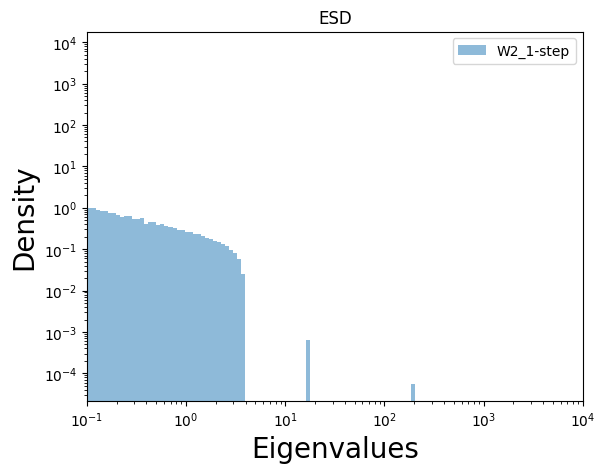

In [7]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v  
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)


A_1=(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)


X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
#beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v 
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 

y = X @ beta + xi

lr1=30
lr2=10

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')
#print_esd(W1_true, 'W1_1-initial')
#print_esd(W2_true,'W2_1-initial')


[6.73994812e+02 3.66219727e+02 3.83085752e+00 3.76289248e+00
 3.72465205e+00 3.70242596e+00 3.66578722e+00 3.65447664e+00
 3.62862706e+00 3.60544395e+00 3.59073567e+00 3.57773471e+00
 3.55958581e+00 3.54237986e+00 3.51851082e+00 3.49956512e+00
 3.46180964e+00 3.44958353e+00 3.43508434e+00 3.41076612e+00
 3.39888167e+00 3.37644625e+00 3.35364366e+00 3.33808231e+00
 3.33067775e+00 3.30557084e+00 3.29695034e+00 3.27407908e+00
 3.24615240e+00 3.23796725e+00 3.21929550e+00 3.21538997e+00
 3.20696187e+00 3.18922305e+00 3.17613435e+00 3.16992855e+00
 3.16388798e+00 3.15629435e+00 3.12789822e+00 3.12455606e+00
 3.11149311e+00 3.09619832e+00 3.08257937e+00 3.06904101e+00
 3.06670356e+00 3.04184079e+00 3.03664732e+00 3.03236032e+00
 3.01853943e+00 2.99316239e+00 2.98372006e+00 2.97194505e+00
 2.96128607e+00 2.95424724e+00 2.94565940e+00 2.93497014e+00
 2.91557980e+00 2.90457821e+00 2.89757919e+00 2.89409113e+00
 2.87962270e+00 2.86413717e+00 2.85853505e+00 2.84680510e+00
 2.83079100e+00 2.817957

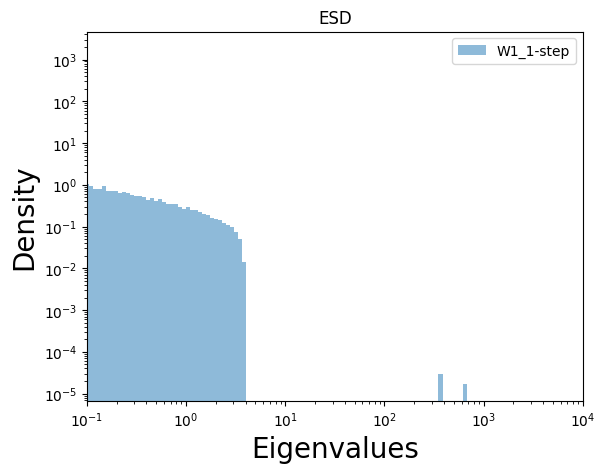

[7.45788208e+02 9.21326675e+01 3.86910534e+00 3.78935575e+00
 3.76389337e+00 3.71138382e+00 3.65216327e+00 3.63458705e+00
 3.61641717e+00 3.59564495e+00 3.58796930e+00 3.53293681e+00
 3.51718855e+00 3.51147795e+00 3.50541377e+00 3.47646332e+00
 3.45792317e+00 3.43844485e+00 3.42328429e+00 3.40337348e+00
 3.38766932e+00 3.38085318e+00 3.36372972e+00 3.34210324e+00
 3.33594561e+00 3.32255816e+00 3.31591868e+00 3.29039526e+00
 3.28244400e+00 3.26341796e+00 3.24963212e+00 3.23781157e+00
 3.21731687e+00 3.19211864e+00 3.18192053e+00 3.16939592e+00
 3.15584540e+00 3.14029360e+00 3.11971092e+00 3.10865307e+00
 3.09981441e+00 3.08885050e+00 3.07955313e+00 3.06388068e+00
 3.05318069e+00 3.04043365e+00 3.03110051e+00 3.02119589e+00
 3.00548673e+00 2.98751688e+00 2.97702217e+00 2.97156358e+00
 2.96229148e+00 2.95954394e+00 2.94599319e+00 2.92382240e+00
 2.91253543e+00 2.90068340e+00 2.89338374e+00 2.88735723e+00
 2.88354230e+00 2.86410737e+00 2.84881854e+00 2.84330440e+00
 2.84074116e+00 2.830523

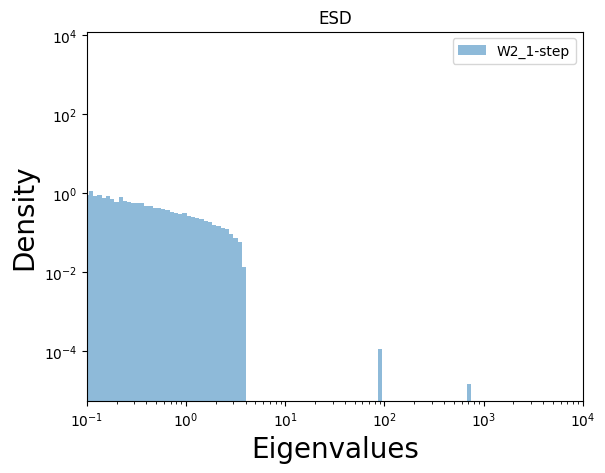

In [13]:
#2-layer
## visualize ESD

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --------------------------
# Configuration
# --------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def print_esd(W,label):
       
            
                ori_U, ori_S, ori_V = torch.svd(W.T@W)
            

                # plot ESD
                plt.figure()
                bins = 200
                sorted_original = np.sort(ori_S.cpu().numpy())[::-1]
                print(sorted_original)

                hist, bins = np.histogram(sorted_original, bins=bins)
                logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
                plt.hist(sorted_original, bins=logbins, density=True, rwidth=1, edgecolor='none', alpha=0.5, label=label)
    

                plt.yscale('log')
                plt.xscale('log')

                # control x axis scale
                plt.xlim(1e-1, 1e4)

                plt.xlabel("Eigenvalues", fontsize=20)
                plt.ylabel("Density", fontsize=20)
                plt.legend()
                plt.title(f"ESD")
                plt.show()
d, h, n = 1000, 1000, 1000
rho = 0
test_size = 500
x = torch.normal(mean=0, std=1, size=(test_size, d), device=device)

X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v  
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 
y = X @ beta + xi


W1_ = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
W2_ = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, h), device=device)


A_1=(1/ (n * np.sqrt(h))) * X.T @ y @ a.T @ W2_.T
A_2=(1 / (n * np.sqrt(h))) * W1_.T @ X.T @ y @ a.T


U1, S1, Vh1 = torch.linalg.svd(A_1)
u1 = U1[:, 0]  # shape: (d,)
u1 = u1.unsqueeze(1)  # shape: (d, 1)


v1=Vh1[0,:]
v1 = v1.unsqueeze(1)  # shape: (h, 1)

U2, S2, Vh2 = torch.linalg.svd(A_2)
u2 = U2[:, 0]  # shape: (h,)
u2 = u2.unsqueeze(1)  # shape: (h, 1)
v2=Vh2[0,:]
v2 = v2.unsqueeze(1)  # shape: (h, 1)
#u1 = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)
#u2 = torch.normal(mean=0, std=1/np.sqrt(h), size=(h, 1), device=device)
la1, la2 = 20,0
W1=  W1_ + la1 * (u1 @ v1.T)
W2=  W2_ + la2 * (u2 @ v2.T)


X = torch.normal(mean=0, std=1, size=(n, d), device=device)
xi = torch.normal(mean=0, std=np.sqrt(rho), size=(n, h), device=device)
a = torch.eye(h, device=device)
#beta = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, h), device=device)
u = torch.normal(mean=0, std=1/np.sqrt(d), size=(d, 1), device=device)  
v = torch.normal(mean=0, std=1.0, size=(1, h), device=device)           

beta = u @ v 
#beta = torch.zeros((d, h), device=device)        
#row_idx = torch.randint(0, d, (1,)).item()        
#beta[0] = torch.normal(mean=0, std=1/np.sqrt(d), size=(h,), device=device) 

y = X @ beta + xi

lr1=20
lr2=20

W1_true = W1 - lr1 / (n * h) * X.T @ X @ W1 @ W2 @ a @ a.T @ W2.T + (lr1 / (n * np.sqrt(h))) * X.T @ y @ a.T @ W2.T
W2_true = W2 - lr2 / (n * h) * W1.T @ X.T @ X @ W1 @ W2 @ a @ a.T + (lr2 / (n * np.sqrt(h))) * W1.T @ X.T @ y @ a.T

print_esd(W1_true, 'W1_1-step')
print_esd(W2_true,'W2_1-step')
#print_esd(W1_true, 'W1_1-initial')
#print_esd(W2_true,'W2_1-initial')
